# Group Members
Group name: **MyAiAcademia**

Members:
- Alessandro Assini

- Alberto Bertazza

- Riccardo Antonelli

- Angelo Baturi

Coding assistant used:

- ChatGPT (free trial)

- Claude (free trial)

# Assignement INTRO


```
gDrive_home/
├── Colab Notebooks/
│   └── NLP_assignment/
│       ├── PoliMillionaire.ipynb <-- Your notebook
│       └── millionaire_client/ <-- Directory provided
```


URL: configured via the `api-url` Colab Secret (HTTPS required)

### Game interaction

In [ ]:
from google.colab import drive
import os
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
import sys
# Define the path to the directory containing your package
package_parent_dir = '/content/gdrive/MyDrive/NLP/PoliMillionaire/NLP_assignment/'

# Append to sys.path if it is not already present
if package_parent_dir not in sys.path:
    sys.path.append(package_parent_dir)

# Verify the path was added
print(sys.path)

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/gdrive/MyDrive/NLP/PoliMillionaire/NLP_assignment/']


Let's import the client classes

In [ ]:
from millionaire_client import MillionaireClient, AuthenticationError

You can save your password in a Colab secret (the "key" icon on the tab on the left) and import it into your notebook.

In [ ]:
from google.colab import userdata
pwd = userdata.get('poli-millionaire')
usr = userdata.get('username')

Now keep the API_URL as stated, but please change the username and password to be the ones you used during sign up session.

In [ ]:
API_URL = userdata.get('api-url')
if not API_URL or not API_URL.startswith("https://"):
    raise ValueError("The quiz API URL must use HTTPS.")
username = usr
password = pwd

Now we can instantiate a MillionaireClient object and call the login method, which takes as parameters username and password.

In [ ]:
client = MillionaireClient(API_URL)
try:
    user = client.login(username, password)
    print(f"\nWelcome, {user.username}! (Role: {user.role})")
except AuthenticationError as e:
    print(f"Login failed: {e}")


Welcome, AleAssini! (Role: student)


Types of competition


In [ ]:
# List available competitions
print("\n=== Available Competitions ===")
competitions = client.competitions.list_all()
for comp in competitions:
    print(f"  {comp.id}: {comp.name} ({comp.max_levels} questions)")


=== Available Competitions ===
  0: Entertainment (15 questions)
  1: Ancient History and Politics (15 questions)
  2: Science and Nature (15 questions)
  3: Maths (15 questions)
  4: Philosophy and Psychology (15 questions)
  5: News (15 questions)


##Competition

In [ ]:
# Choose a competition ID
comp_id = 1
chosen_comp = competitions[comp_id].name
print(f"Chosen competition: {chosen_comp}")

Chosen competition: Ancient History and Politics


## Show Leaderboard


In [ ]:
# Show leaderboard position
lb = client.leaderboard.get(competition_id=comp_id, limit=10)
print(f"\n=== Leaderboard for {lb.competition.name} ===")
for i, entry in enumerate(lb.entries[:10], 1):
    marker = " <-- YOU" if entry.username == username else ""
    print(f"  {i}. {entry.username}: ${entry.score:,.2f} (Level {entry.reached_level}){marker}")


=== Leaderboard for Ancient History and Politics ===
  1. luca_bordin: $1,024,000.00 (Level 15)
  2. zahra: $1,024,000.00 (Level 15)
  3. El_Marzel: $1,024,000.00 (Level 15)
  4. gvin: $1,024,000.00 (Level 15)
  5. Bilal_jaiel: $1,024,000.00 (Level 15)
  6. Zero37: $1,024,000.00 (Level 15)
  7. gabrielep: $1,024,000.00 (Level 15)
  8. dany: $1,024,000.00 (Level 15)
  9. MatteoVitali: $1,024,000.00 (Level 15)
  10. Mario: $1,024,000.00 (Level 15)


# LLMs

## General settings

Models we want to try by category:

Small (< 5B parameters):

*   microsoft/Phi-3.5-mini-instruct (thinking)
*   google/gemma-3-4b-it
*   Qwen/Qwen2.5-3B-Instruct
*   meta-llama/Llama-3.2-3B-Instruct


Medium (5B - 10B parameters):

*   meta-llama/Meta-Llama-3-8B-Instruct (thinking)
*   mistralai/Mistral-7B-v0.3 (non istruct)
*   mistralai/Mistral-7B-Instruct-v0.3
*   google/gemma-2-9b
*   google/gemma-7b-it
*   Qwen/Qwen3.5-9B
*   Qwen/Qwen2.5-7B-Instruct

Large (10B+ parameters):

*   Qwen/Qwen-2.5-14B (non instr)
*   Qwen/Qwen2.5-14B-Instruct
*   google/gemma-2-27b-it

Thinking/Reasoning Models:
* deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B
* deepseek-ai/DeepSeek-R1-Distill-Qwen-7B
* microsoft/Phi-3.5-mini-instruct  (GIA PROVATO )
* Qwen/Qwen2.5-7B-Instruct (GIA PROVATO )

Mixture of Experts / Dense

* mistralai/Mixtral-8x7B-Instruct-v0.1 (pesante 47B)
* Qwen/Qwen1.5-MoE-A2.7B (A-> Active params)
* google/gemma-4-E4B-it (E-> Effective Params)


In [ ]:
MODELS_LIST = [
    "microsoft/Phi-3.5-mini-instruct",
    "google/gemma-3-4b-it",
    "Qwen/Qwen2.5-3B-Instruct",
    "meta-llama/Llama-3.2-3B-Instruct",
    "meta-llama/Meta-Llama-3-8B-Instruct",
    "Qwen/Qwen2.5-7B-Instruct",
    "Qwen/Qwen2.5-14B-Instruct",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
]

STRATEGIES_LIST = [
    "zero_shot",
    "few_shot",
    "cot",
]

##CONFIG

In [ ]:
import torch

CONFIG = {
    # SELECT HERE THE MODEL TO RUN
    "model_id": "Qwen/Qwen2.5-3B-Instruct",

    #quantization
    "quantization_bits": None, # 4, 8 or None to default 16

    # Select here the strategy to apply
    "prompt_strategy": "zero_shot",
    "n-shots": 1, # set number of examples to give in the prompt
    "temperature": 1.0,  # sampling temperature (1.0 = default)
    "do_sample": False,

    # generation
    "max_new_tokens": 512,
    "reasoning_max_new_tokens": 512,

    "model_kwargs": {
        "device_map": "auto", # "auto" , "cuda"
        "torch_dtype": "auto",  # "auto", torch.float16, torch.bfloat16, or torch.float32
        "trust_remote_code": True, # Autorizzo Hugging Face
        "attn_implementation": "eager",
    }
}

#LLM loader

##Helper commands


###Phi helpers

In [ ]:
model_id_lower = CONFIG["model_id"].lower()

if model_id_lower.startswith("microsoft/phi-3.5"):
    !pip uninstall -y transformers accelerate
    !pip install transformers==4.43.3 accelerate==0.33.0
    !rm -rf ~/.cache/huggingface/modules

###Llama helper

In [ ]:
model_id_lower = CONFIG["model_id"].lower()

if (model_id_lower.startswith("meta-llama/llama-3.2") or model_id_lower.startswith("meta-llama/meta-llama-3")):
    CONFIG["model_kwargs"]["attn_implementation"] = "sdpa"

###Quantization helper

In [ ]:
import torch
import subprocess
import sys

bits = CONFIG.get("quantization_bits")

if bits in {4, 8}:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-U", "transformers", "accelerate", "bitsandbytes"],
        check=True
    )

## Model Loader

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

def load_model(config):
    model_id = config["model_id"]
    kwargs = config["model_kwargs"].copy()

    # attn_implementation controlla come viene calcolata l’attenzione dentro il Transformer.
    if model_id.lower().startswith("microsoft/phi"):
        kwargs["attn_implementation"] = "eager"


    # quantization
    bits = config.get("quantization_bits")

    if bits == 4:
        kwargs["quantization_config"] = BitsAndBytesConfig(load_in_4bit=True)
    elif bits == 8:
        kwargs["quantization_config"] = BitsAndBytesConfig(load_in_8bit=True)


    display_bits = f"{bits}-bit" if bits else "None (Native/16-bit)"
    print(f"Loading model: {model_id} | Quantization: {display_bits}")

    # 3. Load Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        trust_remote_code=kwargs.get("trust_remote_code", False)
    )

    # 4. Load Model
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        **kwargs
    )

    return tokenizer, model

In [ ]:
# ============================================================
# LOAD MODEL (USING CONFIG)
# ============================================================

llm_tokenizer, llm_model = load_model(CONFIG)

print("Model loaded successfully.")
print("Model name:", CONFIG["model_id"])
print("CUDA available:", torch.cuda.is_available())

try:
    print("Model device:", llm_model.device)
except:
    print("Model device: device_map='auto'")

Loading model: Qwen/Qwen2.5-3B-Instruct | Quantization: None (Native/16-bit)


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully.
Model name: Qwen/Qwen2.5-3B-Instruct
CUDA available: True
Model device: cuda:0


# CHATBOT 🤖

## Prompting

In [ ]:
# Small DB where examples can be added and then provided for n-shots prompting strategies.

EXAMPLES_DB = {
    "Entertainment": [
        {"q": "Who directed the movie 'Inception'?", "o": "[0] Steven Spielberg\n[1] Christopher Nolan\n[2] Quentin Tarantino\n[3] James Cameron", "a": "1", "r": "'Inception' is a 2010 sci-fi film directed by Christopher Nolan. It is option 1."},
        {"q": "Which band released the album 'Abbey Road'?", "o": "[0] The Rolling Stones\n[1] Led Zeppelin\n[2] The Beatles\n[3] Pink Floyd", "a": "2", "r": "'Abbey Road' is the eleventh studio album by the English rock band The Beatles. It is option 2."},
        {"q": "Which actor played the character of Iron Man in the Marvel Cinematic Universe?", "o": "[0] Chris Evans\n[1] Robert Downey Jr.\n[2] Chris Hemsworth\n[3] Mark Ruffalo", "a": "1", "r": "Robert Downey Jr. portrayed Tony Stark, also known as Iron Man, starting in 2008. It is option 1."}
    ],
    "Ancient History and Politics": [
        {"q": "In which year did the French Revolution begin?", "o": "[0] 1776\n[1] 1789\n[2] 1812\n[3] 1492", "a": "1", "r": "The French Revolution began in 1789 with the Storming of the Bastille. It is option 1."},
        {"q": "Who was the first President of the United States?", "o": "[0] Thomas Jefferson\n[1] Abraham Lincoln\n[2] George Washington\n[3] John Adams", "a": "2", "r": "George Washington served as the first president from 1789 to 1797. It is option 2."},
        {"q": "Which ancient civilization is famous for building the Great Pyramid of Giza?", "o": "[0] The Romans\n[1] The Greeks\n[2] The Egyptians\n[3] The Sumerians", "a": "2", "r": "The Great Pyramid was built as a tomb for the Pharaoh Khufu by the Ancient Egyptians. It is option 2."}
    ],
    "Science and Nature": [
        {"q": "What is the chemical symbol for Gold?", "o": "[0] Gd\n[1] Ag\n[2] Au\n[3] Fe", "a": "2", "r": "The symbol Au comes from the Latin word for gold, 'aurum'. It is option 2."},
        {"q": "Which part of the cell is known as the powerhouse?", "o": "[0] Nucleus\n[1] Ribosome\n[2] Mitochondria\n[3] Golgi apparatus", "a": "2", "r": "Mitochondria generate most of the cell's supply of adenosine triphosphate (ATP). It is option 2."},
        {"q": "What is the closest planet to the Sun?", "o": "[0] Venus\n[1] Mars\n[2] Mercury\n[3] Earth", "a": "2", "r": "Mercury is the smallest and innermost planet in the Solar System. It is option 2."}
    ],
    "Maths": [
        {"q": "What is the square root of 144?", "o": "[0] 10\n[1] 11\n[2] 12\n[3] 14", "a": "2", "r": "12 multiplied by 12 equals 144. It is option 2."},
        {"q": "Solve for x: 2x + 5 = 15", "o": "[0] 5\n[1] 10\n[2] 15\n[3] 20", "a": "0", "r": "Subtract 5 from 15 to get 10, then divide by 2. x = 5. It is option 0."},
        {"q": "What is the value of 5 factorial (5!)?", "o": "[0] 60\n[1] 100\n[2] 120\n[3] 150", "a": "2", "r": "The factorial of 5 is 5 * 4 * 3 * 2 * 1, which equals 120. It is option 2."}
    ],
    "Philosophy and Psychology": [
        {"q": "Who is considered the founder of psychoanalysis?", "o": "[0] Carl Rogers\n[1] Sigmund Freud\n[2] B. F. Skinner\n[3] Jean Piaget", "a": "1", "r": "Sigmund Freud developed psychoanalysis as a theory and therapeutic method. It is option 1."},
        {"q": "What term describes learning through rewards and punishments?", "o": "[0] Classical conditioning\n[1] Operant conditioning\n[2] Free association\n[3] Introspection", "a": "1", "r": "Operant conditioning is learning shaped by reinforcement and punishment. It is option 1."},
        {"q": "Which philosopher wrote 'The Republic'?", "o": "[0] Aristotle\n[1] Plato\n[2] Socrates\n[3] Descartes", "a": "1", "r": "'The Republic' is a philosophical work by Plato. It is option 1."}
    ],
    "News": [
        {"q": "What organization is responsible for international public health coordination?", "o": "[0] NATO\n[1] WHO\n[2] IMF\n[3] WTO", "a": "1", "r": "The World Health Organization coordinates international public health. It is option 1."},
        {"q": "Which institution is the central bank of the United States?", "o": "[0] World Bank\n[1] Federal Reserve\n[2] European Central Bank\n[3] International Monetary Fund", "a": "1", "r": "The Federal Reserve is the central banking system of the United States. It is option 1."},
        {"q": "What does UN stand for?", "o": "[0] United Nations\n[1] Union Network\n[2] Universal Nation\n[3] United Neutrality", "a": "0", "r": "UN stands for United Nations, an international organization founded in 1945. It is option 0."}
    ]
}

In [ ]:
import random
def get_examples(n=1):
    category_list = EXAMPLES_DB.get(chosen_comp)
    # Return n samples, or the whole list if n is larger than available questions
    return random.sample(category_list, min(n, len(category_list)))

In [ ]:
def format_options(options):
    return "\n".join([f"[{opt.id}] {opt.text}" for opt in options])

In [ ]:
# Prompt builders

def build_zero_shot_prompt(question_text, options):
    options_text = format_options(options)

    system_message = (
        "You are playing a multiple-choice quiz game.\n"
        f"You are an expert of {chosen_comp}.\n"
        "Choose the correct answer for the question delimited by triple backticks.\n\n"
        "Rules:\n"
        "- Return only the option ID.\n"
        "- Do not explain.\n"
        "- Do not write anything except one number."
    )

    user_message = (
        f"```{question_text}```\n\n"
        f"Options:\n{options_text}\n\n"
        "Answer:"
    )
    return system_message, user_message

def build_few_shot_prompt(question_text, options):
    options_text = format_options(options)
    n_shots = CONFIG["n-shots"]
    examples = get_examples(n_shots)

    example_blocks = []
    for ex in examples:
        block = f"```{ex['q']}```\nOptions:\n{ex['o']}\nAnswer: {ex['a']}"
        example_blocks.append(block)

    system_message = (
        "You are playing a multiple-choice quiz game.\n"
        f"You are an expert of {chosen_comp}.\n"
        "Choose the correct answer for the question delimited by triple backticks.\n\n"
        "Rules:\n"
        "- Return only the option ID.\n"
        "- Do not explain.\n"
        "- Do not write anything except one number.\n\n"
        "Examples:\n\n" + "\n\n".join(example_blocks)
    )

    user_message = (
        f"```{question_text}```\n\n"
        f"Options:\n{options_text}\n\n"
        "Answer:"
    )

    return system_message, user_message


def build_cot_prompt(question_text, options):
    options_text = format_options(options)
    n_shots = CONFIG["n-shots"]
    examples = get_examples(n_shots)

    example_blocks = []
    for ex in examples:
        block = (
            f"```{ex['q']}```\n"
            f"Options:\n{ex['o']}\n"
            f"Reasoning: {ex['r']}\n"
            f"Answer: {ex['a']}"
        )
        example_blocks.append(block)

    system_message = (
        "You are playing a multiple-choice quiz game.\n"
        f"You are an expert of {chosen_comp}.\n"
        "To answer the question delimited by triple backticks, follow these steps:\n"
        "Step 1 - Read the question carefully.\n"
        "Step 2 - Consider each option and reason about it.\n"
        "Step 3 - Select the most plausible answer.\n"
        "Step 4 - Output your answer using this format:\n"
        "Reasoning: <your reasoning>\n"
        "Answer: <option ID>\n\n"
        "Examples:\n\n" + "\n\n".join(example_blocks)
    )

    user_message = (
        f"```{question_text}```\n\n"
        f"Options:\n{options_text}\n\n"
        "Reasoning:"
    )

    return system_message, user_message


In [ ]:
PROMPT_BUILDERS = {
    "zero_shot": build_zero_shot_prompt,
    "few_shot": build_few_shot_prompt,
    "cot": build_cot_prompt,
}

def build_prompt(question_text, options):
    prompt_strategy = CONFIG["prompt_strategy"]

    if prompt_strategy not in PROMPT_BUILDERS:
        #Default to zero-shot prompt strategy
        prompt_strategy = "zero_shot"

    if prompt_strategy in {"few_shot", "cot"}:
        print(f"Using {prompt_strategy} prompting strategy with {CONFIG["n-shots"]} examples")
        return PROMPT_BUILDERS[prompt_strategy](question_text, options)

    print(f"Using {prompt_strategy} prompting strategy")
    return PROMPT_BUILDERS[prompt_strategy](question_text, options)


###Dynamic prompting

In [ ]:
# Dynamic prompting configuration

DYNAMIC_PROMPTING = {
    "enabled": False,

    # Prompt used from level 1 up to "switch_after_level"
    "first_prompt_strategy": "zero_shot",

    # Last level in which the first prompt is used
    "switch_after_level": 7,

    # Prompt used from the next level onward
    "second_prompt_strategy": "cot",
}


def get_prompt_strategy_for_level(current_level):
    if not DYNAMIC_PROMPTING["enabled"]:
        return CONFIG["prompt_strategy"]

    if current_level <= DYNAMIC_PROMPTING["switch_after_level"]:
        return DYNAMIC_PROMPTING["first_prompt_strategy"]

    return DYNAMIC_PROMPTING["second_prompt_strategy"]

## Extraction options

For different Prompting Strategies


In [ ]:
import json

def extract_option_id_json(output, valid_ids):
    try:
        match = re.search(r'\{.*\}', output, re.DOTALL)
        if match:
            data = json.loads(match.group())
            ans = int(data.get("answer"))
            if ans in valid_ids:
                return ans
    except:
        pass
    return None

def extract_option_id_cot(output, valid_ids):
    match = re.search(r'(?:Answer|Answer is)[\s:]*([0-9]+)', output, re.IGNORECASE)
    if match:
        ans = int(match.group(1))
        if ans in valid_ids:
            return ans
    numbers = re.findall(r'\b\d+\b', output)
    if numbers:
        ans = int(numbers[-1])
        if ans in valid_ids:
            return ans
    return None

def extract_option_id(output, valid_ids):
    match = re.search(r'(?:Answer|Answer is)[\s:]*([0-9]+)', output, re.IGNORECASE)
    if match:
        ans = int(match.group(1))
        if ans in valid_ids:
            return ans
    numbers = re.findall(r'\b\d+\b', output)
    if numbers:
        ans = int(numbers[0])
        if ans in valid_ids:
            return ans
    return None

## Answer preparation

In [ ]:
import re
def generate_answer(prompt, tokenizer, model, do_sample=True, max_new_tokens=15, temperature=1.0):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_len = inputs["input_ids"].shape[-1]
    #prompt_len = len(prompt)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature,
            #use_cache=False
        )

    # We cut-off the "raw part" and return only the reasoning +
    # Answer: []

    pruned_output = tokenizer.decode(
        outputs[0][prompt_len:],
        skip_special_tokens=True
    ).strip()

    return pruned_output


def parse_answer(output, valid_ids):

    prompt_strategy = CONFIG["prompt_strategy"]

    if prompt_strategy == "zero_shot_cot":
        return extract_option_id_json(output, valid_ids)

    if prompt_strategy == "cot":
        return extract_option_id_cot(output, valid_ids)

    return extract_option_id(output, valid_ids)

def get_llm_answer(question, tokenizer, model, max_retries=3):

    valid_ids = [opt.id for opt in question.options]
    system_msg, user_msg = build_prompt(question.text , question.options)

    #For Debug
    #print(f"System message:\n {system_msg}")

    # Applica il Chat Template
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg}
    ]

    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    max_new_tokens = CONFIG.get("max_new_tokens", 15)

    # Assign higher number of tokens if reasoning is required
    if CONFIG["prompt_strategy"] in {"zero_shot_cot", "cot"}:
        max_new_tokens = CONFIG.get("reasoning_max_new_tokens", 256)


    # retry if the llm fails 3 times
    for _ in range(max_retries):

        output = generate_answer(prompt, tokenizer, model, do_sample=CONFIG.get("do_sample",True), max_new_tokens=max_new_tokens, temperature=CONFIG.get("temperature", 1.0))

        print(f"Output: (Reasoning, if selected, + Answer):\n {output}")
        answer = parse_answer(output, valid_ids)

        #print(f"\nLA RISPOSTA QUA è: {answer}")
        if answer is not None:
            return answer

    # fallback to
    print("\nFallback...")
    return valid_ids[0]

In [ ]:
def play_game_llm(game, tokenizer, model):
    while game.in_progress:
        question = game.current_question
        if not question:
            print("No question available.")
            break

        print(f"\n--- Level {game.current_level} ---")
        print(f"Q: {question.text}\n")

        for opt in question.options:
            print(f"  [{opt.id}] {opt.text}")

        time_left = game.time_remaining
        if time_left:
            print(f"\nTime remaining: {time_left:.1f}s")

        # Select prompt strategy dynamically according to the current level
        CONFIG["prompt_strategy"] = get_prompt_strategy_for_level(game.current_level)
        print(f"Active prompt strategy: {CONFIG['prompt_strategy']}")

        # LLM answering
        answer_id = get_llm_answer(question, tokenizer, model)

        result = game.answer(answer_id)

        if result.correct:
            print("CORRECT!")
            if result.game_over:
                print("\nCONGRATULATIONS!")
                print(f"Final earnings: ${result.earned_amount:,.2f}")
            else:
                print(f"Earned so far: ${result.earned_amount:,.2f}")

        elif result.timed_out:
            print("TIMED OUT!")
            print(f"\nGame Over!")
            print(f"Final earnings: ${result.earned_amount:,.2f}")

        else:
            print("WRONG ANSWER!")
            print(f"\nGame Over!")
            print(f"Final earnings: ${result.earned_amount:,.2f}")

    print("\n=== Game Summary ===")
    print(f"Reached Level: {game.current_level}")
    print(f"Total Earnings: ${game.earned_amount:,.2f}")

## 🔎 CHATBOT Analysis

### Are certain models better at certain topics than others?

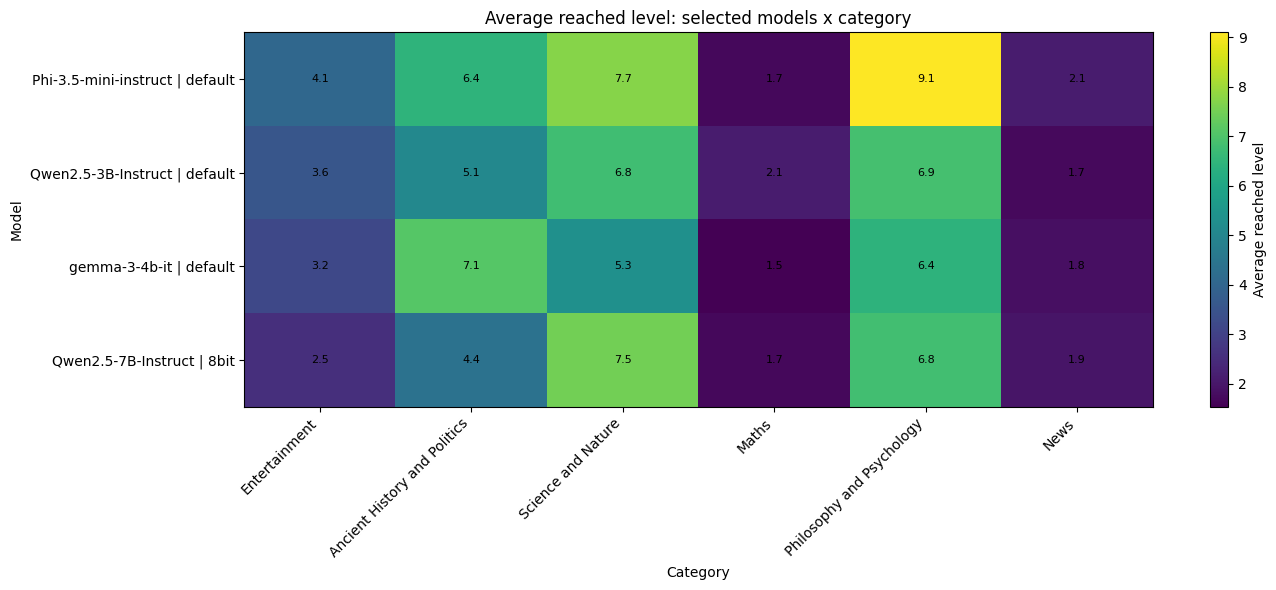

In [ ]:
display(chatbot_figures["model_topic_heatmap"])

As shown in the figure, all models achieve relatively low performance in the Math and News categories. In fact, none of them reaches an average score of 4.

The Entertainment category shows slightly better results, although performance remains moderate overall.

The best performances are observed in Ancient History and Politics, Science and Nature, and Philosophy and Psychology.

In particular, Phi-3.5-Mini-Instruct achieves the highest average score across these categories, followed by Qwen2.5-3B-Instruct.

### Are bigger models better than smaller models?

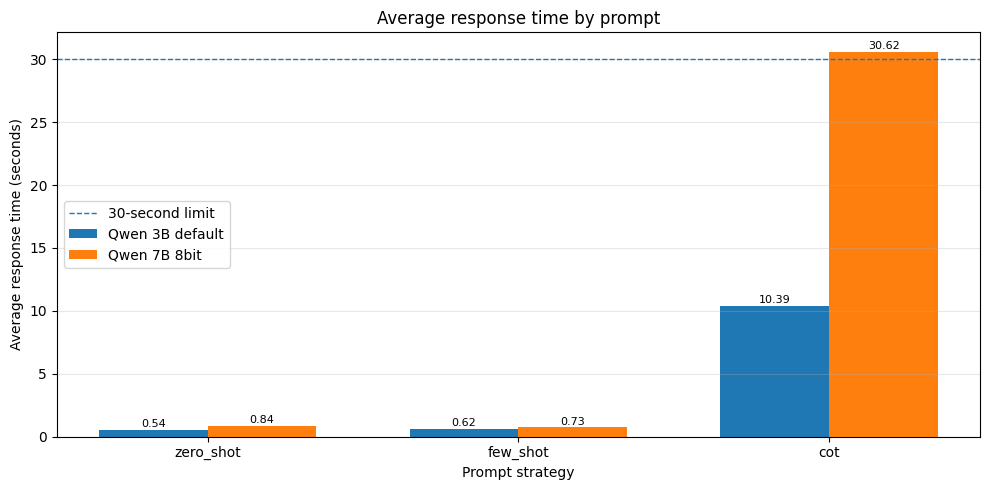

In [ ]:
display(qwen_final_figures["average_response_time_by_prompt"])

Considering two models, Qwen 3B and Qwen 7B quantized to 8-bit, the choice of prompting strategy significantly affects the average response time.

Indeed, Zero-Shot and Few-Shot prompting produce responses within a few seconds, whereas Chain-of-Thought (CoT) prompting substantially increases the inference time. In particular, with the larger Qwen 7B model, the response generation time often approaches or exceeds 30 seconds.

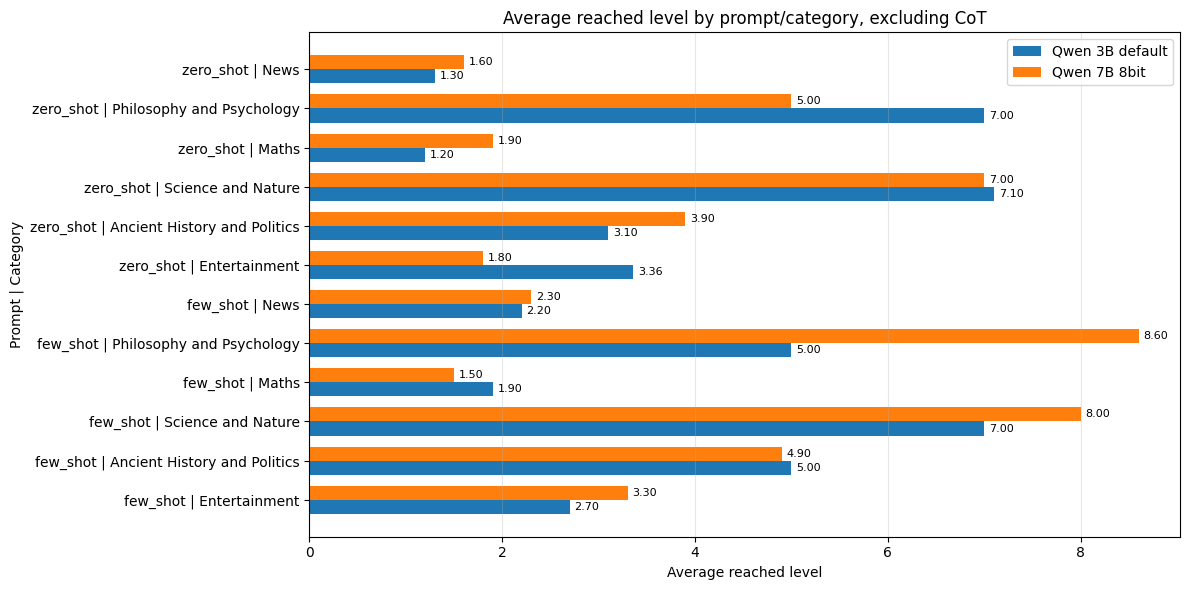

In [ ]:
display(qwen_final_figures["average_reached_level_by_prompt_category"])

Qwen 7B, quantized to 8-bit precision, shows a noticeable improvement in the average score achieved across the different categories when moving from Zero-Shot to Few-Shot prompting. In contrast, for Qwen 3B, the improvement is not evident, as its average performance remains largely unchanged across the two prompting strategies or sometimes we get worst performance.

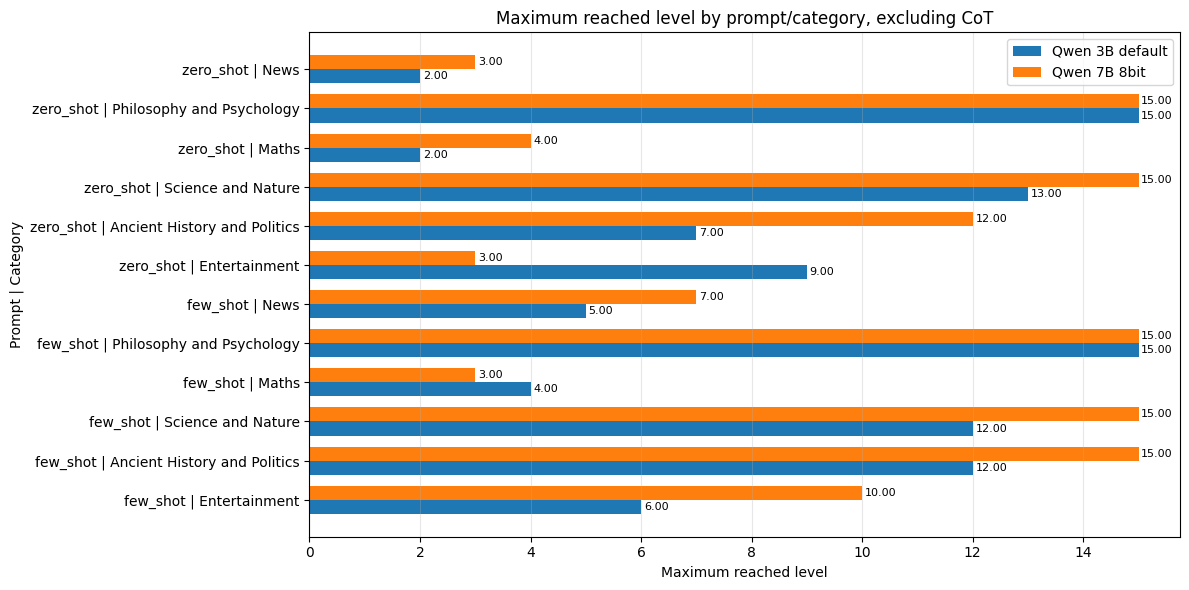

In [ ]:
display(qwen_final_figures["max_reached_level_by_prompt_category"])

Considering the best score for both models in the different category with different type of prompt, Qwen 7B is able to reach the highest level. Except for few cases.

### Which prompt type works best?

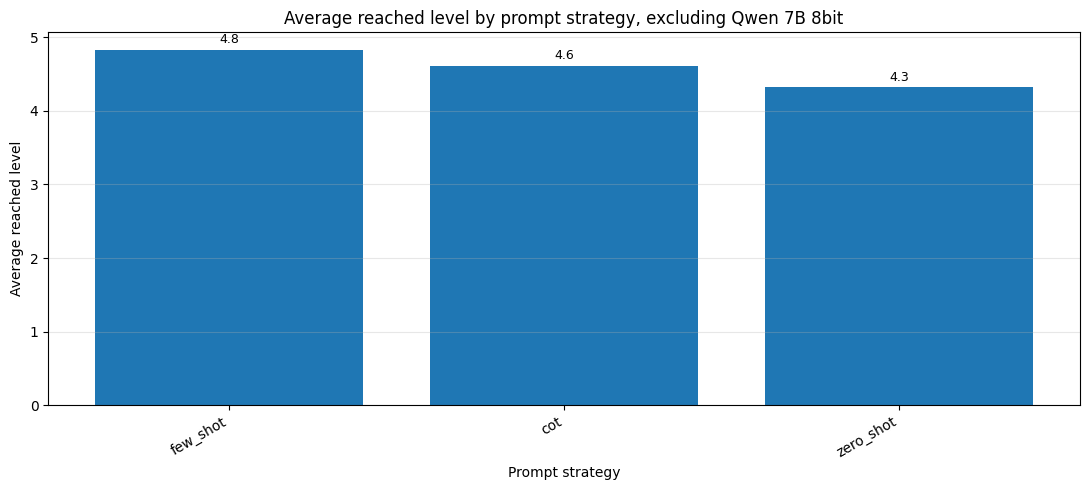

In [ ]:
display(chatbot_figures["prompt_type_comparison"])

According to the previous analysis, Few-Shot prompting consistently outperforms Zero-Shot prompting. However, the effectiveness of Chain-of-Thought (CoT) prompting is less straightforward.

In theory, CoT should provide the best performance by encouraging the model to reason through the problem step by step. However, our results show that CoT significantly increases inference time. As observed in the latency analysis, the model sometimes struggles to generate a response within the allotted time limit, leading to timeouts.

Consequently, although CoT has the potential to achieve higher accuracy, its practical effectiveness is reduced by its computational cost and longer response times. Therefore, when both performance and latency are considered, Few-Shot prompting appears to offer the best trade-off between accuracy and efficiency.

### How sensitive are different LLMs to prompt types?

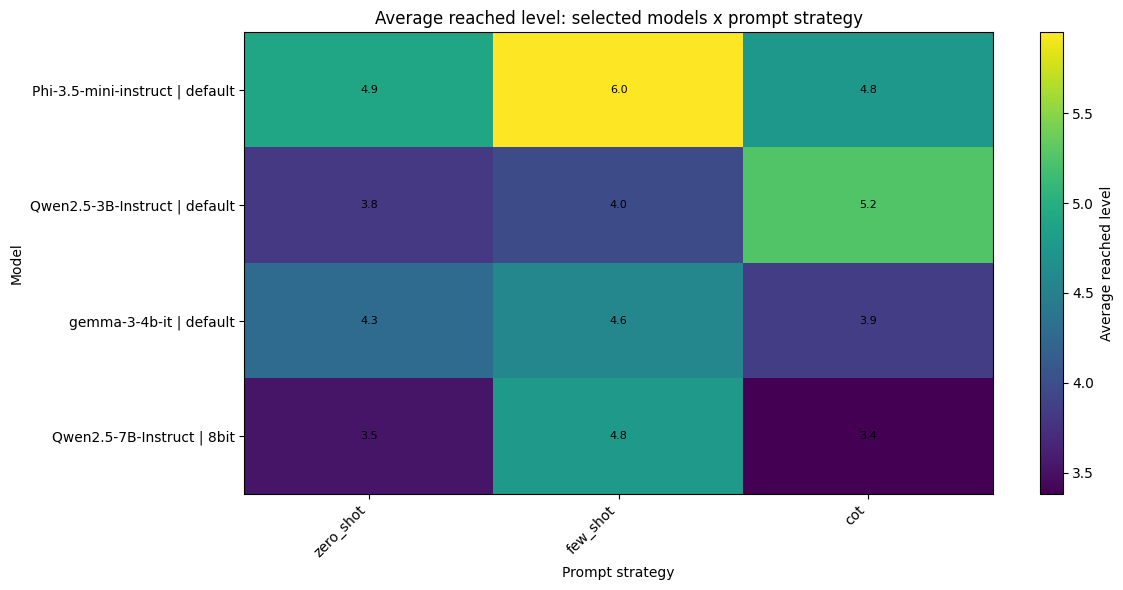

In [ ]:
display(chatbot_figures["model_prompt_sensitivity"])

In the majority of cases, Few-Shot prompting is the most effective strategy, achieving the highest average score across the evaluated categories. In contrast, Zero-Shot and Chain-of-Thought (CoT) prompting generally exhibit similar performance levels.

The only exception is Qwen 2.5 3B, for which CoT prompting achieves the highest average score, followed by Few-Shot prompting. This suggests that the additional reasoning encouraged by CoT can be beneficial for smaller models in certain scenarios, although this advantage is not consistently observed across all models.

### Which topics/categories are harder?

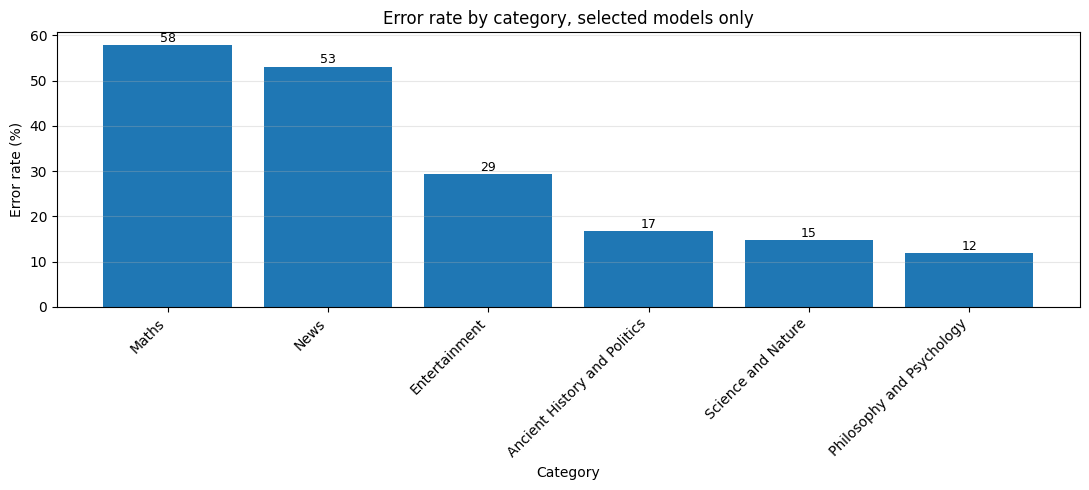

In [ ]:
display(chatbot_figures["category_difficulty"])

According to our evaluation, Math is the most challenging category, followed by News and Entertainment.

Mathematics yields the lowest performance because, although LLMs are capable of reasoning, they are not specifically designed for precise numerical calculations and may therefore make computational errors. In contrast, the poor performance in the News category can largely be attributed to the lack of access to up-to-date contextual information. Since the evaluated models rely only on the knowledge available during training, they often struggle to answer questions about recent events or developments that occurred after their training cutoff date.

### What types of questions do the models tend to struggle on?

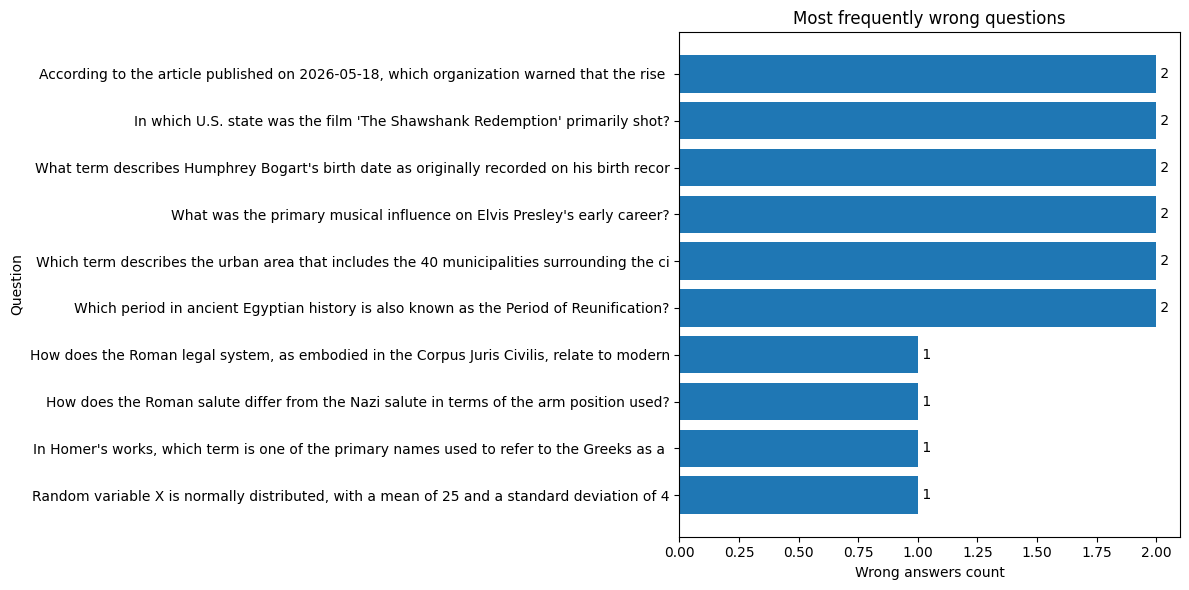

In [ ]:
display(wrong_questions)

The chart shows the questions that were answered incorrectly most often by the models.  
The examples suggest that the models do not fail randomly: they tend to struggle with specific types of questions.

**News**  
Example: “According to the article published on 2026-05-18...”  
This is difficult because it requires very recent and article-specific information. A base LLM usually cannot know the content of a specific 2026 news article without retrieval.

**Entertainment**  
Example: “In which U.S. state was the film *The Shawshank Redemption* primarily shot?”  
This is a very specific factual detail. The model may know the movie, but it can still confuse filming location, story setting, or production details.

**Entertainment**  
Example: “What term describes Humphrey Bogart’s birth date as originally recorded...”  
This is a niche biographical detail. These questions are hard because they require exact knowledge, not general understanding of the person.

**Ancient History and Politics**  
Example: “Which term describes the urban area that includes the 40 municipalities...”  
This is a terminology question. The model struggles when it has to select the exact technical term for a political or administrative concept.

**Ancient History and Politics**  
Example: “Which period in ancient Egyptian history is also known as the Period of Reunification?”  
This requires precise historical period classification. The model may know Egyptian history generally, but confuse similar periods or dynasties.

### Are models able to answer within 30 seconds?

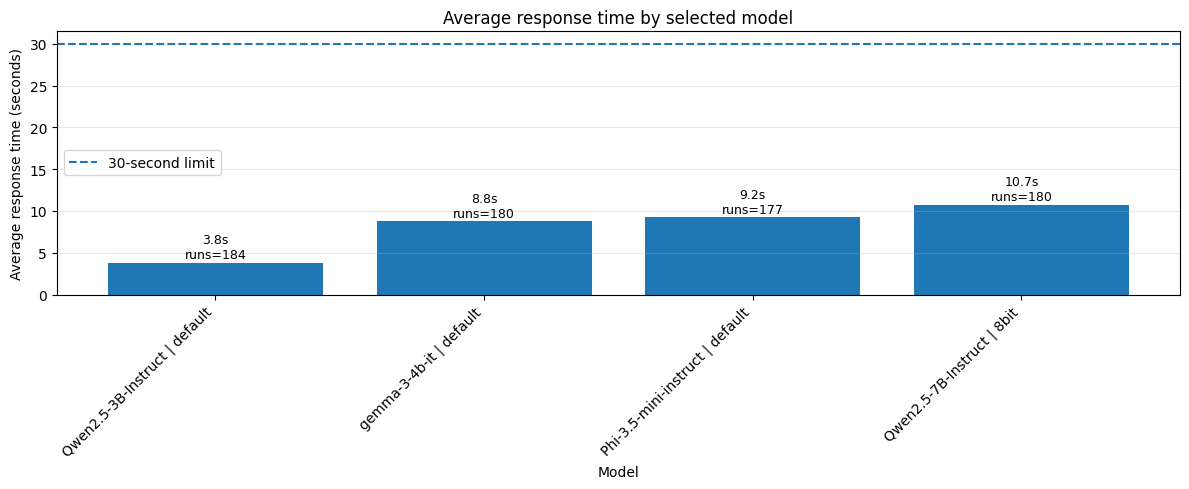

In [ ]:
display(chatbot_figures["latency_30_seconds"])

All the models are able to answer within 30 second, usually using only the 25 % of the available time. The only exception is Qwen 7B with Cot, which struggle to get an answer in 30 second.

# Play game with LLM

In [ ]:
game = client.game.start(competition_id=comp_id)
play_game_llm(game,llm_tokenizer, llm_model)


--- Level 1 ---
Q: How did the legal status of a freed slave (libertus) differ from that of a freeborn Roman citizen?

  [0] A freed slave retained their former master's power over them (potestas).
  [1] A freed slave could not vote but could hold public office, unlike a freeborn citizen.
  [2] A freed slave could vote and hold public office, just like a freeborn citizen.
  [3] A freed slave could vote but could not hold public office, unlike a freeborn citizen.

Time remaining: 29.9s
Active prompt strategy: few_shot
Using few_shot prompting strategy with 1 examples
Output: (Reasoning, if selected, + Answer):
 3
CORRECT!
Earned so far: $100.00

--- Level 2 ---
Q: What is the primary basis for moral and social obligation in Plato's Republic?

  [0] The pursuit of pleasure and happiness.
  [1] Following the laws and customs of society.
  [2] Power and control over others.
  [3] The knowledge of the Form of the Good.

Time remaining: 29.9s
Active prompt strategy: few_shot
Using few_shot 

#RAG 📚

## Setup

In [ ]:
BASE_RAG_CONFIG = {
    "retrieval_method": "wikipedia_local",

    # retrieval
    "top_k_context": 3,

    # generation
    "rag_max_new_tokens": 64,

    # debug
    "debug": True,
}

In [ ]:
import os
import json
import gzip
import pickle
import torch

In [ ]:
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 37.4 MB/s eta 0:00:00


In [ ]:
import faiss
import numpy as np
import os

In [ ]:
SEMANTIC_SEARCH_DIR = "/content/gdrive/MyDrive/NLP/PoliMillionaire/SemanticSearch"

os.makedirs(SEMANTIC_SEARCH_DIR, exist_ok=True)

print("Semantic Search cache folder:")
print(SEMANTIC_SEARCH_DIR)

Semantic Search cache folder:
/content/gdrive/MyDrive/NLP/PoliMillionaire/SemanticSearch


**Embedding model**

Each Wikipedia passage is encoded using:

```text
multi-qa-MiniLM-L6-cos-v1
```

Because it is designed for semantic question-answer retrieval: given a quiz question, it can retrieve passages that are semantically related even when they do not contain exactly the same words.

In [ ]:
from sentence_transformers import SentenceTransformer, util

SEMB_MODEL_NAME = 'multi-qa-MiniLM-L6-cos-v1'
semb_model = SentenceTransformer(SEMB_MODEL_NAME)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/383 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**Knowledge base**

We used **SimpleWiki** as our local knowledge source.

* It provides general encyclopedic knowledge.
* It is lightweight enough to be indexed and queried efficiently.

In [ ]:
WIKIPEDIA_FILENAME = "simplewiki-2020-11-01.jsonl.gz"
wikipedia_filepath = os.path.join(SEMANTIC_SEARCH_DIR, WIKIPEDIA_FILENAME)

if not os.path.exists(wikipedia_filepath):
    print("Wikipedia dump not found on Drive. Downloading...")
    util.http_get(
        "http://sbert.net/datasets/simplewiki-2020-11-01.jsonl.gz",
        wikipedia_filepath
    )
else:
    print("Wikipedia dump already found on Drive. Skipping download.")

print("Wikipedia file path:")
print(wikipedia_filepath)

Wikipedia dump already found on Drive. Skipping download.
Wikipedia file path:
/content/gdrive/MyDrive/NLP/PoliMillionaire/SemanticSearch/simplewiki-2020-11-01.jsonl.gz


In [ ]:
MAX_PARAGRAPHS_PER_ARTICLE = 10

In [ ]:
import json
import gzip

passages = []
passage_metadata = []

with gzip.open(wikipedia_filepath, 'rt', encoding='utf8') as f:
    for line in f:
        data = json.loads(line.strip())

        title = data.get("title", "").strip()
        paragraphs = data.get("paragraphs", [])

        for paragraph_id, paragraph in enumerate(paragraphs[:MAX_PARAGRAPHS_PER_ARTICLE]):
            paragraph = paragraph.strip()

            if paragraph:
                passages.append(f"{title}\n\n{paragraph}")
                passage_metadata.append({
                    "title": title,
                    "paragraph_id": paragraph_id
                })

print(f"Retrieved {len(passages)} passages")

Retrieved 452648 passages


In [ ]:
EMBEDDINGS_CACHE_PATH = os.path.join(
    SEMANTIC_SEARCH_DIR,
    f"corpus_embeddings_{SEMB_MODEL_NAME}_first_{MAX_PARAGRAPHS_PER_ARTICLE}_paragraphs_title_plus_paragraph.pt"
)
EMBEDDINGS_SIGNATURE_PATH = EMBEDDINGS_CACHE_PATH.replace(".pt", ".sig.json")

_CACHE_SIGNATURE = {
    "model": SEMB_MODEL_NAME,
    "max_paragraphs_per_article": MAX_PARAGRAPHS_PER_ARTICLE,
    "wikipedia_file": WIKIPEDIA_FILENAME,
    "passage_format": "title_plus_paragraph",
}

def _signature_matches():
    if not os.path.exists(EMBEDDINGS_SIGNATURE_PATH):
        return False
    with open(EMBEDDINGS_SIGNATURE_PATH) as f:
        return json.load(f) == _CACHE_SIGNATURE

if os.path.exists(EMBEDDINGS_CACHE_PATH) and _signature_matches():
    print("Embeddings already found. Loading from Drive...")

    corpus_embeddings = torch.load(
        EMBEDDINGS_CACHE_PATH,
        map_location="cuda" if torch.cuda.is_available() else "cpu"
    )

else:
    print("Embeddings not found. Computing embeddings...")

    corpus_embeddings = semb_model.encode(
        passages,
        convert_to_tensor=True,
        show_progress_bar=True
    )

    print("Saving embeddings to Drive...")
    torch.save(corpus_embeddings, EMBEDDINGS_CACHE_PATH)
    with open(EMBEDDINGS_SIGNATURE_PATH, "w") as f:
        json.dump(_CACHE_SIGNATURE, f)

Embeddings already found. Loading from Drive...


**FAISS index**

The passage embeddings are indexed with **FAISS**.

* FAISS allows fast similarity search over many dense vectors.
* This is important because each game question must be answered within the 30-second limit.
* The embeddings are cached on Drive, so they do not need to be recomputed every time.

In [ ]:
# Create or load FAISS index for local Wikipedia retrieval

import faiss
import numpy as np
import os

FAISS_INDEX_PATH = os.path.join(
    SEMANTIC_SEARCH_DIR,
    f"faiss_index_{SEMB_MODEL_NAME}_first_{MAX_PARAGRAPHS_PER_ARTICLE}_paragraphs.index"
)

# SentenceTransformer embeddings with multi-qa-MiniLM-L6-cos-v1 are usually compared with cosine similarity.
# FAISS IndexFlatIP uses inner product, so we normalize embeddings to make inner product equivalent to cosine similarity.

if os.path.exists(FAISS_INDEX_PATH):
    print("FAISS index already found. Loading from Drive...")
    faiss_index = faiss.read_index(FAISS_INDEX_PATH)

else:
    print("FAISS index not found. Creating FAISS index...")

    # Move embeddings to CPU and convert to numpy
    corpus_embeddings_np = corpus_embeddings.detach().cpu().numpy().astype("float32")

    # Normalize embeddings for cosine similarity
    faiss.normalize_L2(corpus_embeddings_np)

    embedding_dim = corpus_embeddings_np.shape[1]

    # IndexFlatIP = exact inner product search
    faiss_index = faiss.IndexFlatIP(embedding_dim)
    faiss_index.add(corpus_embeddings_np)

    print("Saving FAISS index to Drive...")
    faiss.write_index(faiss_index, FAISS_INDEX_PATH)

print("FAISS index size:", faiss_index.ntotal)

FAISS index already found. Loading from Drive...
FAISS index size: 452648


**Similarity function**

We use **cosine similarity** to compare the question embedding with the Wikipedia passage embeddings.

In practice, both the query embedding and the corpus embeddings are normalized, and FAISS performs inner-product search. After normalization, inner product is equivalent to cosine similarity.

In [ ]:
from sentence_transformers import util
def retrieve_local_wikipedia_context(question, top_k=3):
    """
    Baseline local Wikipedia retrieval using FAISS.

    Given a quiz question, retrieve the top-k most similar passages
    from the local SimpleWiki FAISS index.
    """

    query = question.text

    query_embedding = semb_model.encode(
        query,
        convert_to_tensor=False
    ).astype("float32")

    # FAISS expects shape: (num_queries, embedding_dim)
    query_embedding = np.expand_dims(query_embedding, axis=0)

    # Normalize query embedding for cosine similarity
    faiss.normalize_L2(query_embedding)

    scores, indices = faiss_index.search(query_embedding, top_k)

    context_blocks = []
    hits = []

    for rank, (corpus_id, score) in enumerate(zip(indices[0], scores[0]), start=1):
        corpus_id = int(corpus_id)
        score = float(score)

        title = passage_metadata[corpus_id]["title"]
        paragraph_id = passage_metadata[corpus_id]["paragraph_id"]
        passage_text = passages[corpus_id]

        hits.append({
            "corpus_id": corpus_id,
            "score": score,
            "query": query,
            "used_options": False,
        })

        context_blocks.append(
            f"[Source {rank}] Title: {title} | Paragraph: {paragraph_id} | Score: {score:.4f}\n"
            f"{passage_text}"
        )

    context = "\n\n".join(context_blocks)

    return context, hits

In [ ]:
def build_rag_prompt(question_text, options, context):
    options_text = format_options(options)

    system_message = (
        "You are playing a multiple-choice quiz game.\n"
        f"You are an expert of {chosen_comp}.\n"
        "You are given external context retrieved from a local Wikipedia corpus.\n"
        "Use the context only if it is relevant to the question and the answer options.\n"
        "If the context is weak or unrelated, rely on your own knowledge.\n\n"
        "Rules:\n"
        "- Choose the correct option ID.\n"
        "- Return only the option ID.\n"
        "- Do not explain.\n"
        "- Do not write anything except one number."
    )

    user_message = (
        f"Context:\n{context}\n\n"
        f"Question:\n```{question_text}```\n\n"
        f"Options:\n{options_text}\n\n"
        "Answer:"
    )

    return system_message, user_message

In [ ]:
def get_rag_answer(question, tokenizer, model, max_retries=3):
    valid_ids = [opt.id for opt in question.options]

    context, hits = retrieve_local_wikipedia_context(
        question,
        top_k=BASE_RAG_CONFIG.get("top_k_context", 3)
    )

    if BASE_RAG_CONFIG.get("debug", True):
        print("\nRetrieved context:")
        print("-" * 80)

        for rank, hit in enumerate(hits, start=1):
            corpus_id = hit["corpus_id"]
            score = float(hit["score"])

            title = passage_metadata[corpus_id]["title"]
            paragraph_id = passage_metadata[corpus_id]["paragraph_id"]
            preview = passages[corpus_id].replace("\n", " ")

            print(f"[{rank}] {title} | paragraph {paragraph_id} | score={score:.4f}")
            print(f"{preview}...")
            print()

    system_msg, user_msg = build_rag_prompt(
        question.text,
        question.options,
        context
    )

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    max_new_tokens = BASE_RAG_CONFIG.get("rag_max_new_tokens", 64)

    for _ in range(max_retries):
        output = generate_answer(
            prompt,
            tokenizer,
            model,
            do_sample=CONFIG.get("do_sample", False),
            max_new_tokens=max_new_tokens,
            temperature=CONFIG.get("temperature", 1.0)
        )

        print(f"Output:\n{output}")

        answer = extract_option_id(output, valid_ids)

        if answer is not None:
            return answer

    print("\nRAG parsing fallback...")
    return valid_ids[0]

In [ ]:
def play_game_rag(game, tokenizer, model):
    while game.in_progress:
        question = game.current_question

        if not question:
            print("No question available.")
            break

        print(f"\n--- Level {game.current_level} ---")
        print(f"Q: {question.text}\n")

        for opt in question.options:
            print(f"  [{opt.id}] {opt.text}")

        time_left = game.time_remaining
        if time_left is not None:
            print(f"\nTime remaining: {time_left:.1f}s")

        # For RAG baseline we keep a fixed RAG prompt.
        # Dynamic prompting can be added later if needed.
        print("Active strategy: local_wikipedia_rag")

        answer_id = get_rag_answer(question, tokenizer, model)

        print(f"\nSelected answer id: {answer_id}")

        result = game.answer(answer_id)

        if result.correct:
            print("CORRECT!")

            if result.game_over:
                print("\nCONGRATULATIONS!")
                print(f"Final earnings: ${result.earned_amount:,.2f}")
            else:
                print(f"Earned so far: ${result.earned_amount:,.2f}")

        elif result.timed_out:
            print("TIMED OUT!")
            print("\nGame Over!")
            print(f"Final earnings: ${result.earned_amount:,.2f}")

        else:
            print("WRONG ANSWER!")
            print("\nGame Over!")
            print(f"Final earnings: ${result.earned_amount:,.2f}")

    print("\n=== Game Summary ===")
    print(f"Reached Level: {game.current_level}")
    print(f"Total Earnings: ${game.earned_amount:,.2f}")

**Basic retrieval flow**

```text
Question
   ↓
Encode question with multi-qa-MiniLM-L6-cos-v1
   ↓
Search similar passages in FAISS index
   ↓
Select top-k Wikipedia contexts
   ↓
Build RAG prompt
   ↓
Pass context + question + options to the LLM
   ↓
Return only the selected option ID
```

## What we tried 🏗

Starting from the common local Wikipedia RAG setup, we tested different strategies to understand how retrieval choices affect the quality of the final answer.

### 1. Question-only vs question + options retrieval

First, we compared two simple retrieval inputs:

```text
Question only
```

and:

```text
Question + answer options
```

The goal was to check whether adding the answer options helps the retriever find more relevant Wikipedia passages.
This can be useful because some options contain important entities, dates, names, or keywords that may not appear explicitly in the question.


Main functions

In [ ]:
# Retrieve with options

def retrieve_local_wikipedia_context_with_options(question, top_k=3):
    question_text = question.text.strip()

    if hasattr(question, "options") and question.options is not None:
        options_text = " ".join([opt.text for opt in question.options])
    else:
        options_text = ""

    # Build retrieval query
    # "Who discovered penicillin? Isaac Newton Alexander Fleming Marie Curie Charles Darwin"
    query = f"{question_text} {options_text}".strip()

    query_embedding = semb_model.encode(
        query,
        convert_to_tensor=False
    ).astype("float32")

    query_embedding = np.expand_dims(query_embedding, axis=0)
    faiss.normalize_L2(query_embedding)

    # Retrieve top-k most similar Wikipedia passages
    # indices = [[1523, 9871, 330]]
    # scores  = [[0.8123, 0.7641, 0.7018]]
    scores, indices = faiss_index.search(query_embedding, top_k)

    context_blocks = []
    hits = []

    for rank, (corpus_id, score) in enumerate(zip(indices[0], scores[0]), start=1):
        corpus_id = int(corpus_id)
        score = float(score)

        # Get passage metadata and text
        title = passage_metadata[corpus_id]["title"]
        paragraph_id = passage_metadata[corpus_id]["paragraph_id"]
        passage_text = passages[corpus_id]

        hits.append({
            "corpus_id": corpus_id,
            "score": score,
            "query": query,
            "used_options": True,
        })

        context_blocks.append(
            f"[Source {rank}] Title: {title} | Paragraph: {paragraph_id} | Score: {score:.4f}\n"
            f"{passage_text}"
        )

    context = "\n\n".join(context_blocks)
    return context, hits

### 2. Reliable RAG

We then implemented a **Reliable RAG** variant.

In the basic RAG pipeline, the top retrieved passages are directly passed to the model.
In Reliable RAG, instead, the model first checks whether each retrieved source is actually useful for answering the question.

```text
Question
   ↓
Retrieve candidate passages
   ↓
Check source relevance
   ↓
Keep only relevant passages
   ↓
Generate final answer
```

The relevance checker receives the question, the answer options, and one retrieved Wikipedia passage.
It returns only:

```text
YES / NO
```

This helps reduce noise, because irrelevant passages are filtered out before the final prompt.

Main functions

In [ ]:
# Prompt builders

def build_relevance_prompt(question, hit):
    # Build prompt for checking if one source is useful

    corpus_id = int(hit["corpus_id"])
    source_label = hit.get("source_label", "?")
    score = float(hit["score"])

    title = passage_metadata[corpus_id]["title"]
    paragraph_id = passage_metadata[corpus_id]["paragraph_id"]
    passage_text = shorten_text(passages[corpus_id], max_chars=900)
    options_text = format_options(question.options)

    system_msg = (
        "You are checking if a Wikipedia source is useful for answering a quiz question.\n"
        "Return only YES or NO.\n"
        "Return YES if the source is related to the question or to one answer option.\n"
        "Return NO only if the source is clearly unrelated."
    )

    user_msg = (
        f"Source {source_label}\n"
        f"Title: {title}\n"
        f"Paragraph: {paragraph_id}\n"
        f"Score: {score:.4f}\n\n"
        f"{passage_text}\n\n"
        f"Question:\n{question.text}\n\n"
        f"Options:\n{options_text}\n\n"
        "Is this source relevant?"
    )

    return system_msg, user_msg


def build_final_answer_prompt(question, context):
    # Use RAG prompt if context exists, otherwise fallback to base prompt

    if context.strip():
        system_msg, user_msg = build_rag_prompt(
            question.text,
            question.options,
            context
        )

        answer_parser = extract_option_id
        max_new_tokens = BASE_RAG_CONFIG.get("rag_max_new_tokens", 64)
        prompt_type = "rag"

    else:
        system_msg, user_msg = build_prompt(
            question.text,
            question.options
        )

        answer_parser = parse_answer
        max_new_tokens = CONFIG.get("max_new_tokens", 15)
        prompt_type = "llm_only"

        if CONFIG.get("prompt_strategy") in {"zero_shot_cot", "cot"}:
            max_new_tokens = CONFIG.get("reasoning_max_new_tokens", 256)

    return system_msg, user_msg, answer_parser, max_new_tokens, prompt_type

In [ ]:
# Retrieval

def retrieve_local_wikipedia_candidates(question, top_k=4):
    # Build query
    query, used_options = build_retrieval_query(question)

    # Encode query
    query_embedding = semb_model.encode(
        query,
        convert_to_tensor=False
    ).astype("float32")

    # FAISS expects 2D input
    query_embedding = np.expand_dims(query_embedding, axis=0)

    # Normalize for cosine-like inner product search
    faiss.normalize_L2(query_embedding)

    # Retrieve top-k passages
    scores, indices = faiss_index.search(query_embedding, top_k)

    hits = []

    for rank in range(top_k):
        corpus_id = int(indices[0][rank])
        score = float(scores[0][rank])
        source_label = chr(65 + rank)  # A, B, C, D...

        title = passage_metadata[corpus_id]["title"]
        paragraph_id = passage_metadata[corpus_id]["paragraph_id"]
        passage_text = passages[corpus_id]

        hits.append({
            "corpus_id": corpus_id,
            "score": score,
            "query": query,
            "used_options": used_options,
            "source_label": source_label,

            # Fields used by the advanced debugger
            "title": title,
            "paragraph_id": paragraph_id,
            "text": passage_text,
        })

    return hits

In [ ]:
# Relevance check

def check_source_relevance(question, hit, tokenizer, model, debug=False):
    # Ask the LLM if a retrieved source is relevant

    system_msg, user_msg = build_relevance_prompt(question, hit)

    prompt = build_chat_prompt(
        system_msg,
        user_msg,
        tokenizer
    )

    raw_output = generate_answer(
        prompt,
        tokenizer,
        model,
        do_sample=False,
        max_new_tokens=BASE_RAG_CONFIG.get("relevance_max_new_tokens", 16),
        temperature=1.0,
    )

    if debug:
        print("\n" + "=" * 80)
        print(f"RELEVANCE CHECK - SOURCE {hit.get('source_label')}")
        print("=" * 80)
        print(raw_output)

    answer = raw_output.strip().lower()

    if "yes" in answer:
        return True

    if "no" in answer:
        return False

    return None


def check_all_sources_relevance(question, hits, tokenizer, model, debug=False):
    # Check all retrieved sources

    relevant_labels = []
    parsing_failed = False

    for hit in hits:
        is_relevant = check_source_relevance(
            question,
            hit,
            tokenizer,
            model,
            debug=debug
        )

        if is_relevant is True:
            relevant_labels.append(hit.get("source_label"))

        if is_relevant is None:
            parsing_failed = True

    if parsing_failed:
        return None, True

    return relevant_labels, False

In [ ]:
# 1. Choose what to play
SELECTED_CONFIGURATION = "reliable_rag"

# 2. Activate and play with clean debug
play_selected_configuration_debug(
    SELECTED_CONFIGURATION,
    use_best_if_available=True,
)

Using cached best configuration:
- RAG key: reliable_rag
- Config: reliable_qonly_top4
- Label: Reliable-RAG, question-only, top-4
- Accuracy: 80%
- Avg time: 3.35s

Reliable local RAG variant activated.
top_k_context: 4
max_final_sources: 3
retrieval_query_mode: question_only
enable_llm_relevance_check: True
Selected configuration: reliable_rag
Configuration source: cached_best
ADVANCED DEBUG PLAY MODE
Selected configuration: reliable_rag
Use best if available: True
Competition id: 1
Category name: Ancient History and Politics

--- Level 1 ---
Q: According to Hittite documents, which term is believed to be related to the name of the Achaeans, and is mentioned in the Tawagalawa letter?

  [0] Madduwatta
  [1] Ahhiyawa
  [2] Wilusa
  [3] Tawagalawa

Time remaining: 29.9s
Active strategy: local_wikipedia_rag
Using few_shot prompting strategy with 1 examples

🟦 Reliable-RAG debug flow

❓ Question
------------------------------------------------------------------------------------------
Ac

### 3. Query Transformation RAG

We also tried to improve retrieval by transforming the original question into better search queries.

The model generates:

* a rewritten query;
* a broader step-back query;
* a few simpler sub-queries.

```text
Original question
   ↓
Generate transformed queries
   ↓
Retrieve passages for each query
   ↓
Merge retrieved evidence
   ↓
Generate final answer
```

The idea is that the original quiz question is not always written in the best form for retrieval.
By creating alternative queries, the system can retrieve evidence from different angles.

Main functions

In [ ]:
# Prompt builders

def qt_build_query_transformation_prompt(question):
    # Ask the LLM to generate search queries, not answers

    options_text = format_options(question.options)

    system_msg = (
        "You generate search queries for a local Wikipedia retrieval system.\n"
        "Given one multiple-choice quiz question, create query transformations "
        "that help retrieve useful evidence from Wikipedia.\n\n"
        "Return only valid JSON with this exact schema:\n"
        "{\n"
        '  "rewritten_query": "a specific and detailed retrieval query",\n'
        '  "step_back_query": "a broader background query",\n'
        '  "sub_queries": ["simple query 1", "simple query 2", "simple query 3"]\n'
        "}\n\n"
        "Rules:\n"
        "- Use the question and the answer options to understand the topic.\n"
        "- Do not answer the quiz question.\n"
        "- Do not include option IDs.\n"
        "- Keep each query short and useful for semantic search.\n"
        "- Return at most 3 sub_queries.\n"
        "- Do not write anything outside the JSON object."
    )

    user_msg = (
        f"Question:\n{question.text.strip()}\n\n"
        f"Answer options:\n{options_text}\n\n"
        "Query transformation JSON:"
    )

    return system_msg, user_msg


def qt_build_final_answer_prompt(question, context):
    # Use RAG prompt if context exists, otherwise fallback to base LLM prompt

    if context.strip():
        system_msg, user_msg = build_rag_prompt(
            question.text,
            question.options,
            context
        )

        answer_parser = extract_option_id
        max_new_tokens = BASE_RAG_CONFIG.get("rag_max_new_tokens", 64)
        prompt_type = "rag"

    else:
        system_msg, user_msg = build_prompt(
            question.text,
            question.options
        )

        answer_parser = parse_answer
        max_new_tokens = CONFIG.get("max_new_tokens", 15)
        prompt_type = "llm_only"

        if CONFIG.get("prompt_strategy") in {"zero_shot_cot", "cot"}:
            max_new_tokens = CONFIG.get("reasoning_max_new_tokens", 256)

    return system_msg, user_msg, answer_parser, max_new_tokens, prompt_type


In [ ]:
# Query generation

def qt_generate_query_transformations(question, tokenizer, model):
    # Generate rewritten, step-back and sub-query variants

    fallback_query = qt_build_fallback_query(question)

    if tokenizer is None or model is None:
        return {
            "rewritten_query": "",
            "step_back_query": "",
            "sub_queries": [],
            "fallback_query": fallback_query,
            "raw_output": "",
        }, True

    system_msg, user_msg = qt_build_query_transformation_prompt(question)

    prompt = qt_build_chat_prompt(
        system_msg,
        user_msg,
        tokenizer
    )

    raw_output = generate_answer(
        prompt,
        tokenizer,
        model,
        do_sample=False,
        max_new_tokens=BASE_RAG_CONFIG.get("query_transform_max_new_tokens", 160),
        temperature=1.0,
    )

    transformations = qt_parse_query_transformation_output(
        raw_output,
        max_subqueries=BASE_RAG_CONFIG.get("query_transform_max_subqueries", 3),
    )

    if transformations is None:
        transformations = {
            "rewritten_query": "",
            "step_back_query": "",
            "sub_queries": [],
        }
        fallback_used = True
    else:
        fallback_used = False

    transformations["fallback_query"] = fallback_query
    transformations["raw_output"] = raw_output

    return transformations, fallback_used


def qt_build_search_queries(question, transformations, fallback_used=False):
    # Build final list of queries to search in FAISS

    fallback_query = transformations.get("fallback_query")

    if not fallback_query:
        fallback_query = qt_build_fallback_query(question)

    query_items = []

    # Add original/fallback query
    if BASE_RAG_CONFIG.get("query_transform_include_original", True):
        original_mode = BASE_RAG_CONFIG.get(
            "query_transform_original_mode",
            "question_only"
        )

        query_items.append({
            "query": fallback_query,
            "query_type": f"original_{original_mode}",
        })

    # Add LLM-generated transformed queries
    if not fallback_used:
        rewritten_query = transformations.get("rewritten_query")
        step_back_query = transformations.get("step_back_query")
        sub_queries = transformations.get("sub_queries", [])

        if rewritten_query:
            query_items.append({
                "query": rewritten_query,
                "query_type": "rewritten_query",
            })

        if step_back_query:
            query_items.append({
                "query": step_back_query,
                "query_type": "step_back_query",
            })

        for idx, sub_query in enumerate(sub_queries, start=1):
            query_items.append({
                "query": sub_query,
                "query_type": f"sub_query_{idx}",
            })

    # Safety fallback
    if not query_items and BASE_RAG_CONFIG.get("query_transform_fallback_to_question_options", True):
        original_mode = BASE_RAG_CONFIG.get(
            "query_transform_original_mode",
            "question_only"
        )

        query_items.append({
            "query": fallback_query,
            "query_type": f"fallback_{original_mode}",
        })

    # Deduplicate queries
    deduped = []
    seen = set()

    for item in query_items:
        query = qt_clean_text(item.get("query", ""))
        key = qt_normalize_query_key(query)

        if not query or key in seen:
            continue

        seen.add(key)

        deduped.append({
            "query": query,
            "query_type": item["query_type"],
        })

    return deduped

In [ ]:
# 1. Choose what to play
SELECTED_CONFIGURATION = "query_transformation_rag"

# 2. Activate and play with clean debug
play_selected_configuration_debug(
    SELECTED_CONFIGURATION,
    use_best_if_available=True,
)

Using cached best configuration:
- RAG key: query_transformation_rag
- Config: qt_qopts_top6_rel
- Label: Query Transformation, question + options, top-6, relevance filter
- Accuracy: 80%
- Avg time: 10.91s

Query Transformation RAG variant activated.
top_k_context: 6
top_k_per_query: 2
max_subqueries: 3
max_final_sources: 3
query_transform_original_mode: question_plus_options
enable_llm_relevance_check: True
Selected configuration: query_transformation_rag
Configuration source: cached_best
ADVANCED DEBUG PLAY MODE
Selected configuration: query_transformation_rag
Use best if available: True
Competition id: 1
Category name: Ancient History and Politics

--- Level 1 ---
Q: What is the primary principle of Plato's philosophy that aims to solve the problem of universals?

  [0] The Theory of Forms
  [1] The Socratic Method
  [2] The Republic
  [3] The Golden Mean

Time remaining: 29.9s
Active strategy: local_wikipedia_rag

🔁 Query Transformation RAG debug flow

❓ Question
-----------------

### 4. HyDE RAG

We tested **HyDE** as another query improvement technique.

Instead of directly embedding the question, the model first generates a short hypothetical Wikipedia-style passage that could contain the answer.

```text
Question
   ↓
Generate hypothetical Wikipedia passage
   ↓
Embed generated passage
   ↓
Retrieve similar real Wikipedia passages
   ↓
Generate final answer
```

This can help semantic retrieval because the generated passage is often closer in style to the Wikipedia corpus than the original quiz question.


Main functions

In [ ]:
# Prompt builders

def hyde_build_generation_prompt(question):
    # Build prompt that asks the LLM to generate a hypothetical Wikipedia passage

    include_options = BASE_RAG_CONFIG.get("hyde_include_options", True)

    options_text = ""
    if include_options and hasattr(question, "options") and question.options is not None:
        options_text = format_options(question.options)

    system_msg = (
        "You generate search passages for a local Wikipedia retrieval system.\n"
        "Given a multiple-choice quiz question, write a short hypothetical "
        "Wikipedia-style passage that would likely contain the information needed "
        "to answer it.\n\n"
        "Rules:\n"
        "- Return only the hypothetical passage.\n"
        "- Do not return an option ID.\n"
        "- Do not explain your reasoning.\n"
        "- Keep it factual in style, concise, and useful for semantic search.\n"
        "- Prefer key entities, dates, places, concepts, and relationships."
    )

    user_msg = f"Question:\n{question.text.strip()}"

    if options_text:
        user_msg += f"\n\nAnswer options:\n{options_text}"

    user_msg += "\n\nHypothetical Wikipedia-style passage:"

    return system_msg, user_msg


def hyde_build_final_answer_prompt(question, context):
    # Use RAG prompt if context exists, otherwise fallback to base LLM prompt

    if context.strip():
        system_msg, user_msg = build_rag_prompt(
            question.text,
            question.options,
            context
        )

        answer_parser = extract_option_id
        max_new_tokens = BASE_RAG_CONFIG.get("rag_max_new_tokens", 64)
        prompt_type = "rag"

    else:
        system_msg, user_msg = build_prompt(
            question.text,
            question.options
        )

        answer_parser = parse_answer
        max_new_tokens = CONFIG.get("max_new_tokens", 15)
        prompt_type = "llm_only"

        if CONFIG.get("prompt_strategy") in {"zero_shot_cot", "cot"}:
            max_new_tokens = CONFIG.get("reasoning_max_new_tokens", 256)

    return system_msg, user_msg, answer_parser, max_new_tokens, prompt_type

In [ ]:
# HyDE document generation

def hyde_generate_hypothetical_document(question, tokenizer, model):
    # Generate the HyDE document used as semantic retrieval query

    fallback_query = hyde_build_fallback_query(question)

    if tokenizer is None or model is None:
        return {
            "hypothetical_document": fallback_query,
            "raw_output": "",
            "fallback_query": fallback_query,
            "fallback_used": True,
            "query_type": "hyde_fallback_query",
        }

    system_msg, user_msg = hyde_build_generation_prompt(question)

    prompt = hyde_build_chat_prompt(
        system_msg,
        user_msg,
        tokenizer
    )

    raw_output = generate_answer(
        prompt,
        tokenizer,
        model,
        do_sample=False,
        max_new_tokens=BASE_RAG_CONFIG.get("hyde_max_new_tokens", 96),
        temperature=1.0,
    )

    hypothetical_document = hyde_clean_document(raw_output)

    if len(hypothetical_document) < 20:
        return {
            "hypothetical_document": fallback_query,
            "raw_output": raw_output,
            "fallback_query": fallback_query,
            "fallback_used": True,
            "query_type": "hyde_fallback_query",
        }

    return {
        "hypothetical_document": hypothetical_document,
        "raw_output": raw_output,
        "fallback_query": fallback_query,
        "fallback_used": False,
        "query_type": "hyde_hypothetical_document",
    }


In [ ]:
# 1. Choose what to play
SELECTED_CONFIGURATION = "hyde_rag"

# 2. Activate and play with clean debug
play_selected_configuration_debug(
    SELECTED_CONFIGURATION,
    use_best_if_available=True,
)

Using cached best configuration:
- RAG key: hyde_rag
- Config: hyde_with_options_top4_no_rel
- Label: HyDE, with options, top-4, no relevance filter
- Accuracy: 80%
- Avg time: 6.87s

HyDE-RAG variant activated.
top_k_context: 4
max_final_sources: 3
hyde_include_options: True
hyde_fallback_query_mode: question_only
enable_llm_relevance_check: False
Selected configuration: hyde_rag
Configuration source: cached_best
ADVANCED DEBUG PLAY MODE
Selected configuration: hyde_rag
Use best if available: True
Competition id: 1
Category name: Ancient History and Politics

--- Level 1 ---
Q: Which of the following best describes the Eleusinian Mysteries in relation to the broader context of Greco-Roman mystery religions?

  [0] A form of public religion open to all
  [1] A relatively unknown and minor cult
  [2] The earliest and most famous of the mystery cults
  [3] A religious practice exclusive to the elite class

Time remaining: 29.9s
Active strategy: local_wikipedia_rag

🧬 HyDE-RAG debug flow



### 5. Relevant Segment Extraction / RSE

Finally, we tried to improve the context itself using **Relevant Segment Extraction**.

The retriever first finds relevant Wikipedia paragraphs.
Then, instead of using only the retrieved paragraph, RSE expands the context by adding nearby paragraphs from the same article.

```text
Retrieved paragraph
   ↓
Add neighboring paragraphs
   ↓
Build a short coherent segment
   ↓
Pass expanded context to the model
```

For example, if paragraph 6 is retrieved, RSE can also include paragraphs 5 and 7 from the same Wikipedia article.
This gives the model more complete context while keeping the input short enough for the 30-second game constraint.

Main functions

In [ ]:
# Segment construction

def rse_get_neighbor_paragraph_ids(center_paragraph_id, neighbor_window, max_segment_length):
    # Example:
    # center = 6, window = 1 -> [5, 6, 7]
    start_paragraph = center_paragraph_id - neighbor_window
    end_paragraph = center_paragraph_id + neighbor_window

    paragraph_ids = list(range(start_paragraph, end_paragraph + 1))

    # Keep segment short
    if len(paragraph_ids) > max_segment_length:
        paragraph_ids = paragraph_ids[:max_segment_length]

    return paragraph_ids


def rse_build_segment_from_hit(
    hit,
    used_paragraph_keys,
    total_paragraphs,
    config,
):
    # Expand one retrieved paragraph into a local segment

    corpus_id = int(hit["corpus_id"])
    score = float(hit.get("score", 0.0))

    if score < config["min_segment_score"]:
        return None, total_paragraphs

    title = passage_metadata[corpus_id]["title"]
    center_paragraph_id = int(passage_metadata[corpus_id]["paragraph_id"])
    source_label = hit.get("source_label", "?")

    paragraph_ids = rse_get_neighbor_paragraph_ids(
        center_paragraph_id,
        config["neighbor_window"],
        config["max_segment_length"],
    )

    segment_paragraphs = []

    for paragraph_id in paragraph_ids:
        if total_paragraphs >= config["max_total_paragraphs"]:
            break

        key = (title, paragraph_id)

        if key in used_paragraph_keys:
            continue

        neighbor_corpus_id = corpus_id_by_title_paragraph.get(key)

        if neighbor_corpus_id is None:
            continue

        used_paragraph_keys.add(key)
        total_paragraphs += 1

        segment_paragraphs.append({
            "corpus_id": int(neighbor_corpus_id),
            "title": title,
            "paragraph_id": int(paragraph_id),
            "text": passages[neighbor_corpus_id],
            "is_retrieved_hit": paragraph_id == center_paragraph_id,
            "retrieved_score": score if paragraph_id == center_paragraph_id else None,
        })

    if not segment_paragraphs:
        return None, total_paragraphs

    segment = {
        "source_label": source_label,
        "title": title,
        "center_paragraph_id": center_paragraph_id,
        "start_paragraph_id": segment_paragraphs[0]["paragraph_id"],
        "end_paragraph_id": segment_paragraphs[-1]["paragraph_id"],
        "segment_score": score,
        "source_hit": hit,
        "paragraphs": segment_paragraphs,
    }

    return segment, total_paragraphs


def rse_build_segments_from_hits(hits):
    # Expand selected retrieved hits into RSE segments

    if not hits:
        return []

    config = rse_get_config()

    segments = []
    used_paragraph_keys = set()
    total_paragraphs = 0

    for hit in hits:
        if total_paragraphs >= config["max_total_paragraphs"]:
            break

        segment, total_paragraphs = rse_build_segment_from_hit(
            hit,
            used_paragraph_keys,
            total_paragraphs,
            config,
        )

        if segment is not None:
            segments.append(segment)

    return segments

### 6. Contextual Compression

We also tested a **context compression** step.

In this variant, the retrieved context is passed to the LLM before answering.
The LLM compresses the retrieved passages into shorter evidence, keeping only the information useful for the question.

```text
Retrieved context
   ↓
LLM compression
   ↓
Short evidence
   ↓
Final answer prompt
```

The goal is to reduce irrelevant or redundant text before the final generation step.
The model is explicitly instructed not to answer the question during compression, but only to preserve useful evidence such as names, dates, definitions, and relationships.

Main functions

In [ ]:
# Build prompt for context compression

def compression_build_prompt(question, context):

    options_text = format_options(question.options)

    system_msg = (
        "You compress retrieved Wikipedia context.\n"
        "Your job is to keep only the evidence useful for the question.\n"
        "Do not answer the question.\n"
        "Do not choose an option.\n"
        "Do not invent information.\n\n"
        "Rules:\n"
        "- Copy or minimally shorten useful evidence from the context.\n"
        "- Use short bullet points.\n"
        "- Keep names, dates, definitions, and cause-effect relations.\n"
        "- If there is no useful evidence, return EMPTY."
    )

    user_msg = (
        f"Question:\n{question.text}\n\n"
        f"Options:\n{options_text}\n\n"
        f"Retrieved context:\n{context}\n\n"
        "Compressed evidence:"
    )

    return system_msg, user_msg

In [ ]:
# Retrieval and relevance selection

def compression_retrieve_candidate_hits(question):
    # Retrieve candidate paragraphs from local Wikipedia

    candidate_hits = retrieve_local_wikipedia_context_with_options_candidates(
        question,
        top_k=BASE_RAG_CONFIG.get("top_k_context", 6),
    )

    return candidate_hits


def compression_select_seed_hits(question, candidate_hits, tokenizer, model):
    # Optional LLM relevance filtering before RSE/compression

    relevance_start = time.perf_counter()
    relevance_parsing_failed = False

    if BASE_RAG_CONFIG.get("enable_llm_relevance_check", True):
        relevant_source_labels, relevance_parsing_failed = check_all_sources_relevance(
            question,
            candidate_hits,
            tokenizer,
            model,
        )
    else:
        relevant_source_labels = [
            hit.get("source_label")
            for hit in candidate_hits[:BASE_RAG_CONFIG.get("rse_max_seed_hits", 5)]
            if hit.get("source_label")
        ]

    selected_seed_hits = compression_select_hits_from_relevance(
        candidate_hits,
        relevant_source_labels,
        parsing_failed=relevance_parsing_failed,
        max_final_sources=BASE_RAG_CONFIG.get("rse_max_seed_hits", 5),
    )

    relevance_time_sec = time.perf_counter() - relevance_start

    return selected_seed_hits, {
        "relevant_source_labels": relevant_source_labels,
        "relevance_parsing_failed": relevance_parsing_failed,
        "relevance_time_sec": relevance_time_sec,
    }

In [ ]:
# Context construction

def compression_build_context_before_compression(selected_seed_hits):
    # Build context with either RSE enrichment or basic selected hits

    rse_start = time.perf_counter()
    rse_segments = []

    if BASE_RAG_CONFIG.get("enable_rse", True):
        rse_segments = rse_build_segments_from_hits(selected_seed_hits)
        context_before_compression = rse_format_context(rse_segments)
        context_status = f"rse_segments_{len(rse_segments)}"

    else:
        context_before_compression, selected_seed_hits = compression_build_basic_context_from_hits(
            selected_seed_hits,
            max_final_sources=BASE_RAG_CONFIG.get("max_final_sources", 3),
        )
        context_status = f"basic_context_{len(selected_seed_hits)}_sources"

    rse_time_sec = time.perf_counter() - rse_start

    return context_before_compression, selected_seed_hits, rse_segments, {
        "context_status": context_status,
        "rse_time_sec": rse_time_sec,
    }

### 7. Fusion Retrieval

We then tried to improve retrieval by combining two different search methods:

```text
Semantic FAISS retrieval
+
Lexical BM25 retrieval
```

The semantic retriever finds passages that are close in embedding space, while BM25 focuses more on exact keyword overlap.

The two ranked lists are merged using **Reciprocal Rank Fusion**.

```text
Question
   ↓
Semantic retrieval with FAISS
   ↓
BM25 retrieval
   ↓
Reciprocal Rank Fusion
   ↓
Final retrieved context
```

This is useful because semantic retrieval and lexical retrieval can capture different types of relevance.
FAISS can find conceptually similar passages, while BM25 can be stronger when the question contains specific names, terms, or keywords.


Main functions

In [ ]:
# BM25 tokenization/indexing

def fusion_tokenize_for_bm25(text):
    # "Roman Republic and patricians" -> ["roman", "republic", "and", "patricians"]
    return re.findall(r"[a-zA-Z0-9]+", str(text or "").lower())


def fusion_build_bm25_index():
    # Build local BM25 structures from passages

    global bm25_doc_freqs
    global bm25_doc_lengths
    global bm25_avg_doc_length
    global bm25_idf
    global bm25_postings

    bm25_doc_freqs = []
    bm25_doc_lengths = []
    bm25_idf = {}
    bm25_postings = defaultdict(set)

    document_frequency = defaultdict(int)

    for corpus_id, passage in enumerate(passages):
        tokens = fusion_tokenize_for_bm25(passage)
        word_counts = Counter(tokens)

        bm25_doc_freqs.append(word_counts)
        bm25_doc_lengths.append(len(tokens))

        for token in word_counts:
            document_frequency[token] += 1
            bm25_postings[token].add(corpus_id)

    num_docs = len(passages)
    bm25_avg_doc_length = sum(bm25_doc_lengths) / max(num_docs, 1)

    for token, df in document_frequency.items():
        bm25_idf[token] = math.log(
            1 + (num_docs - df + 0.5) / (df + 0.5)
        )

    print(f"Local BM25 index built for {num_docs} passages")
    print(f"BM25 vocabulary size: {len(bm25_idf)}")


# Backward-compatible alias
def tokenize_for_bm25(text):
    return fusion_tokenize_for_bm25(text)


def build_local_bm25_index():
    return fusion_build_bm25_index()

In [ ]:
def fusion_build_query(question, mode="question_options"):
    # question_only:
    # "What was the social structure of ancient Rome?"
    #
    # question_options:
    # "What was the social structure of ancient Rome? military society classless society patricians plebeians caste system"

    question_text = question.text.strip()

    if mode == "question_only":
        return question_text

    if mode == "question_options":
        options_text = ""

        if hasattr(question, "options") and question.options is not None:
            options_text = " ".join([opt.text for opt in question.options])

        return f"{question_text} {options_text}".strip()

    raise ValueError("Unknown mode. Use 'question_only' or 'question_options'.")

In [ ]:
def fusion_semantic_faiss_search(query, top_k=20):
    # Semantic retrieval with SentenceTransformer + FAISS

    query_embedding = semb_model.encode(
        query,
        convert_to_tensor=False,
    ).astype("float32")

    query_embedding = np.expand_dims(query_embedding, axis=0)

    # Normalize so inner product works like cosine similarity
    faiss.normalize_L2(query_embedding)

    scores, indices = faiss_index.search(query_embedding, top_k)

    results = []

    for corpus_id, score in zip(indices[0], scores[0]):
        corpus_id = int(corpus_id)

        if corpus_id < 0:
            continue

        results.append({
            "corpus_id": corpus_id,
            "score": float(score),
        })

    return results


def fusion_bm25_score(query_tokens, corpus_id, k1=1.5, b=0.75):
    # Compute BM25 score for one passage

    corpus_id = int(corpus_id)

    score = 0.0
    doc_words = bm25_doc_freqs[corpus_id]
    doc_length = bm25_doc_lengths[corpus_id]

    for token in query_tokens:
        token_count = doc_words.get(token, 0)

        if token_count == 0:
            continue

        idf = bm25_idf.get(token, 0.0)

        denominator = token_count + k1 * (
            1 - b + b * doc_length / max(bm25_avg_doc_length, 1)
        )

        score += idf * (token_count * (k1 + 1)) / denominator

    return score


def fusion_bm25_search(query, top_k=20):
    # Lexical retrieval using local BM25 index

    query_tokens = fusion_tokenize_for_bm25(query)

    candidate_ids = set()

    for token in query_tokens:
        candidate_ids.update(bm25_postings.get(token, set()))

    results = []

    for corpus_id in candidate_ids:
        score = fusion_bm25_score(query_tokens, corpus_id)

        if score > 0:
            results.append({
                "corpus_id": int(corpus_id),
                "score": float(score),
            })

    return sorted(
        results,
        key=lambda x: x["score"],
        reverse=True,
    )[:top_k]


In [ ]:
def fusion_reciprocal_rank_fusion(
    semantic_results,
    bm25_results,
    top_k=6,
    rrf_k=60,
):
    # Combine semantic and BM25 rankings using Reciprocal Rank Fusion

    fused_scores = defaultdict(float)
    details = defaultdict(dict)

    for rank, item in enumerate(semantic_results, start=1):
        corpus_id = int(item["corpus_id"])

        fused_scores[corpus_id] += 1.0 / (rrf_k + rank)

        details[corpus_id]["semantic_rank"] = rank
        details[corpus_id]["semantic_score"] = float(item["score"])

    for rank, item in enumerate(bm25_results, start=1):
        corpus_id = int(item["corpus_id"])

        fused_scores[corpus_id] += 1.0 / (rrf_k + rank)

        details[corpus_id]["bm25_rank"] = rank
        details[corpus_id]["bm25_score"] = float(item["score"])

    ranked_items = sorted(
        fused_scores.items(),
        key=lambda x: x[1],
        reverse=True,
    )

    if not ranked_items:
        return []

    max_score = ranked_items[0][1]
    fused_hits = []

    for corpus_id, raw_score in ranked_items[:top_k]:
        hit = {
            "corpus_id": int(corpus_id),
            "score": float(raw_score / max_score),
        }

        hit.update(details[corpus_id])
        fused_hits.append(hit)

    return fused_hits


In [ ]:
# 1. Choose what to play
SELECTED_CONFIGURATION = "fusion_rag"

# 2. Activate and play with clean debug
play_selected_configuration_debug(
    SELECTED_CONFIGURATION,
    use_best_if_available=True,
)

Using cached best configuration:
- RAG key: fusion_rag
- Config: fusion_sem_qopts_bm25_qonly_top8
- Label: Fusion Retrieval, semantic q+opts + BM25 q-only, top-8
- Accuracy: 80%
- Avg time: 4.27s

Fusion Retrieval RAG activated.
Semantic retrieval: True
BM25 retrieval: True
Semantic query mode: question_options
BM25 query mode: question_only
RSE enabled: False
LLM relevance filtering: False
Selected configuration: fusion_rag
Configuration source: cached_best
ADVANCED DEBUG PLAY MODE
Selected configuration: fusion_rag
Use best if available: True
Competition id: 1
Category name: Ancient History and Politics

--- Level 1 ---
Q: What is the primary principle behind the ancient Egyptian race controversy?

  [0] Ancient Egyptians were a homogeneous population with uniform skin color
  [1] Ancient Egyptians were exclusively African
  [2] Ancient Egyptians were exclusively Caucasian
  [3] Ancient Egyptians were a diverse population with various skin tones

Time remaining: 29.9s
Active strategy

### 8. Cross-Encoder Reranking

Finally, we added a **cross-encoder reranker** after retrieval.

The retriever first collects candidate passages.
Then, the cross-encoder scores each question-passage pair and selects the most relevant passages.

```text
Candidate passages
   ↓
Cross-encoder scoring
   ↓
Reranked passages
   ↓
Top-k final context
   ↓
LLM answer
```

This is more accurate than using only the original FAISS or BM25 scores, because the cross-encoder jointly reads the question and the passage.
The trade-off is latency, since reranking adds another model inference step.


Main functions

In [ ]:
# Cross-encoder setup

cross_encoder_reranker = None
cross_encoder_reranker_model_id = None

def cross_encoder_get_model_id(model_id=None):
    # Default reranker model
    if model_id is not None:
        return model_id

    return BASE_RAG_CONFIG.get(
        "rerank_model_id",
        "cross-encoder/ms-marco-MiniLM-L-6-v2",
    )


def load_cross_encoder_reranker(model_id=None):
    # Load the local cross-encoder only when needed
    global cross_encoder_reranker
    global cross_encoder_reranker_model_id

    model_id = cross_encoder_get_model_id(model_id)

    if (
        cross_encoder_reranker is None
        or cross_encoder_reranker_model_id != model_id
    ):
        print(f"Loading local cross-encoder reranker: {model_id}")
        cross_encoder_reranker = CrossEncoder(model_id)
        cross_encoder_reranker_model_id = model_id

    return cross_encoder_reranker

In [ ]:
# Reranking

def cross_encoder_build_rerank_query(question, mode=None):
    # Build query used by the cross-encoder
    if mode is None:
        mode = BASE_RAG_CONFIG.get("rerank_query_mode", "question_options")

    return build_fusion_query(question, mode=mode)


def cross_encoder_make_document_text(hit):
    # Convert one passage into the text paired with the query
    corpus_id = int(hit["corpus_id"])

    title = hit.get("title", passage_metadata[corpus_id]["title"])
    paragraph_id = hit.get("paragraph_id", passage_metadata[corpus_id]["paragraph_id"])
    passage_text = hit.get("text", passages[corpus_id])

    return f"Title: {title}\nParagraph: {paragraph_id}\n{passage_text}"


def cross_encoder_rerank_hits(question, hits, top_k=3):
    # Rerank candidate hits using a local cross-encoder
    if not hits:
        return [], {
            "rerank_query": None,
            "rerank_scores": [],
        }

    reranker = load_cross_encoder_reranker()
    rerank_query = cross_encoder_build_rerank_query(question)

    pairs = [
        [rerank_query, cross_encoder_make_document_text(hit)]
        for hit in hits
    ]

    scores = reranker.predict(
        pairs,
        batch_size=BASE_RAG_CONFIG.get("rerank_batch_size", 16),
        show_progress_bar=False,
    )

    scored_hits = []

    for hit, score in zip(hits, scores):
        item = dict(hit)
        item["rerank_score"] = float(score)
        scored_hits.append(item)

    scored_hits.sort(
        key=lambda x: x["rerank_score"],
        reverse=True,
    )

    rerank_details = {
        "rerank_query": rerank_query,
        "rerank_scores": [
            {
                "source_label": hit.get("source_label"),
                "corpus_id": int(hit["corpus_id"]),
                "rerank_score": float(hit.get("rerank_score", 0.0)),
            }
            for hit in scored_hits
        ],
    }

    return scored_hits[:top_k], rerank_details


# Backward-compatible aliases
def build_rerank_query(question, mode=None):
    return cross_encoder_build_rerank_query(question, mode=mode)


def make_cross_encoder_document_text(hit):
    return cross_encoder_make_document_text(hit)


def rerank_hits_with_cross_encoder(question, hits, top_k=3):
    selected_hits, _ = cross_encoder_rerank_hits(
        question,
        hits,
        top_k=top_k,
    )
    return selected_hits

In [ ]:
# 1. Choose what to play
SELECTED_CONFIGURATION = "fusion_cross_encoder_rag"

# 2. Activate and play with clean debug
play_selected_configuration_debug(
    SELECTED_CONFIGURATION,
    use_best_if_available=True,
)

Using cached best configuration:
- RAG key: fusion_cross_encoder_rag
- Config: fusion_cross_encoder_rse_top12_total5
- Label: Fusion + Cross-Encoder + RSE, top-12, total paragraphs 5
- Accuracy: 75%
- Avg time: 4.83s

Loading local cross-encoder reranker: cross-encoder/ms-marco-MiniLM-L-6-v2


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fusion + Cross-Encoder RAG activated.
Semantic retrieval: True
BM25 retrieval: True
Cross-Encoder rerank: True
Rerank model: cross-encoder/ms-marco-MiniLM-L-6-v2
Rerank query mode: question_options
RSE enabled: True
LLM relevance filtering: False
Selected configuration: fusion_cross_encoder_rag
Configuration source: cached_best
ADVANCED DEBUG PLAY MODE
Selected configuration: fusion_cross_encoder_rag
Use best if available: True
Competition id: 1
Category name: Ancient History and Politics

--- Level 1 ---
Q: Which of the following best describes the term 'acropolis'?

  [0] An upper part of an ancient Greek city, especially a citadel
  [1] A lower part of an ancient Greek city
  [2] A plain area in an ancient Greek city
  [3] A residential area in an ancient Greek city

Time remaining: 29.9s
Active strategy: local_wikipedia_rag

🎯 Fusion + Cross-Encoder RAG debug flow

❓ Question
------------------------------------------------------------------------------------------
Which of the fol

### Evaluation

**Query Transformation**  
- **Pro:** it reaches good accuracy, so rewriting the query can help retrieval when the original question is not well suited for search.  
- **Con:** it is often slow and not always stable. Sometimes the transformed query adds noise or changes the focus of the question.  
- **Conclusion:** useful in some cases, but not one of the most robust techniques.

**HyDE**  
- **Pro:** it works better than standard Query Transformation because it generates a richer hypothetical document and improves the match with relevant passages.  
- **Con:** it requires an extra generation step, so it increases latency.  
- **Conclusion:** effective for improving semantic retrieval, but more expensive than direct retrieval.

**Fusion Retrieval**  
- **Pro:** it is one of the most solid techniques because it combines semantic retrieval and BM25. Semantic retrieval captures the meaning of the question, while BM25 keeps exact keyword matching.  
- **Con:** it is slightly more complex than using a single retrieval method.  
- **Conclusion:** one of the best trade-offs between accuracy, robustness, and time.

**Cross-Encoder Reranking**  
- **Pro:** in theory, it should improve the order of the retrieved passages.  
- **Con:** in our results, it does not always improve over simple Fusion Retrieval and it adds complexity to the pipeline.  
- **Conclusion:** not always necessary.

**RSE**  
- **Pro:** it can be useful when the answer depends on the context around the retrieved passage.  
- **Con:** it often adds unnecessary text and does not always improve accuracy.  
- **Conclusion:** useful only in some cases; increasing the amount of context does not automatically improve the answer.

**Contextual Compression**  
- **Pro:** it helps reduce noise in the retrieved context by keeping only the most relevant parts. In several cases, it gives good results.  
- **Con:** it adds an extra step and may remove useful information if the compression is too aggressive.  
- **Conclusion:** a useful technique, especially when retrieval produces long or noisy context.

**Reliable-RAG / Relevance Filtering**  
- **Pro:** it makes the system more robust because it checks whether the retrieved context is actually useful before using it to answer.  
- **Con:** It increases latency.  
- **Conclusion:** stable and interpretable, with a good balance between quality and cost.

**Overall conclusion**  
The most convincing techniques are **Fusion Retrieval**, **HyDE**, **Contextual Compression**, and **Reliable-RAG**. Query Transformation can work, but it is less stable. RSE and Cross-Encoder are more situational: they can help, but they do not give a consistent improvement over simpler techniques.

In [ ]:
# Load summaries

matches, benchmark_hash, search_pattern = find_advanced_retrieval_summaries_for_models(
    TARGET_MODEL_IDS
)

if not matches:
    print("No cached Advanced Retrieval summaries found for target models.")
    print()
    print("Target models:")
    for model_id in TARGET_MODEL_IDS:
        print(f"- {model_id}")
    print()
    print("Benchmark hash:")
    print(benchmark_hash)
    print()
    print("Searched here:")
    print(search_pattern)

else:
    # If multiple summaries exist for the same model, keep the most recently modified one.
    latest_by_model = {}

    for match in matches:
        model_id = match["model_id"]

        if (
            model_id not in latest_by_model
            or match["modified_time"] > latest_by_model[model_id]["modified_time"]
        ):
            latest_by_model[model_id] = match

    all_best_tables = []

    print("Advanced Retrieval best configurations")
    print(f"Benchmark hash: {benchmark_hash}")
    print()

    for model_id in TARGET_MODEL_IDS:
        if model_id not in latest_by_model:
            print(f"No cached summary found for: {model_id}")
            print()
            continue

        match = latest_by_model[model_id]
        data = match["data"]
        metadata = data.get("metadata", {})
        summaries = data.get("summaries", [])

        best_df = get_best_configs_from_summary(
            summary_data=data,
            model_id=model_id,
            summary_path=match["path"],
        )

        print("=" * 100)
        print(f"Model: {model_id}")
        print(f"Benchmark questions: {metadata.get('num_questions')}")
        print(f"Configs loaded: {len(summaries)}")
        print(f"Summary JSON: {match['path']}")
        print()

        display(best_df.drop(columns=["Model"]))

        if not best_df.empty:
            all_best_tables.append(best_df)

    # Compact comparison: only best config per model

    if all_best_tables:
        combined_df = pd.concat(all_best_tables, ignore_index=True)

        best_per_model = (
            combined_df
            .sort_values(
                by=["Model", "Rank"],
                ascending=[True, True],
            )
            .groupby("Model", as_index=False)
            .first()
        )

        best_per_model = best_per_model[
            [
                "Model",
                "Configuration",
                "Config name",
                "Technology",
                "Method",
                "Correct",
                "Accuracy",
                "Avg. time",
            ]
        ]

        print("=" * 100)
        print("Best Advanced Retrieval config per model")
        print()

        display(best_per_model)

Advanced Retrieval best configurations
Benchmark hash: 208f033deb4f6166cd10ce46fc8eb4c2

Model: Qwen/Qwen2.5-3B-Instruct
Benchmark questions: 20
Configs loaded: 9
Summary JSON: /content/gdrive/MyDrive/NLP/PoliMillionaire/ASSO_RAG/Benchmark/benchmark_cache/advanced_retrieval/benchmark_208f033deb4f6166cd10ce46fc8eb4c2/model_dc7c68033a18f81696395420280d55a4/summary/advanced_retrieval_benchmark_summary.json



,Rank,Configuration,Config name,Technology,Method,Correct,Accuracy,Avg. time
0,1,"Fusion Retrieval, semantic q+opts + BM25 q-onl...",fusion_sem_qopts_bm25_qonly_top8,fusion_retrieval,fusion,16/20,80%,4.27s
1,2,"Fusion + RSE, top-8, total paragraphs 5",fusion_rse_top8_total5,fusion_rse_rag,fusion_rse,16/20,80%,4.58s
2,3,"BM25 only, question-only, top-6",bm25_only_qonly_top6,bm25_retrieval,bm25_only,15/20,75%,3.93s
3,4,"Fusion Retrieval, semantic q-only + BM25 q-onl...",fusion_sem_qonly_bm25_qonly_top8,fusion_retrieval,fusion,15/20,75%,4.21s
4,5,"Fusion + Cross-Encoder + RSE, top-12, total pa...",fusion_cross_encoder_rse_top12_total5,fusion_cross_encoder_rse_rag,fusion_cross_encoder_rse,15/20,75%,4.83s
5,6,"Fusion + Cross-Encoder, top-20 to top-3",fusion_cross_encoder_top20,fusion_cross_encoder_rag,fusion_cross_encoder,14/20,70%,4.28s
6,7,"Fusion + Cross-Encoder, top-12 to top-3",fusion_cross_encoder_top12,fusion_cross_encoder_rag,fusion_cross_encoder,14/20,70%,4.51s
7,8,"Fusion Retrieval, semantic q+opts + BM25 q+opt...",fusion_sem_qopts_bm25_qopts_top8,fusion_retrieval,fusion,14/20,70%,5.89s
8,9,"Semantic FAISS only, question + options, top-6",semantic_only_qopts_top6,semantic_retrieval,semantic_only,13/20,65%,1.52s


Model: Qwen/Qwen2.5-7B-Instruct
Benchmark questions: 20
Configs loaded: 9
Summary JSON: /content/gdrive/MyDrive/NLP/PoliMillionaire/ASSO_RAG/Benchmark/benchmark_cache/advanced_retrieval/benchmark_208f033deb4f6166cd10ce46fc8eb4c2/model_03a7ab1c6ed4d695f771ca1dc34a8927/summary/advanced_retrieval_benchmark_summary.json



,Rank,Configuration,Config name,Technology,Method,Correct,Accuracy,Avg. time
0,1,"Fusion + Cross-Encoder + RSE, top-12, total pa...",fusion_cross_encoder_rse_top12_total5,fusion_cross_encoder_rse_rag,fusion_cross_encoder_rse,16/20,80%,3.62s
1,2,"Fusion + RSE, top-8, total paragraphs 5",fusion_rse_top8_total5,fusion_rse_rag,fusion_rse,15/20,75%,3.64s
2,3,"Fusion + Cross-Encoder, top-20 to top-3",fusion_cross_encoder_top20,fusion_cross_encoder_rag,fusion_cross_encoder,15/20,75%,4.55s
3,4,"Fusion Retrieval, semantic q+opts + BM25 q+opt...",fusion_sem_qopts_bm25_qopts_top8,fusion_retrieval,fusion,15/20,75%,5.00s
4,5,"Semantic FAISS only, question + options, top-6",semantic_only_qopts_top6,semantic_retrieval,semantic_only,14/20,70%,0.99s
5,6,"Fusion Retrieval, semantic q+opts + BM25 q-onl...",fusion_sem_qopts_bm25_qonly_top8,fusion_retrieval,fusion,14/20,70%,3.53s
6,7,"Fusion + Cross-Encoder, top-12 to top-3",fusion_cross_encoder_top12,fusion_cross_encoder_rag,fusion_cross_encoder,14/20,70%,3.89s
7,8,"BM25 only, question-only, top-6",bm25_only_qonly_top6,bm25_retrieval,bm25_only,13/20,65%,3.36s
8,9,"Fusion Retrieval, semantic q-only + BM25 q-onl...",fusion_sem_qonly_bm25_qonly_top8,fusion_retrieval,fusion,13/20,65%,3.50s


Best Advanced Retrieval config per model



,Model,Configuration,Config name,Technology,Method,Correct,Accuracy,Avg. time
0,Qwen/Qwen2.5-3B-Instruct,"Fusion Retrieval, semantic q+opts + BM25 q-onl...",fusion_sem_qopts_bm25_qonly_top8,fusion_retrieval,fusion,16/20,80%,4.27s
1,Qwen/Qwen2.5-7B-Instruct,"Fusion + Cross-Encoder + RSE, top-12, total pa...",fusion_cross_encoder_rse_top12_total5,fusion_cross_encoder_rse_rag,fusion_cross_encoder_rse,16/20,80%,3.62s


## Our architectures 🏠

### Adaptive RAG

Adaptive RAG is a routing-based architecture that does not use the same retrieval strategy for every question. Instead, the system first analyzes the question and classifies it into a question profile, such as `definition`, `exact_entity`, `comparison`, `causal_broad`, `calculation`, or `balanced`.

Suppose the game asks:

> Which ancient Greek ruler initiated the construction of the Parthenon?

```text
[0] Pericles
[1] Cimon
[2] Peisistratos
[3] Xerxes
```

First, the Adaptive RAG classifier analyzes the question. Since the question asks for a specific historical figure associated with a specific monument, it is classified as an exact-entity question.

```text
Question profile: exact_entity
```

For this profile, the router considers a set of candidate technologies that are usually useful for precise factual lookup, for example:

```text
Candidate technologies:
- fusion_cross_encoder_rag
- fusion_rag
- rag_question_options
- reliable_rag
```

The router then checks the cached benchmark results for the current model and selects the best-performing available configuration among these candidates. For instance, if `reliable_rag` has the best accuracy/speed trade-off for the current model, the router selects:

```text
Selected technology: reliable_rag
Selected best config: reliable_qonly_top4
```

The selected configuration is then activated and used to answer the question. The final RAG answer is generated using the selected pipeline, and the adaptive decision is saved in the logs.

```text
Final answer: 0
```

In this case, the adaptive router chooses the RAG configuration dynamically rather than using a fixed architecture for all questions.

The advantage of Adaptive RAG is flexibility: it can exploit the strongest validated configuration for each model and question type. The trade-off is that it adds an extra routing step and depends on the quality of the previous benchmark results. If the question classifier chooses the wrong profile, or if the cached best configuration is not actually suitable for that question type, the adaptive decision can hurt performance.

#### Main functions

In [ ]:
# Static configuration

ADAPTIVE_ALLOWED_TECHNOLOGIES = {
    "llm",
    "rag_baseline_question_only",
    "rag_question_options",
    "reliable_rag",
    "query_transformation_rag",
    "hyde_rag",
    "rse_rag",
    "contextual_compression_rag",
    "rse_contextual_compression_rag",
    "fusion_rag",
    "fusion_cross_encoder_rag",
}

ADAPTIVE_EXCLUDED_TECHNOLOGIES = {
    "self_rag",
    "crag",
}

ADAPTIVE_PROFILE_TO_CANDIDATE_TECHNOLOGIES = {
    "calculation": [
        "llm",
        "rag_baseline_question_only",
        "rag_question_options",
    ],
    "exact_entity": [
        "fusion_cross_encoder_rag",
        "fusion_rag",
        "rag_question_options",
        "reliable_rag",
    ],
    "definition": [
        "contextual_compression_rag",
        "reliable_rag",
        "rag_question_options",
        "rse_contextual_compression_rag",
    ],
    "comparison": [
        "fusion_cross_encoder_rag",
        "rse_contextual_compression_rag",
        "query_transformation_rag",
        "contextual_compression_rag",
    ],
    "causal_broad": [
        "rse_contextual_compression_rag",
        "rse_rag",
        "contextual_compression_rag",
        "query_transformation_rag",
    ],
    "ambiguous_or_broad": [
        "hyde_rag",
        "query_transformation_rag",
        "fusion_cross_encoder_rag",
        "contextual_compression_rag",
    ],
    "balanced": [
        "contextual_compression_rag",
        "fusion_cross_encoder_rag",
        "reliable_rag",
        "fusion_rag",
    ],
}

ADAPTIVE_ALLOWED_PROFILES = set(ADAPTIVE_PROFILE_TO_CANDIDATE_TECHNOLOGIES.keys())

_ADAPTIVE_BASE_LOAD_BEST_CONFIGS_FOR_CURRENT_MODEL = globals().get(
    "load_best_configs_for_current_model"
)

BASE_RAG_CONFIG.update({
    "adaptive_enabled": True,
    "adaptive_default_profile": "balanced",
    "adaptive_use_best_config_cache": True,
    "adaptive_debug": True,
})

In [ ]:
# Classifier prompts

CLASSIFIER_SYSTEM_PROMPT = (
    "You are a retrieval strategy classifier for a multiple-choice quiz RAG system.\n"
    "Choose exactly one profile from this list:\n"
    "- calculation: numeric or formula-based science/math question.\n"
    "- exact_entity: asks for a specific person, place, event, date, object, title, or named fact.\n"
    "- definition: asks what term/concept/principle best describes something.\n"
    "- comparison: asks how two concepts differ, relate, compare, or contrast.\n"
    "- causal_broad: asks why something happened, what caused it, what resulted, or what happens in response.\n"
    "- ambiguous_or_broad: vague, underspecified, or broad question with weak retrieval clues.\n"
    "- balanced: none of the above.\n\n"
    "Return only the profile name. Do not explain."
)


def adaptive_build_classifier_user_prompt(question_text, options_text):
    return (
        f"Question:\n{question_text}\n\n"
        f"Options:\n{options_text}\n\n"
        "Profile:"
    )


# Backward-compatible alias
def _build_classifier_user_prompt(question_text: str, options_text: str) -> str:
    return adaptive_build_classifier_user_prompt(question_text, options_text)

In [ ]:
# Question classification

def adaptive_classify_with_llm(question_text, options_text, tokenizer, model):
    messages = [
        {
            "role": "system",
            "content": CLASSIFIER_SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": adaptive_build_classifier_user_prompt(
                question_text,
                options_text,
            ),
        },
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    raw_output = generate_answer(
        prompt,
        tokenizer,
        model,
        do_sample=False,
        max_new_tokens=8,
        temperature=0.0,
    )

    parsed = raw_output.strip().lower().replace("`", "").replace(".", "")
    parsed = parsed.split()[0] if parsed else ""

    if parsed in ADAPTIVE_ALLOWED_PROFILES:
        return parsed, f"local LLM classified the question as '{parsed}'"

    return None, f"local LLM produced invalid profile: {raw_output!r}"


def adaptive_classify_with_heuristics(question_text, options_text):
    question_lower = question_text.lower()
    combined_text = f"{question_text} {options_text}".lower()
    question_tokens = re.findall(r"\w+", question_lower)

    ambiguous_patterns = [
        "which of the following",
        "what can be said",
        "what is true",
        "best answer",
        "most likely",
        "generally",
        "in general",
    ]

    if len(question_tokens) < 6 or any(pattern in question_lower for pattern in ambiguous_patterns):
        return "ambiguous_or_broad", "heuristic: broad or underspecified wording"

    has_number = bool(re.search(r"\d", combined_text))

    calculation_terms = {
        "calculate",
        "mass",
        "speed",
        "velocity",
        "momentum",
        "force",
        "energy",
        "distance",
        "time",
        "rate",
        "density",
        "volume",
        "area",
        "acceleration",
        "kg",
        "m/s",
        "meters per second",
        "newton",
        "joule",
        "watt",
    }

    if has_number and any(term in combined_text for term in calculation_terms):
        return "calculation", "heuristic: numeric/science wording suggests formula reasoning"

    comparison_patterns = [
        "difference",
        "differ",
        "compare",
        "relationship",
        "relate",
        "how does",
        "in terms of",
        "similar to",
        "unlike",
        "contrast",
        "between",
    ]

    if any(pattern in question_lower for pattern in comparison_patterns):
        return "comparison", "heuristic: comparison or relationship question"

    causal_patterns = [
        "why",
        "reason",
        "cause",
        "caused",
        "led to",
        "result",
        "in response",
        "what happens",
    ]

    if any(pattern in question_lower for pattern in causal_patterns):
        return "causal_broad", "heuristic: causal question"

    exact_entity_patterns = [
        "who was",
        "who is",
        "when did",
        "where did",
        "where is",
        "at which location",
        "which event",
        "which period",
        "which country",
        "which city",
        "which object",
        "what is the name",
        "what are the names",
        "primary language",
    ]

    if any(pattern in question_lower for pattern in exact_entity_patterns):
        return "exact_entity", "heuristic: specific named fact question"

    definition_patterns = [
        "what term",
        "which term",
        "refers to",
        "is called",
        "best describes",
        "describes the",
        "core principle",
        "fundamental principle",
        "primary principle",
    ]

    if any(pattern in question_lower for pattern in definition_patterns):
        return "definition", "heuristic: definition-style question"

    default_profile = BASE_RAG_CONFIG.get("adaptive_default_profile", "balanced")

    return default_profile, f"heuristic: default '{default_profile}' profile"


def classify_question_for_adaptive_rag(question, tokenizer=None, model=None):
    question_text = adaptive_get_question_text(question)
    options_text = adaptive_get_question_options_text(question)

    if tokenizer is not None and model is not None:
        profile, reason = adaptive_classify_with_llm(
            question_text,
            options_text,
            tokenizer,
            model,
        )

        if profile is not None:
            return profile, reason

    return adaptive_classify_with_heuristics(question_text, options_text)

In [ ]:
# Technology selection

def select_best_technology_for_profile(profile, best_configs_df):
    candidate_overrides = BASE_RAG_CONFIG.get(
        "adaptive_candidate_technology_overrides",
        {},
    )

    candidate_map = {
        **ADAPTIVE_PROFILE_TO_CANDIDATE_TECHNOLOGIES,
        **candidate_overrides,
    }

    default_profile = BASE_RAG_CONFIG.get(
        "adaptive_default_profile",
        "balanced",
    )

    candidates = candidate_map.get(
        profile,
        candidate_map.get(default_profile, []),
    )

    candidates = [
        technology
        for technology in candidates
        if (
            technology in ADAPTIVE_ALLOWED_TECHNOLOGIES
            and technology not in ADAPTIVE_EXCLUDED_TECHNOLOGIES
        )
    ]

    df = best_configs_df.copy()

    if df.empty:
        df = pd.DataFrame([adaptive_load_llm_baseline_record()])

    pool = df[df["technology"].isin(candidates)].copy()

    if pool.empty:
        pool = df[
            df["technology"].isin(ADAPTIVE_ALLOWED_TECHNOLOGIES)
            & ~df["technology"].isin(ADAPTIVE_EXCLUDED_TECHNOLOGIES)
        ].copy()

    if pool.empty:
        raise ValueError("No adaptive RAG technology is available for selection.")

    pool["_acc"] = pd.to_numeric(
        pool["accuracy"],
        errors="coerce",
    ).fillna(-1.0)

    pool["_time"] = pd.to_numeric(
        pool["avg_time_sec"],
        errors="coerce",
    ).fillna(999_999.0)

    selected = (
        pool.sort_values(
            by=["_acc", "_time"],
            ascending=[False, True],
        )
        .iloc[0]
        .to_dict()
    )

    selected.pop("_acc", None)
    selected.pop("_time", None)

    selected["candidate_technologies"] = candidates

    return selected


def build_adaptive_rag_decision(question):
    profile_name, reason = classify_question_for_adaptive_rag(
        question,
        tokenizer=globals().get("llm_tokenizer", globals().get("tokenizer")),
        model=globals().get("llm_model", globals().get("model")),
    )

    if profile_name not in ADAPTIVE_PROFILE_TO_CANDIDATE_TECHNOLOGIES:
        profile_name = BASE_RAG_CONFIG.get(
            "adaptive_default_profile",
            "balanced",
        )

        reason = f"classifier selected unknown profile; falling back to '{profile_name}'"

    best_configs_df = load_adaptive_best_configs_for_current_model(
        verbose=False,
        display_table=False,
        as_dataframe=True,
    )

    selected = select_best_technology_for_profile(
        profile_name,
        best_configs_df,
    )

    return {
        "adaptive_profile": profile_name,
        "adaptive_reason": reason,
        "candidate_technologies": selected.get("candidate_technologies", []),
        "selected_technology": selected.get("technology"),
        "selected_config_name": selected.get("config_name"),
        "selected_pretty_name": selected.get("pretty_name"),
        "selection_accuracy": selected.get("accuracy"),
        "selection_avg_time_sec": selected.get("avg_time_sec"),
        "source_summary_path": selected.get("source_summary_path"),
    }


In [ ]:
# 1. Choose what to play
SELECTED_CONFIGURATION = "adaptive_best_config_rag"

# 2. Activate and play with clean debug
play_selected_configuration_debug(
    SELECTED_CONFIGURATION,
    use_best_if_available=True,
)

No cached best config found for 'adaptive_best_config_rag'.
Using fallback/default activation.

Adaptive RAG activated.
default_profile: balanced
debug: True
Selected configuration: adaptive_best_config_rag
Configuration source: fallback_default
ADVANCED DEBUG PLAY MODE
Selected configuration: adaptive_best_config_rag
Use best if available: True
Competition id: 2
Category name: Ancient History and Politics

--- Level 1 ---
Q: What is the name of the condition that Stephen Hawking was diagnosed with early in the film 'The Theory of Everything'?

  [0] Alzheimer's disease
  [1] Multiple sclerosis
  [2] Parkinson's disease
  [3] Amyotrophic lateral sclerosis (ALS)

Time remaining: 29.9s
Active strategy: local_wikipedia_rag
Using cached best configuration:
- RAG key: reliable_rag
- Config: reliable_qonly_top4
- Label: Reliable-RAG, question-only, top-4
- Accuracy: 80%
- Avg time: 3.35s

Reliable local RAG variant activated.
top_k_context: 4
max_final_sources: 3
retrieval_query_mode: questi

### Self RAG

### Example

Self-RAG can be seen as a more controlled version of the standard local Wikipedia RAG pipeline. Instead of retrieving passages and immediately using them to answer, the system adds several self-checking steps before selecting the final option.

For example, suppose the game asks:

> Which scientist is associated with the theory of general relativity?

```text
[0] Isaac Newton
[1] Albert Einstein
[2] Galileo Galilei
[3] Nikola Tesla
```

First, the model decides whether retrieval is needed. Since the question asks for a factual association between a theory and a scientist, the expected output is:

```text
Retrieval decision: YES
```

The system then searches the local Wikipedia index and retrieves a few candidate passages. Each passage is judged by a relevance critic. A passage about Einstein and general relativity should be kept, while an unrelated or only weakly related passage should be discarded.

```text
Context A: Relevant
Context B: Irrelevant
Context C: Relevant
```

For every relevant context, the model generates a candidate answer. For example:

```text
Reasoning: The context states that Albert Einstein developed the theory of general relativity.
Final answer: 1
```

After that, Self-RAG checks whether the generated answer is actually supported by the context and assigns a utility score from 1 to 5.

```text
Support: Fully supported
Utility: 5
```

If multiple contexts produce different answers, the system selects the best candidate by prioritizing: support level, utility score, and finally retrieval score. In this case, the final answer is:

```text
Selected answer: 1
```

This makes Self-RAG more robust than standard RAG because it can filter noisy contexts and avoid blindly trusting the first retrieved chunks. The trade-off is latency: the pipeline requires extra model calls for retrieval decision, relevance grading, support assessment, and utility scoring, so during PoliMillionaire we need to check whether it stays within the 30-second limit.


#### Main functions

In [ ]:
# Critic steps

def selfrag_decide_retrieval(question, tokenizer, model):
    options_text = format_options(question.options)

    system_msg = (
        "You are a routing module for a multiple-choice quiz system.\n"
        "Your task is to decide whether retrieval should be used before answering.\n"
        "Return only YES or NO.\n\n"
        "Return YES if retrieved evidence could make the answer more reliable.\n"
        "Return NO if the question can be answered reliably without retrieved evidence.\n"
        "When uncertain, return YES."
    )

    user_msg = (
        f"Question:\n{question.text}\n\n"
        f"Options:\n{options_text}\n\n"
        "Is retrieval necessary?"
    )

    raw_output = selfrag_generate_text(
        system_msg,
        user_msg,
        tokenizer,
        model,
        max_new_tokens=selfrag_get_config().get("retrieval_decision_max_new_tokens", 8),
    )

    decision, parsing_failed = selfrag_parse_yes_no(raw_output)
    return decision, raw_output, parsing_failed


def selfrag_grade_context_relevance(question, hit, tokenizer, model):
    context = selfrag_context_from_hit(hit)
    options_text = format_options(question.options)

    system_msg = (
        "You are a Self-RAG relevance critic.\n"
        "Judge whether the retrieved context is useful for answering the quiz question.\n\n"
        "Return only Relevant or Irrelevant.\n"
        "Return Relevant if the context mentions the key entity, relation, date, event, concept, or one answer option.\n"
        "Return Irrelevant only if the context is clearly unrelated."
    )

    user_msg = (
        f"Retrieved context:\n{context}\n\n"
        f"Question:\n{question.text}\n\n"
        f"Options:\n{options_text}\n\n"
        "Relevance:"
    )

    raw_output = selfrag_generate_text(
        system_msg,
        user_msg,
        tokenizer,
        model,
        max_new_tokens=selfrag_get_config().get("relevance_max_new_tokens", 12),
    )

    is_relevant, parsing_failed = selfrag_parse_relevance(raw_output)
    return is_relevant, raw_output, parsing_failed


def selfrag_generate_answer_for_context(question, context, tokenizer, model):
    options_text = format_options(question.options)

    system_msg = (
        "You are playing a multiple-choice quiz game using Self-RAG.\n"
        "Use the provided context as evidence.\n"
        "If the context is not decisive, choose the most plausible option.\n\n"
        "Output format:\n"
        "Reasoning: <short evidence-based reasoning>\n"
        "Final answer: <option_id>\n\n"
        "The final answer must be one of the provided option IDs."
    )

    user_msg = (
        f"Context:\n{context}\n\n"
        f"Question:\n{question.text}\n\n"
        f"Options:\n{options_text}\n\n"
        "Answer:"
    )

    raw_output = selfrag_generate_text(
        system_msg,
        user_msg,
        tokenizer,
        model,
        max_new_tokens=selfrag_get_config().get("selfrag_generation_max_new_tokens", 80),
    )

    valid_ids = [opt.id for opt in question.options]
    answer_id = extract_option_id(raw_output, valid_ids)

    return answer_id, raw_output


def selfrag_assess_support(question, context, answer_id, raw_output, tokenizer, model):
    answer_text = selfrag_get_option_text_by_id(question, answer_id)
    options_text = format_options(question.options)

    system_msg = (
        "You are a Self-RAG support critic.\n"
        "Judge whether the selected answer is supported by the retrieved context.\n\n"
        "Return only one label:\n"
        "Fully supported\n"
        "Partially supported\n"
        "No support"
    )

    user_msg = (
        f"Context:\n{context}\n\n"
        f"Question:\n{question.text}\n\n"
        f"Options:\n{options_text}\n\n"
        f"Selected answer id: {answer_id}\n"
        f"Selected answer text: {answer_text}\n"
        f"Generated response:\n{raw_output}\n\n"
        "Support label:"
    )

    raw_support = selfrag_generate_text(
        system_msg,
        user_msg,
        tokenizer,
        model,
        max_new_tokens=selfrag_get_config().get("support_max_new_tokens", 16),
    )

    support_label, parsing_failed = selfrag_parse_support(raw_support)
    return support_label, raw_support, parsing_failed


def selfrag_evaluate_utility(question, answer_id, raw_output, tokenizer, model):
    answer_text = selfrag_get_option_text_by_id(question, answer_id)

    system_msg = (
        "You are a Self-RAG utility critic.\n"
        "Rate how useful the generated response is for answering the multiple-choice question.\n\n"
        "Return only one integer from 1 to 5.\n"
        "1 = not useful, 3 = somewhat useful, 5 = directly useful and decisive."
    )

    user_msg = (
        f"Question:\n{question.text}\n\n"
        f"Options:\n{format_options(question.options)}\n\n"
        f"Selected answer id: {answer_id}\n"
        f"Selected answer text: {answer_text}\n"
        f"Generated response:\n{raw_output}\n\n"
        "Utility score:"
    )

    raw_utility = selfrag_generate_text(
        system_msg,
        user_msg,
        tokenizer,
        model,
        max_new_tokens=selfrag_get_config().get("utility_max_new_tokens", 8),
    )

    utility_score, parsing_failed = selfrag_parse_utility(raw_utility)
    return utility_score, raw_utility, parsing_failed

In [ ]:
# 1. Choose what to play
SELECTED_CONFIGURATION = "self_rag"

# 2. Activate and play with clean debug
play_selected_configuration_debug(
    SELECTED_CONFIGURATION,
    use_best_if_available=True,
)

Using cached best configuration:
- RAG key: self_rag
- Config: self_rag_top6_ctx2
- Label: Self-RAG, top-6 retrieval, max 2 final contexts
- Accuracy: 75%
- Avg time: 4.26s

Activated Self-RAG variant.
top_k_context=6
max_final_contexts=2
retrieval_query_mode=question_only
Selected configuration: self_rag
Configuration source: cached_best
ADVANCED DEBUG PLAY MODE
Selected configuration: self_rag
Use best if available: True
Competition id: 2
Category name: Ancient History and Politics

--- Level 1 ---
Q: The body maintains equilibrium through a series of messages called a feedback mechanism. What organ releases hormones that maintain balanced glucose levels?

  [0] fat cells
  [1] pancreas
  [2] liver
  [3] blood

Time remaining: 29.9s
Active strategy: local_wikipedia_rag
Using few_shot prompting strategy with 1 examples

=== Self-RAG Flow ===

1. Retrieval decision
Decision: NO

2. Retrieved contexts

3. Relevance filtering

4. Candidate generation
Candidate from attempt 1:
Answer: 1
R

### Corrective RAG (CRAG)

### Example

### Original question

```text
What term describes the style of Hollywood crime dramas characterized by cynical attitudes and motivations in the 1940s and 1950s?
```

### Answer options

```text
[0] Film noir
[1] Musical
[2] Western
[3] Romantic comedy
```

### Step 1: Local retrieval

The system first tries to answer using the local Wikipedia-based retriever. The local retriever returns a compact context related to the topic of the question.

```text
Local context analyzed by router

Title: Film noir
Film noir is a style or genre of cinematographic film marked by a mood of pessimism, fatalism, and menace. The term is primarily used to describe stylish Hollywood crime dramas, particularly those that emphasize cynical attitudes and motivations.

Title: Crime film
Crime films are centered on criminals, law enforcement, and the consequences of crime. Some crime dramas from the 1940s and 1950s are associated with darker visual style and morally ambiguous characters.
```

This local context is not passed directly to the final answer yet. First, the CRAG router checks whether it is sufficient to answer the question.

### Step 2: Local answerability router

The router receives the question, the answer options, and the local context. Its task is not to answer from general knowledge, but to decide whether the retrieved local context clearly supports one option.

```text
Router decision

{
  "answerable": true,
  "answer": 0,
  "confidence": 0.95,
  "reason": "The local context explicitly describes Film noir as a Hollywood crime-drama style characterized by cynical attitudes and motivations."
}
```

Since the router finds clear evidence for option `[0]`, the route is set to `correct`.

```text
Route: correct
Final context origin: LOCAL_CONTEXT
```

This means that the system trusts the local retrieval and does not call the web fallback.

### Step 3: Final context passed to the answer prompt

Because the router accepted the local context, the same local evidence is passed to the final answer prompt.

```text
Final context passed to answer prompt — LOCAL_CONTEXT

Title: Film noir
Film noir is a style or genre of cinematographic film marked by a mood of pessimism, fatalism, and menace. The term is primarily used to describe stylish Hollywood crime dramas, particularly those that emphasize cynical attitudes and motivations.

Title: Crime film
Crime films are centered on criminals, law enforcement, and the consequences of crime. Some crime dramas from the 1940s and 1950s are associated with darker visual style and morally ambiguous characters.
```

The model can now answer using the local context only.

```text
Final answer: 0
```

### Step 4: What happens if the local context is not enough?

If the router decides that the local context is incomplete or does not clearly support one option, the system does not trust the local evidence.

```text
Router decision

{
  "answerable": false,
  "answer": null,
  "confidence": 0.20,
  "reason": "The local context is related to the topic, but it does not clearly support one specific answer option."
}
```

In that case, the route becomes `incorrect`, and CRAG activates the fast web fallback.

```text
Route: incorrect
Final context origin: WEB_FALLBACK
Web status: web_search_ok_fast_snippets
```

The final prompt then receives web snippets instead of the local context.

```text
Final context passed to answer prompt — WEB_FALLBACK

Context Source W1
Title: Film noir - Wikipedia
Snippet: Film noir is a cinematic term used primarily to describe stylish Hollywood crime dramas, particularly those emphasizing cynical attitudes and motivations.

Context Source W2
Title: Film noir | Definition, Movies, & Facts
Snippet: Film noir refers to crime films, especially from the 1940s and 1950s, known for pessimistic moods, moral ambiguity, and cynical characters.
```


#### Main functions

In [ ]:
# Prompts

def crag_prompt_answerability_router(question, local_context, config):
    options_text = format_options(question.options)
    max_context_chars = int(config.get("router_max_local_context_chars", 3500))
    compact_context = str(local_context or "")[:max_context_chars]

    system_msg = (
        "You are a routing judge for a multiple-choice RAG system.\n"
        "Your task is NOT to answer from general knowledge.\n"
        "Use only the provided local context.\n"
        "Decide whether the local context clearly supports exactly one option.\n"
        "Return JSON only."
    )

    user_msg = (
        f"Question:\n{question.text}\n\n"
        f"Options:\n{options_text}\n\n"
        f"Local context analyzed by router:\n{compact_context}\n\n"
        "Return exactly this JSON format:\n"
        "{\n"
        "  \"answerable\": true or false,\n"
        "  \"answer\": option_id_or_null,\n"
        "  \"confidence\": number_between_0_and_1,\n"
        "  \"reason\": \"short reason\"\n"
        "}\n\n"
        "Rules:\n"
        "- answerable=true only if the context clearly supports one option.\n"
        "- answerable=false if the context is generic, incomplete, contradictory, or supports multiple options.\n"
        "- Do not use outside knowledge."
    )

    return system_msg, user_msg


def crag_prompt_query_rewrite(question):
    system_msg = (
        "You rewrite quiz questions into concise web search queries.\n"
        "Do not answer the question.\n"
        "Do not include all answer options.\n"
        "Return only one search query."
    )
    user_msg = f"Question:\n{question.text}\n\nRewrite as a concise web search query:"

    return system_msg, user_msg


def crag_prompt_repair_answer(question, raw_output):
    options_text = format_options(question.options)
    previous = str(raw_output or "").strip()[:1200]

    system_msg = "You fix malformed multiple-choice answers. Return only one valid option ID. Do not explain."

    user_msg = (
        f"Question:\n{question.text}\n\n"
        f"Options:\n{options_text}\n\n"
        f"Previous model output:\n{previous}\n\n"
        "Return only the option ID."
    )

    return system_msg, user_msg


In [ ]:
# Web search

def crag_load_duckduckgo_search_tool(num_results):
    try:
        # First choice: LangChain DuckDuckGo wrapper.
        # Example: query "Red Planet Mars" -> JSON search results from DuckDuckGo.
        from langchain_community.tools import DuckDuckGoSearchResults
        return DuckDuckGoSearchResults(num_results=num_results, output_format="json")
    except Exception as exc_community:
        community_error = exc_community

    try:
        # Second choice: ddgs package.
        # Example: if LangChain is unavailable, use DDGS directly
        from ddgs import DDGS
        class DDGSSearchWrapper:
            def __init__(self, max_results): self.max_results = max_results

            # Run a DuckDuckGo text search and return JSON-like results.
            # Example: "Red Planet Mars" -> [{"title": ..., "link": ..., "snippet": ...}]
            def run(self, query):
                results = []
                with DDGS() as ddgs:
                    for item in ddgs.text(query, max_results=self.max_results):
                        results.append({"title": item.get("title", ""), "link": item.get("href", item.get("url", "")), "snippet": item.get("body", "")})
                return json.dumps(results, ensure_ascii=False)
        return DDGSSearchWrapper(num_results)
    except Exception as exc_ddgs:
        ddgs_error = exc_ddgs

    try:
        # Third choice: older duckduckgo_search package.
        # Example: use this only if the first two backends fail.
        from duckduckgo_search import DDGS
        class DuckDuckGoSearchWrapper:
            def __init__(self, max_results): self.max_results = max_results
            def run(self, query):
                results = []
                with DDGS() as ddgs:
                    for item in ddgs.text(query, max_results=self.max_results):
                        results.append({"title": item.get("title", ""), "link": item.get("href", item.get("url", "")), "snippet": item.get("body", "")})
                return json.dumps(results, ensure_ascii=False)
        return DuckDuckGoSearchWrapper(num_results)
    except Exception as exc_old:
        old_error = exc_old

    raise ImportError(
        "Could not load any DuckDuckGo search backend.\n"
        f"langchain_community error: {community_error}\n"
        f"ddgs error: {ddgs_error}\n"
        f"duckduckgo_search error: {old_error}"
    )


# Example: "Which planet is known as the Red Planet?" -> "Red Planet planet known as Mars"
def crag_rewrite_query_for_web(question, tokenizer, model, config):
    plain_query = crag_build_plain_web_query(question)

    if not config.get("web_use_llm_query_rewrite", False):
        return plain_query

    system_msg, user_msg = crag_prompt_query_rewrite(question)

    try:
        prompt = tokenizer.apply_chat_template(
            [{"role": "system", "content": system_msg}, {"role": "user", "content": user_msg}],
            tokenize=False, add_generation_prompt=True,
        )
        raw_output = generate_answer(
            prompt, tokenizer, model,
            do_sample=False,
            max_new_tokens=int(config.get("web_query_rewrite_max_new_tokens", 32)),
            temperature=1.0,
        )

        # Example: "Query: Mars Red Planet" -> "Mars Red Planet"
        rewritten = crag_normalize_for_query(raw_output)
        rewritten = re.sub(r"^\s*(query|search query|rewritten query)\s*:\s*", "", rewritten, flags=re.I)
        if not rewritten or len(rewritten.split()) < 3:
            return plain_query
        return rewritten
    except Exception:
        return plain_query


def crag_web_search_once(query, question, config, query_type="general", option=None):
    search_top_k = int(config.get("web_search_top_k", 4))
    fetch_k = int(config.get("web_search_fetch_k", search_top_k))

    search = crag_load_duckduckgo_search_tool(max(search_top_k, fetch_k))
    raw_results = search.run(query)
    parsed_results = crag_parse_web_results(raw_results)

    results = []
    seen_urls = set()

    for result in parsed_results:
        url = result.get("link", "")
        if not url or url in seen_urls:
            continue
        seen_urls.add(url)
        item = dict(result)
        item["query_type"] = query_type

        if option is not None:
            item["option_id"] = int(option.id)
            item["option_text"] = option.text
            item["option_evidence_score"] = crag_score_option_against_text(option.text, crag_result_text(item))
        else:
            item["option_id"] = None
            item["option_text"] = None
            item["option_evidence_score"] = 0.0

        item["web_score"] = crag_score_web_result(item, question, config)
        item["domain"] = crag_get_domain(item.get("link", ""))
        item["domain_bonus"] = crag_domain_quality_bonus(item.get("link", ""), config)
        item["final_web_score"] = item["web_score"] + item["domain_bonus"]
        results.append(item)

    if option is not None:
        results.sort(
            key=lambda x: (
                x["option_evidence_score"],
                x.get("final_web_score", x.get("web_score", 0.0)),
            ),
            reverse=True,
        )
    else:
        results.sort(key=lambda x: x.get("final_web_score", x.get("web_score", 0.0)), reverse=True)

    return results[:search_top_k]


def crag_perform_classic_web_search(question, tokenizer, model, config):
    query = crag_rewrite_query_for_web(question, tokenizer, model, config)
    results = crag_web_search_once(query, question, config, query_type="general")

    min_score = float(config.get("web_min_relevance_score", 0.0))
    selected = [r for r in results if r.get("final_web_score", r.get("web_score", 0.0)) >= min_score]
    if not selected and results:
        selected = results[:1]

    return crag_format_web_context(
        selected, heading="Corrective RAG fast web evidence", query=query,
    )


#   "Which planet is known as the Red Planet? Earth"
#   "Which planet is known as the Red Planet? Mars"
#   "Which planet is known as the Red Planet? Jupiter"
#   "Which planet is known as the Red Planet? Venus"
def crag_perform_option_wise_web_search(question, tokenizer, model, config):
    general_query = crag_rewrite_query_for_web(question, tokenizer, model, config)
    general_results = crag_web_search_once(general_query, question, config, query_type="general")

    option_results = {}
    for opt in question.options:
        option_query = crag_build_option_web_query(question, opt)
        option_results[int(opt.id)] = crag_web_search_once(
            option_query, question, config, query_type="option_wise", option=opt,
        )

    option_evidence = crag_build_option_evidence_summary(question, option_results)
    selected = crag_select_balanced_optionwise_results(question, general_results, option_results, config)

    return crag_format_web_context(
        selected,
        heading="Corrective RAG balanced option-wise web evidence",
        query=general_query,
        option_evidence=option_evidence,
    )


def crag_perform_web_search(question, tokenizer, model, config):
    if config.get(
      "web_use_option_wise_search", False):
        return crag_perform_option_wise_web_search(question, tokenizer, model, config)
    return crag_perform_classic_web_search(question, tokenizer, model, config)


In [ ]:
# 1. Choose what to play
SELECTED_CONFIGURATION = "crag"

# 2. Activate and play with clean debug
play_selected_configuration_debug(
    SELECTED_CONFIGURATION,
    use_best_if_available=True,
)

Using cached best configuration:
- RAG key: crag
- Config: crag_local_web_qopts
- Label: CRAG, local-first + web fallback, semantic q+opts + BM25 q-only
- Accuracy: 85%
- Avg time: 9.89s

Selected configuration: crag
Configuration source: cached_best
ADVANCED DEBUG PLAY MODE
Selected configuration: crag
Use best if available: True
Competition id: 4
Category name: Ancient History and Politics

--- Level 1 ---
Q: Which of the following best describes dehumanization?

  [0] The process of treating individuals or groups as less than human
  [1] The process of improving the social status of a group
  [2] The process of giving human traits to non-human entities
  [3] The process of teaching moral values to individuals

Time remaining: 29.9s
Active strategy: local_wikipedia_rag

🛠️ CRAG debug flow

❓ Question
------------------------------------------------------------------------------------------
Which of the following best describes dehumanization?

Options:
  [0] The process of treating i

## 🔎 RAG Analysis

### Does RAG improve over the base chatbot?

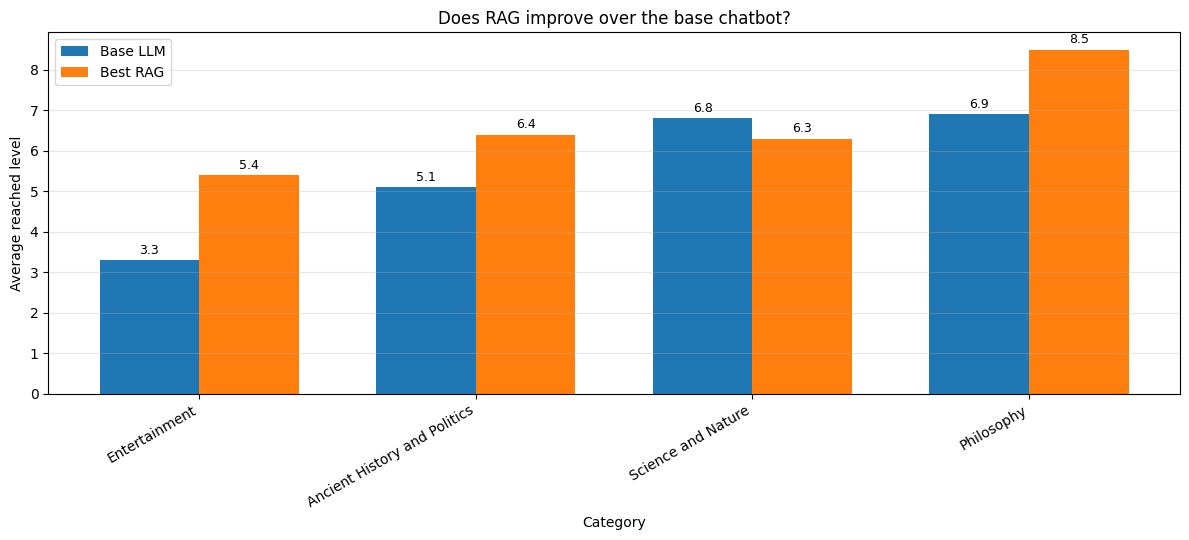

In [ ]:
display(analysis_figures["q1"])

RAG generally improves basic chatbot in most of the considered categories, but the effect is not uniform.
However, RAG does not improve performance in every case. In Science and Nature, the base LLM performs slightly better than RAG.
This suggests that retrieval is especially useful in categories where external factual context helps the model reduce uncertainty or recover specific information. At the same time, when the base model already has strong internal knowledge, as in Science and Nature, adding retrieved context can introduce noise or unnecessary complexity, reducing the final performance slightly.

### Which RAG technique works best for each category?

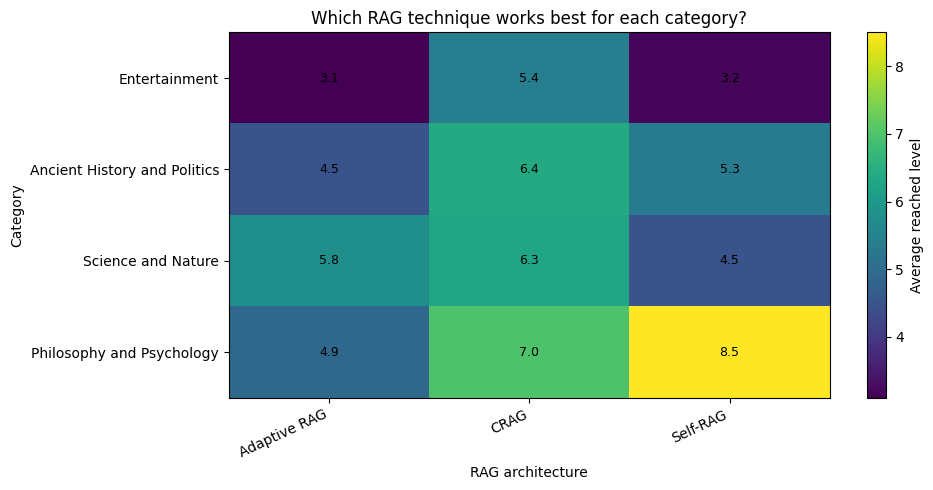

In [ ]:
display(analysis_figures["q2"])

This chart shows that there is no single advanced architecture that is best overall: CRAG is the most stable choice across multiple categories, while Self-RAG achieves the best result in Philosophy and Psychology but performs worse in Entertainment and Science.

Adaptive RAG does not dominate any category, suggesting that the automatic selector does not always choose the most effective strategy compared with a specialized configuration such as CRAG or Self-RAG.


### Are you able to answer questions within the 30 seconds? (rag only)

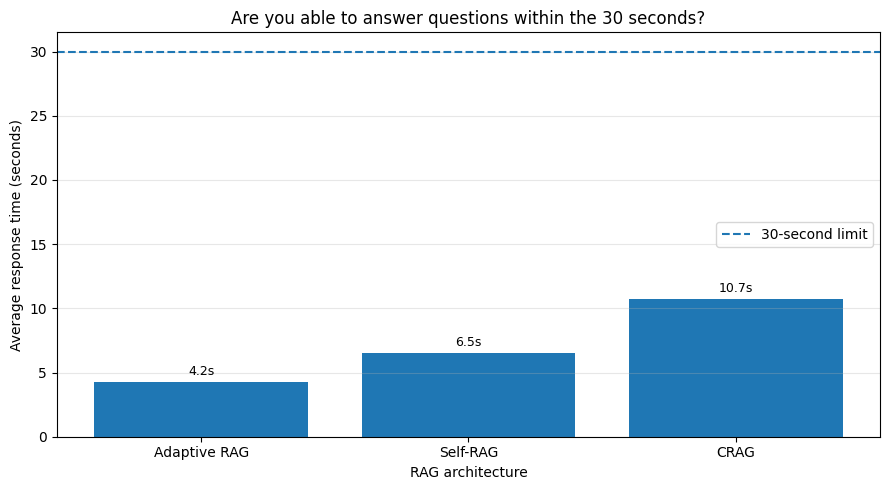

In [ ]:
display(analysis_figures["q3"])

All advanced RAG architectures remain well below the 30-second limit on average, so they are compatible with the game constraint. Adaptive RAG is the fastest, while CRAG is the slowest because it adds more retrieval, routing, and correction steps.

This suggests that the performance differences between architectures are not mainly due to timeout issues: even the most expensive architecture, CRAG, stays safely within the allowed response time.


### Are bigger models better than smaller models? (rag only)

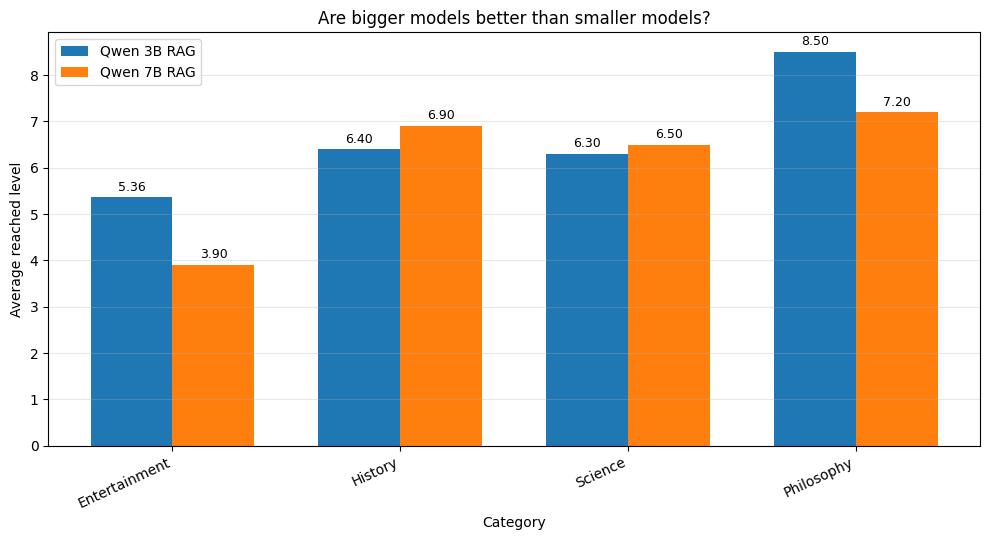

In [ ]:
display(analysis_figures["q4"])

This chart suggests that using a larger model does not automatically improve RAG performance in every category: Qwen 7B is worse than Qwen 3B in Entertainment and almost identical in Ancient History and Politics.

However, Qwen 7B performs clearly better in Science and Nature and Philosophy and Psychology, suggesting that model size helps more in categories requiring stronger reasoning or more effective use of retrieved context.


### Does bigger Wikipedia improve RAG?

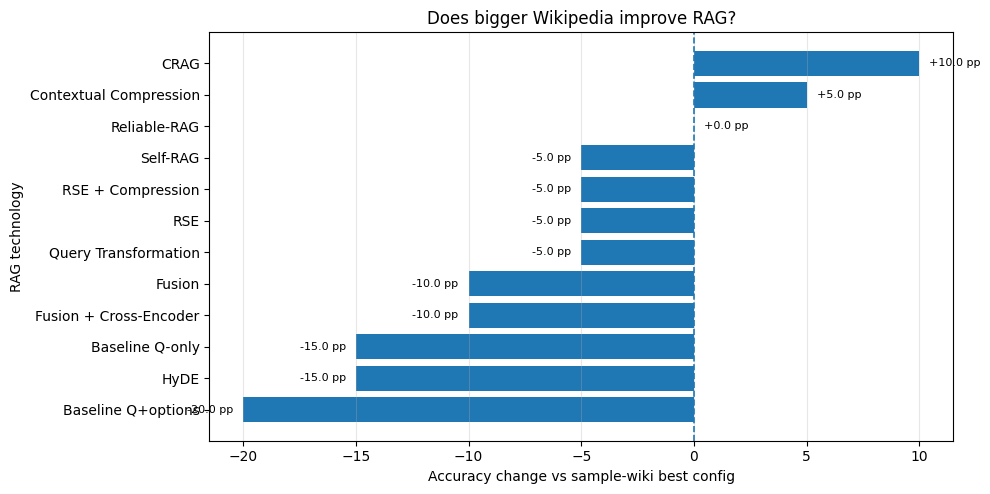

In [ ]:
display(analysis_figures["q5"])

### Is the model often overconfident in its answers and does that affect its performance?

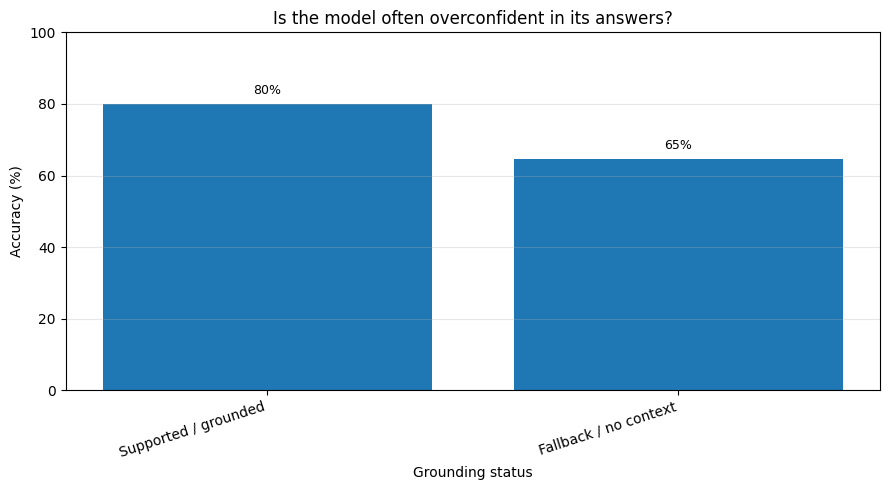

In [ ]:
display(analysis_figures["q6"])

The chart shows that answers classified as supported or grounded are substantially more reliable, reaching 80% accuracy. When the system falls back or has no usable context, accuracy drops to 65%, suggesting that missing or weak evidence negatively affects performance.

### Web for news

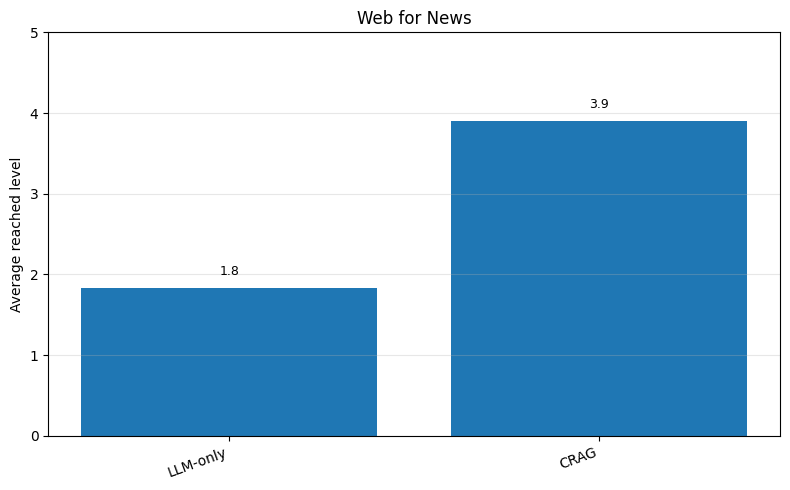

In [ ]:
display(analysis_figures["q7"])

## Play game with Rag


In [ ]:
# 1. Load and display best configs for the current model
BEST_CONFIGS_FOR_CURRENT_MODEL = refresh_best_configs_for_current_model(
    verbose=True,
    display_table=True,
)

Current model:
Qwen/Qwen2.5-3B-Instruct

Benchmark hash:
208f033deb4f6166cd10ce46fc8eb4c2

Current model hash:
dc7c68033a18f81696395420280d55a4

Loaded 6 configs from rag_baseline_reliable
Exact current hash match: True
Summary path: /content/gdrive/MyDrive/NLP/PoliMillionaire/ASSO_RAG/Benchmark/benchmark_cache/rag_baseline_reliable/benchmark_208f033deb4f6166cd10ce46fc8eb4c2/model_dc7c68033a18f81696395420280d55a4/summary/rag_benchmark_summary.json

Loaded 8 configs from query_enhancement
Exact current hash match: True
Summary path: /content/gdrive/MyDrive/NLP/PoliMillionaire/ASSO_RAG/Benchmark/benchmark_cache/query_enhancement/benchmark_208f033deb4f6166cd10ce46fc8eb4c2/model_dc7c68033a18f81696395420280d55a4/summary/query_enhancement_benchmark_summary.json

Loaded 8 configs from context_enrichment
Exact current hash match: True
Summary path: /content/gdrive/MyDrive/NLP/PoliMillionaire/ASSO_RAG/Benchmark/benchmark_cache/context_enrichment/benchmark_208f033deb4f6166cd10ce46fc8eb4c2/model_

,RAG key,Technology,Best configuration,Config name,Correct,Accuracy,Avg. time
1,crag,CRAG,"CRAG, local-first + web fallback, semantic q+o...",crag_local_web_qopts,17/20,85%,9.89s
8,reliable_rag,Reliable-RAG,"Reliable-RAG, question-only, top-4",reliable_qonly_top4,16/20,80%,3.35s
3,fusion_rag,Fusion / Advanced Retrieval RAG,"Fusion Retrieval, semantic q+opts + BM25 q-onl...",fusion_sem_qopts_bm25_qonly_top8,16/20,80%,4.27s
0,contextual_compression_rag,Contextual Compression RAG,"Contextual Compression, no RSE, top-6, relevan...",compression_qopts_top6_rel_no_rse,16/20,80%,5.26s
9,rse_contextual_compression_rag,RSE + Contextual Compression RAG,"RSE + Compression, top-6, relevance filter",rse_compression_qopts_top6_rel_total5,16/20,80%,6.18s
4,hyde_rag,HyDE-RAG,"HyDE, with options, top-4, no relevance filter",hyde_with_options_top4_no_rel,16/20,80%,6.87s
5,query_transformation_rag,Query Transformation RAG,"Query Transformation, question + options, top-...",qt_qopts_top6_rel,16/20,80%,10.91s
7,rag_question_options,Baseline RAG question + options,"Baseline RAG, question + options, top-4",baseline_qopts_top4,15/20,75%,1.35s
6,rag_baseline_question_only,Baseline RAG question-only,"Baseline RAG, question-only, top-4",baseline_qonly_top4,15/20,75%,1.52s
11,self_rag,Self-RAG,"Self-RAG, top-6 retrieval, max 2 final contexts",self_rag_top6_ctx2,15/20,75%,4.26s



Saved best configs JSON:
/content/gdrive/MyDrive/NLP/PoliMillionaire/ASSO_RAG/Benchmark/best_configs/benchmark_208f033deb4f6166cd10ce46fc8eb4c2/model_dc7c68033a18f81696395420280d55a4/best_configs_by_play_key.json

Saved best configs CSV:
/content/gdrive/MyDrive/NLP/PoliMillionaire/ASSO_RAG/Benchmark/best_configs/benchmark_208f033deb4f6166cd10ce46fc8eb4c2/model_dc7c68033a18f81696395420280d55a4/best_configs_by_play_key.csv

Loaded News-specific benchmark summaries
Rows: 15
Exact current hash match: False
Summary path:
/content/gdrive/MyDrive/NLP/PoliMillionaire/ASSO_RAG/Benchmark/benchmark_cache/news_web_crag_eval/benchmark_4b830bd491accec0e984febd6b6cd7ef/model_4046e968d3f616312c3ad7b39ace3f26/summary/news_web_crag_all_configs_with_true_chunking_summary.json

Best News-specific CRAG configuration


,Category,RAG key,Best configuration,Config name,Correct,Accuracy,Avg. time,Max time,Selection rule
0,News,crag,"News force-web, LLM query rewrite, top-4",news_force_web_rewrite_top4,11/15,73%,6.95s,9.62s,"accuracy first, avg time tie-breaker, max_time..."


In [ ]:
# basic architectures

# "reliable_rag"
# "query_transformation_rag"
# "hyde_rag"
# "rse_rag"
# "contextual_compression_rag"
# "rse_contextual_compression_rag"
# "fusion_rag"
# "fusion_cross_encoder_rag"

# advanced architectures

# "adaptive_best_config_rag"
# "self_rag"
# "crag"

In [ ]:
# 1. Choose what to play
SELECTED_CONFIGURATION = "crag"

# 2. Activate and play with clean debug
play_selected_configuration_debug(
    SELECTED_CONFIGURATION,
    use_best_if_available=True,
)

Using cached best configuration:
- RAG key: crag
- Config: crag_local_web_qopts
- Label: CRAG, local-first + web fallback, semantic q+opts + BM25 q-only
- Accuracy: 85%
- Avg time: 9.89s

Selected configuration: crag
Configuration source: cached_best
ADVANCED DEBUG PLAY MODE
Selected configuration: crag
Use best if available: True
Competition id: 4
Category name: Ancient History and Politics

--- Level 1 ---
Q: Which of the following best describes dehumanization?

  [0] The process of treating individuals or groups as less than human
  [1] The process of improving the social status of a group
  [2] The process of giving human traits to non-human entities
  [3] The process of teaching moral values to individuals

Time remaining: 29.9s
Active strategy: local_wikipedia_rag

🛠️ CRAG debug flow

❓ Question
------------------------------------------------------------------------------------------
Which of the following best describes dehumanization?

Options:
  [0] The process of treating i

In [ ]:
# 1. Choose what to play
SELECTED_CONFIGURATION = "adaptive_best_config_rag"

# 2. Activate and play with clean debug
play_selected_configuration_debug(
    SELECTED_CONFIGURATION,
    use_best_if_available=True,
    competition_id=int(comp_id),
)

No cached best config found for 'adaptive_best_config_rag'.
Using fallback/default activation.

Adaptive RAG activated.
default_profile: balanced
debug: True
Selected configuration: adaptive_best_config_rag
Configuration source: fallback_default
ADVANCED DEBUG PLAY MODE
Selected configuration: adaptive_best_config_rag
Use best if available: True
Competition id: 5
Category name: Ancient History and Politics

--- Level 1 ---
Q: According to the article published on 2026-05-17, which North Korean women's football club arrived in South Korea for the AFC Women's Champions League semi-final?

  [0] Suwon FC Women
  [1] Naegohyang FC
  [2] Tokyo Verdy
  [3] Melbourne City

Time remaining: 29.9s
Active strategy: local_wikipedia_rag
Using cached best configuration:
- RAG key: rag_question_options
- Config: baseline_qopts_top8
- Label: Baseline RAG, question + options, top-8
- Accuracy: 80%
- Avg time: 0.90s

Selected configuration: rag_question_options
Configuration source: cached_best

🧭 Adapt

# MATH

IMPORT FOR TOOLS USING LANGCHAIN

In [ ]:
import torch
import math
import re
import json
from langchain_core.tools import tool, render_text_description
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.runnables import RunnableConfig, RunnablePassthrough
from typing import Any, Dict, Optional, TypedDict

In [ ]:
import sympy
from sympy.parsing.sympy_parser import (
    parse_expr,
    standard_transformations,
    implicit_multiplication_application,
)

# ── sympy namespace exposed inside the tool ───────────────────────────────────
_SYMPY_LOCALS = {
    "sqrt":      sympy.sqrt,
    "cbrt":      lambda x: sympy.Pow(x, sympy.Rational(1, 3)),
    "Rational":  sympy.Rational,
    "factorial": sympy.factorial,
    "gcd":       sympy.gcd,
    "lcm":       sympy.lcm,
    "floor":     sympy.floor,
    "ceiling":   sympy.ceiling,
    "log":       sympy.log,
    "ln":        sympy.ln,
    "sin":       sympy.sin,
    "cos":       sympy.cos,
    "tan":       sympy.tan,
    "pi":        sympy.pi,
    "E":         sympy.E,
    "I":         sympy.I,
    "oo":        sympy.oo,
    "Mod":       sympy.Mod,
    # calculus / algebra helpers
    "diff":      sympy.diff,
    "integrate": sympy.integrate,
    "solve":     sympy.solve,
    "solveset":  sympy.solveset,
    "limit":     sympy.limit,
    "symbols":   sympy.symbols,
    # equation / expression helpers
    "Eq":        sympy.Eq,
    "expand":    sympy.expand,
    "factor":    sympy.factor,
    "collect":   sympy.collect,
    "Abs":       sympy.Abs,
    # combinatorics
    "binomial":  sympy.binomial,
    # linear algebra
    "Matrix":    sympy.Matrix,
    # numerical fallback
    "nsolve":    sympy.nsolve,
    # pre-bound common symbols
    "x": sympy.Symbol("x"), "y": sympy.Symbol("y"),
    "z": sympy.Symbol("z"), "n": sympy.Symbol("n"),
    "k": sympy.Symbol("k"), "m": sympy.Symbol("m"),
}

##Defining tools

Basic calculator implementation, using eval() function

In [ ]:
@tool
def calculator_basic(expression: str) -> str:
    """
    Use this tool to evaluate complex mathematical expressions.
    """
    try:
        expression = expression.replace("^", "**")
        safe_dict = {
            "abs": abs, "round": round, "min": min, "max": max,
            "math": math, "sqrt": math.sqrt, "pow": pow, "pi": math.pi,
            "sin": math.sin, "cos": math.cos, "tan": math.tan
        }
        result = eval(expression, {"__builtins__": None}, safe_dict)
        return str(result)
    except Exception as e:
        return f"Error evaluating expression. Check your syntax. Details: {e}"


Calculator based on SimPy evaluation function (more advanced)

In [ ]:
@tool
def calculator(expression: str) -> str:
    """
    Evaluate a mathematical expression exactly using sympy.
    Supported syntax:
      ** for powers | sqrt(x) | cbrt(x) for cube root
      Rational(a, b) for exact fractions | factorial(n)
      Mod(a, n) for modular arithmetic | I for the imaginary unit sqrt(-1)
      log(x) | sin(x) | cos(x) | tan(x) | pi | E | gcd(a,b) | lcm(a,b)
      diff(expr, var) | solve(expr, var) | integrate(expr, var) | limit(expr, var, point)
    """
    # Normalise caret-power notation that LLMs often emit (e.g. x^2 → x**2)
    expression = expression.replace("^", "**")
    print(f"    [sympy] parsing: {expression!r}")
    try:
        transformations = standard_transformations + (implicit_multiplication_application,)
        expr_obj = parse_expr(expression, local_dict=_SYMPY_LOCALS,
                              transformations=transformations)
        print(f"    [sympy] parsed tree: {expr_obj}")

        # solve() and similar return a plain Python list — handle without simplify
        if isinstance(expr_obj, (list, tuple)):
            result = ", ".join(str(e) for e in expr_obj)
            print(f"    [sympy] → result (list): {result!r}")
            return result

        simplified = sympy.simplify(expr_obj)
        print(f"    [sympy] simplified: {simplified}")
        try:
            numeric = float(simplified)
            result = str(int(numeric)) if numeric == int(numeric) else f"{numeric:.8g}"
        except (TypeError, ValueError):
            result = str(simplified)
        print(f"    [sympy] → result: {result!r}")
        return result
    except Exception as exc:
        err = f"Error: {exc}"
        print(f"    [sympy] → {err}")
        return err

In [ ]:
tools = [calculator]
rendered_tools = render_text_description(tools)

print(f"Rendered tool text: {rendered_tools}")

Rendered tool text: calculator(expression: str) -> str - Evaluate a mathematical expression exactly using sympy.
Supported syntax:
  ** for powers | sqrt(x) | cbrt(x) for cube root
  Rational(a, b) for exact fractions | factorial(n)
  Mod(a, n) for modular arithmetic | I for the imaginary unit sqrt(-1)
  log(x) | sin(x) | cos(x) | tan(x) | pi | E | gcd(a,b) | lcm(a,b)
  diff(expr, var) | solve(expr, var) | integrate(expr, var) | limit(expr, var, point)


In [ ]:
class ToolCallRequest(TypedDict):
    """A typed dict that shows the inputs into the invoke_tool function."""
    name: str
    arguments: Dict[str, Any]

def invoke_tool(tool_call_request: ToolCallRequest):
    """A function that we can use the perform a tool invocation.

    Args:
        tool_call_request: a dict that contains the keys name and arguments.
            The name must match the name of a tool that exists.
            The arguments are the arguments to that tool.

    Returns:
        output from the requested tool
    """

    tool_name_to_tool = {tool.name: tool for tool in tools}
    name = tool_call_request["name"]
    requested_tool = tool_name_to_tool[name]
    return requested_tool.invoke(tool_call_request["arguments"])

 [Approach] Try to reason on each options and step by step remove the ones that doesn't fit.

 This approach required way more time than we expected --> time out every time

## Defining math prompts

Firstly, we define our small DB of examples to give for few-shots prompting strategy

### Examples for few-shot prompting


In [ ]:
MASTER_EXAMPLES_DB = {
    "arithmetic": [
        {
            "q": "What is (145 * 12) + sqrt(144)?",
            "options": "[1] 1724  [2] 1752  [3] 1800  [4] 1740",
            "expr": "(145 * 12) + sqrt(144)",
            "tool_result_str": "1752, which is option 2.",
            "a": "2"
        },
        {
            "q": "If a company's revenue grows from $250,000 to $312,500, what is the percentage increase?",
            "options": "[1] 20%  [2] 25%  [3] 30%  [4] 15%",
            "expr": "((312500 - 250000) / 250000) * 100",
            "tool_result_str": "25, which is option 2.",
            "a": "2"
        },
        {
            "q": "What is the area of a circle with a radius of 7 meters? (Use pi = 3.14159)",
            "options": "[1] 143.24  [2] 43.98  [3] 153.94  [4] 49.00",
            "expr": "3.14159 * 7^2",
            "tool_result_str": "153.93791, which rounds to 153.94, corresponding to option 3.",
            "a": "3"
        }
    ],
    "theory": [
        {
            "q": "Which of the following describes a tautology in propositional logic?",
            "options": "[1] A statement that is always false\n[2] A statement that is always true\n[3] A statement whose truth value depends on the components\n[4] An unprovable statement assumed to be true",
            "a": "2"
        },
        {
            "q": "According to the Mean Value Theorem, if a function f is continuous on [a, b] and differentiable on (a, b), then there exists at least one c in (a, b) such that:",
            "options": "[1] f'(c) = 0\n[2] f'(c) = (f(b) - f(a)) / (b - a)\n[3] f(c) = 0\n[4] f'(c) = f(b) - f(a)",
            "a": "2"
        },
        {
            "q": "Which property states that for any real numbers a and b, a + b = b + a?",
            "options": "[1] Associative Property\n[2] Distributive Property\n[3] Commutative Property\n[4] Identity Property",
            "a": "3"
        },
        {
            "q": "If two events A and B are independent, which of the following equations must hold true?",
            "options": "[1] P(A and B) = P(A) + P(B)\n[2] P(A or B) = P(A) * P(B)\n[3] P(A and B) = P(A) * P(B)\n[4] P(A given B) = P(B)",
            "a": "3"
        },
        {
            "q": "What is the definition of a prime number?",
            "options": "[1] A number divisible by 2\n[2] A whole number greater than 1 whose only divisors are 1 and itself\n[3] Any odd number greater than 1\n[4] A number that can be expressed as a product of two equal integers",
            "a": "2"
        }
    ],
    "logic": [
        {
            "q": "What is the contrapositive of the conditional statement: 'If it rains, then the ground is wet'?",
            "options": "[1] If the ground is wet, then it rains.\n[2] If it does not rain, then the ground is not wet.\n[3] If the ground is not wet, then it does not rain.\n[4] It rains and the ground is not wet.",
            "r": "The contrapositive of P → Q is ¬Q → ¬P. Negating and reversing both clauses gives: 'If the ground is not wet, then it does not rain.'",
            "a": "3"
        },
        {
            "q": "Which of the following represents the negation of the statement: 'For all real numbers x, x^2 >= 0'?",
            "options": "[1] For all real numbers x, x^2 < 0.\n[2] There exists a real number x such that x^2 < 0.\n[3] There exists a real number x such that x^2 >= 0.\n[4] For no real numbers x, x^2 >= 0.",
            "r": "The negation of a universal quantifier (∀x, P(x)) is an existential quantifier with a negated predicate (∃x, ¬P(x)). Thus, 'For all x, x^2 >= 0' becomes 'There exists an x such that x^2 < 0.'",
            "a": "2"
        },
        {
            "q": "The logical expression P ∨ (P ∧ Q) is logically equivalent to which of the following simpler expressions by the Absorption Law?",
            "options": "[1] P\n[2] Q\n[3] P ∧ Q\n[4] True",
            "r": "By the Absorption Law in Boolean algebra and formal logic, the term (P ∧ Q) is entirely contained within P during a disjunction, simplifying the statement P ∨ (P ∧ Q) down to just P.",
            "a": "1"
        },
        {
            "q": "Which valid rule of inference is represented by the argument form: 'P → Q, ¬Q, therefore ¬P'?",
            "options": "[1] Modus Ponens\n[2] Modus Tollens\n[3] Hypothetical Syllogism\n[4] Disjunctive Syllogism",
            "r": "Modus Tollens (denying the consequent) states that if a conditional statement is true and its consequent is false, then its antecedent must also be false.",
            "a": "2"
        },
        {
            "q": "Under which assignment of truth values is the material implication P → Q false?",
            "options": "[1] P is True, Q is True\n[2] P is False, Q is True\n[3] P is False, Q is False\n[4] P is True, Q is False",
            "r": "A material implication P → Q is defined as false if and only if the antecedent (P) is true and the consequent (Q) is false.",
            "a": "4"
        }
    ]
}

In [ ]:
import random

def get_examples(q_type, n=0):
    if n <= 0:
        return ""

    category_list = MASTER_EXAMPLES_DB.get(q_type)
    if not category_list:
        return ""

    sampled = random.sample(category_list, min(n, len(category_list)))
    formatted_examples = []

    for ex in sampled:

        if q_type == "arithmetic":
            example_str = (
                f"## Example\n"
                f"Q: {ex['q']}  {ex['options']}\n"
                f"<tool_call>\n"
                f'{{"name": "calculator", "arguments": {{"expression": "{ex["expr"]}"}}}}\n'
                f"</tool_call>\n\n"
                f"tool_result = {ex['tool_result_str']}\n"
                f"Answer: {ex['a']}"
            )

        elif q_type == "logic":
            example_str = (
                f"## Example\n"
                f"Q: {ex['q']}\n"
                f"Options:\n{ex['options']}\n"
                f"Reasoning: {ex['r']}\n"
                f"Answer: {ex['a']}"
            )

        elif q_type == "theory":
            example_str = (
                f"## Example\n"
                f"Q: {ex['q']}\n"
                f"Options:\n{ex['options']}\n"
                f"Answer: {ex['a']}"
            )

        formatted_examples.append(example_str)

    return "\n\n".join(formatted_examples)

In [ ]:
# PROMPT FOR INITIAL QUESTION CLASSIFICATION
ROUTER_PROMPT = """
You are a classifier for math multiple-choice questions.
Classify the question into EXACTLY ONE of these three categories:

- arithmetic  → calculations, algebraic manipulation, numeric computation
- logic       → reasoning, deductions, multi-step thinking, proofs
- theory      → recalling formulas, definitions, theorems, factual knowledge

Rules:
- Your entire response must be a SINGLE word
- That word must be one of: arithmetic, logic, theory
- No punctuation, no explanation, no other text
"""

# PROMPT FOR LOGIC
REASONING_PROMPT = """
You are a math assistant playing a multiple-choice quiz.

Rules:
- Solve step-by-step briefly.
- Use concise reasoning.
- Think efficiently and minimize unnecessary explanation.
- Focus only on key deductions.
- Avoid long explanations on obvious reasoning.
- Output your final answer on its own line: Answer: <option number>

"""

# PROMPT FOR ARITHMETIC
CALCULATOR_SYSTEM_PROMPT = f"""
You are a math assistant playing a multiple-choice quiz.
You have access to the following tools:
{rendered_tools}

## Rules
- Use the calculator tool whenever the question requires evaluating an arithmetic expression.
- Emit exactly this structure and wait for the result:

<tool_call>
{{"name": "calculator", "arguments": {{"expression": "<math_expression>"}}}}
</tool_call>

- After receiving the result, elaborate it and output your final answer on its own line: Answer: <option number>
"""

# PROMPT FOR THEORY (must be modified for RAG usage)
THEORY_SYSTEM_PROMPT = """
You are a math theory multiple-choice solver.
Questions may involve theorems, definitions, axioms, properties, logic, algebra, analysis, geometry, probability, or factual mathematical knowledge.

-Answer quickly and directly.
-Avoid long reasoning or step-by-step explanations.
-Use concise high-confidence inference only.
-Output your final answer on its own line: Answer: <option number>
"""

#PROMPT FOR FACT CHECKING ON WEB SEARCH
FACT_CHECKER_SYSTEM_PROMPT = """
You are a mathematics fact-checker.
Your sole task is to determine if the provided web evidence clearly and unambiguously identifies the correct option for the given multiple-choice math question.

Rules:
- If the evidence clearly points to a single correct option, reply exactly in this format: Decision: <option number>
- If the evidence is unclear, ambiguous, missing, conflicting, or insufficient, reply exactly in this format: Decision: UNSURE

Example:
Decision: 2
"""

In [ ]:
#PROMPT OF ONECALL FUNCTION (base prompt)
# starting call prompt onecall
_AGENTIC_SYSTEM = """\
You are a math assistant solving a multiple-choice quiz question.
You have access to a calculator tool that evaluates sympy expressions exactly.

To call the tool, output ONLY a JSON block like this:
```json
{"name": "calculator", "arguments": {"expression": "<sympy expression>"}}
```
Supported syntax inside "sympy expression", DO NOT PUT OTHER THINGS:
      ** for powers | sqrt(x) | cbrt(x) for cube root
      Rational(a, b) for exact fractions | factorial(n)
      Mod(a, n) for modular arithmetic | I for the imaginary unit sqrt(-1)
      log(x) | sin(x) | cos(x) | tan(x) | pi | E | gcd(a,b) | lcm(a,b)
      diff(expr, var) | solve(expr, var) | integrate(expr, var) | limit(expr, var, point)

Use the tool for ANY numerical computation — including modular arithmetic and
imaginary unit powers. After receiving the tool result, reason briefly about
which answer option matches the result (options may be text, not just numbers),
then on the LAST line write exactly:
  Answer: <ID>   (ID is 0, 1, 2, or 3)

If no computation is needed (pure theory), skip the tool and go straight to:
  Answer: <ID>
"""

# PROMPT OF ONECALL FUNCTION (first step prompt)
# planning prompt that gives theory answer only if possible or sequence of functions to be called by the calculator tool (sympy)
PLANNING_PROMPT = """\
Reason step by step:
1. Can this be answered from theory alone, or does it need computation (even simple operations must be done with computations)?
   - If theory only: give your reasoning and end with "Answer: <ID>".
   - If computation needed: state the exact sympy expression to compute in at most 4 lines
     (no named functions like f(x,y), e.g. diff(x**2 - 2*x*y + y**3, x))."""


In [ ]:
# used by the llm answer with classify but no calc
# IF NOT USED ANYMORE (BE SURE), you can delete it
def build_math_prompt_few_shot(question_text, options, question_type):
    options_text = format_options(options)
    examples_block = get_examples(question_type, CONFIG["n-shots"])

    if question_type == 'arithmetic':
        task_hint = (
            "Work through the arithmetic step by step, then output ONLY the option ID.\n"
            "On the last line write: Answer: <ID>"
        )
    elif question_type == 'logic' or question_type == 'theory':
        task_hint = (
            "Analyse each option using mathematical definitions and theorems.\n"
            "On the last line write: Answer: <ID>"
        )

    system_message = (
        "You are playing a multiple-choice math quiz game.\n"
        f"You are an expert of {competitions[COMP_ID].name}.\n"
        "Choose the correct answer for the question delimited by triple backticks.\n\n"
        f"Follow this hint:\n{task_hint}\n"
        f"Examples:\n\n{examples_block}"
    )
    user_message = (
        f"```{question_text}```\n\n"
        f"Options:\n{options_text}\n\n"
        "Answer:"
    )
    return system_message, user_message

In [ ]:
def build_prompt_math(q_type, question_text, options):

    examples_block = get_examples(q_type, CONFIG["n-shots"])

    if q_type == "arithmetic":
        base_prompt = CALCULATOR_SYSTEM_PROMPT
    elif q_type == "logic":
        base_prompt = REASONING_PROMPT
    elif q_type == "theory":
        base_prompt = THEORY_SYSTEM_PROMPT

    system_message = f"{base_prompt}\n\n{examples_block}" #.strip()

    options_text = format_options(options)
    user_message = (
        f"```{question_text}```\n"
        f"Options:\n{options_text}"
    )

    return system_message, user_message

## Extraxt Tool Call <>  tags.

In [ ]:
def extract_tool_call(model_output):

    # Isola ciò che c'è denttro <tool_call> ... </tool_call>
    match = re.search(r"<tool_call>\s*(.*?)\s*</tool_call>", model_output, re.DOTALL)

    if not match:
        return None

    raw_inner_content = match.group(1)

    # Give the JSON content inside the tags to a repair function
    perfect_json = clean_and_repair_tool_json(raw_inner_content)

    if not perfect_json:
        print("[ERROR] Impossible to retreive valid JSON from tags.")
        return None

    return perfect_json

Try to repair the eventual malformed JSON block inside the tool_call tags

In [ ]:
from json_repair import repair_json

def clean_and_repair_tool_json(raw_json_string):

    if not raw_json_string:
        return None

    cleaned = re.sub(r':\s*f(["\'])(.*?)\1', r': "\2"', raw_json_string)

    # Sintactic Repair
    try:
        data = json.loads(cleaned)
    except json.JSONDecodeError:
        try:
            repaired = repair_json(cleaned)
            data = json.loads(repaired)
        except Exception:
            # Se la stringa è troppo corrotta , ritorna None
            return None

    # Se l'output non è un dizionario, non è un tool call valido
    if not isinstance(data, dict):
        return None

    # Estrai il nome del tool (gestendo allucinazioni sul nome del campo)
    tool_name = data.get("name") or data.get("tool") or data.get("function") or "unknown"

    # Estrai gli argomenti (gestendo variazioni di nome)
    raw_args = data.get("arguments") or data.get("args") or data.get("parameters") or {}

    # Se gli argomenti non sono un dizionario (es. il modello ha scritto "arguments": "sin(2)")
    # proviamo a recuperarlo mettendolo nel campo expression
    if not isinstance(raw_args, dict):
        expression_value = str(raw_args)
    else:
        # Cerca il campo expression (o variazioni comuni come 'expr', 'calc', 'value')
        expression_value = (raw_args.get("expression") or raw_args.get("expr") or raw_args.get("value") or  "")

    # Ricostruzione dello schema perfetto ---
    perfect_json = {
        "name": str(tool_name),
        "arguments": {
            "expression": str(expression_value)
        }
    }

    #print(f"Perfect JSON: {perfect_json}")
    return perfect_json

## Helper functions plan
A set of functions used by the ***get_llm_agentic_onecall*** function to parse, check, modify the results according to the sympy calculator tool used, and output a correct response.

In [ ]:
import sympy
from sympy.parsing.sympy_parser import (
    parse_expr,
    standard_transformations,
    implicit_multiplication_application,
)

_TRANSFORMATIONS = standard_transformations + (implicit_multiplication_application,)

# prints a certain label with a separator in between to have a clean view
def print_sep(label=""):
    print(f"  {'─'*20} {label} {'─'*20}" if label else f"  {'─'*50}")

# matches the tool solution to the options (sometimes they are formatted differently)
def match_result_to_option(result_str, options):
    """
    Try to symbolically match a tool result string against each option text.
    Uses sympy with implicit_multiplication so '2*x' matches '2x', etc.
    Returns the matching option ID, or None if no symbolic match is found.
    """
    try:
        result_expr = parse_expr(result_str, transformations=_TRANSFORMATIONS)
    except Exception:
        return None

    for opt in options:
        try:
            opt_expr = parse_expr(opt.text, transformations=_TRANSFORMATIONS)
            if sympy.simplify(result_expr - opt_expr) == 0:
                print(f"  Symbolic match: {result_str!r} == [{opt.id}] {opt.text!r}")
                return opt.id
        except Exception:
            continue
    return None

# validates the expression hints given by the reasoning/planning part as correct sympy parsing
def validate_expr_hint(hint: str) -> bool:
    """
    Dry-run hint through parse_expr + _SYMPY_LOCALS.
    Returns False if unparseable or if it collapses to a plain Python bool
    (which happens when '==' comparisons are used instead of sympy Eq/solve).
    """
    try:
        result = parse_expr(hint, local_dict=_SYMPY_LOCALS,
                            transformations=_TRANSFORMATIONS)
        return not isinstance(result, bool)
    except Exception:
        return False

# returns the think suffix string to avoid the thinking block of deepseek distill models
def get_think_suffix(tokenizer):
  think_suffix = ""
  if CONFIG["model_id"] == "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B" or CONFIG["model_id"] == "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B":
    think_ids = tokenizer.encode("<think>", add_special_tokens=False)
    if len(think_ids) == 1:
      think_suffix = "<think>\n</think>\n"
  return think_suffix

# returns an answer id if present in the output
def find_answer_in_output(output, valid_ids):
  m = re.search(r'Answer[\s:]+([0-9]+)', output, re.IGNORECASE)
  if m:
    ans = int(m.group(1))
    if ans in valid_ids:
      print(f"  Theory answer : {ans}")
      print_sep("ANSWER")
      print(f"  → {ans}")
      return ans

# extracts the calculator expression it found after validating it through another function
def extract_expr_hint(reasoning_output):
  expr_hint = ""
  expr_match = re.search(r'"expression"\s*:\s*"([^"]+)"', reasoning_output)
  if expr_match:
      candidate = expr_match.group(1).strip()
      if validate_expr_hint(candidate):
          expr_hint = candidate
          print(f"  Expr hint     : {expr_hint!r}")
      else:
          print(f"  Expr hint     : discarded (invalid sympy: {candidate!r})")
  return expr_hint

# returns the json tool request and the match
def find_tool_call_json(output):
  tool_match = re.search(
        r'```(?:json)?\s*(\{.*"name"\s*:\s*"calculator".*\})\s*```',
        output, re.DOTALL
    )
  # it may not put the json tag in front sometimes
  if not tool_match:
      tool_match = re.search(
          r'(\{"name"\s*:\s*"calculator".*\})',
          output, re.DOTALL
      )
  tool_request_json = None
  if tool_match:
    raw_json = tool_match.group(1)
    tool_request_json = json.loads(raw_json)
  return tool_match, tool_request_json


##Answer preparation

In [ ]:
def parse_answer(output, valid_ids):

    # First direct check
    match = re.search(r'(?:Answer|Answer is)[\s:]*([0-9]+)', output, re.IGNORECASE)
    if match:
        ans = int(match.group(1))
        if ans in valid_ids:
            return ans

    # Find the last number produced
    numbers = re.findall(r'\b\d+\b', output)
    if numbers:
        ans = int(numbers[-1])
        if ans in valid_ids:
            return ans
    return None

def format_options(options):
    return "\n".join([f"[{opt.id}] {opt.text}" for opt in options])

In [ ]:
def generate_answer(prompt, tokenizer, model, max_new_tokens=600, temperature=0.2):

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_len = inputs["input_ids"].shape[-1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            tokenizer = tokenizer,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=temperature,
            #use_cache = True,
        )

    pruned_output = tokenizer.decode(
        outputs[0][prompt_len:],
        skip_special_tokens=True
    ).strip()

    return pruned_output

## ROUTER CLASSIFIER

Ask the model to classify the questions between CALCULATION / THEORIC. Then give different prompts.

We could have tried to train a specific classifier but a generic LLM already gives decent results

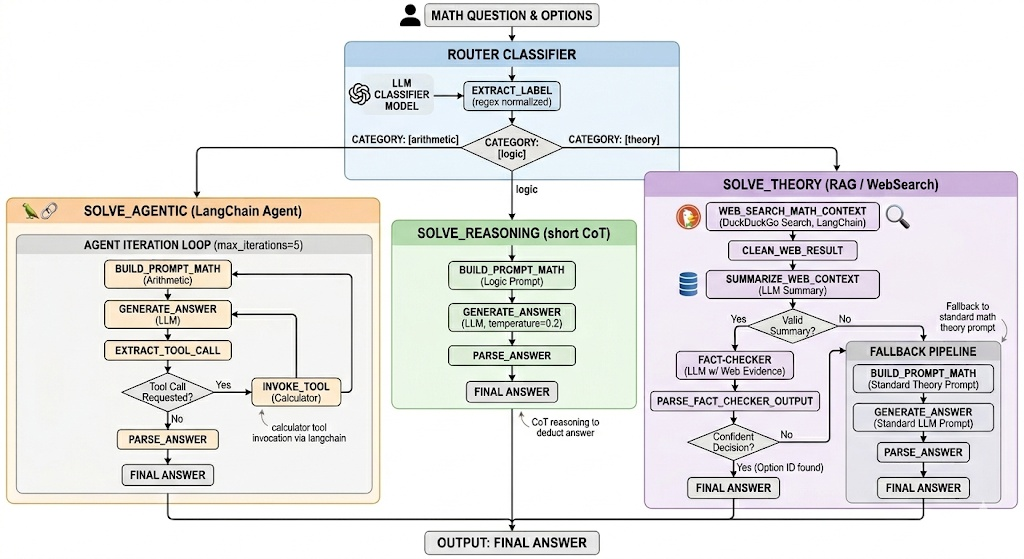

In [ ]:
def extract_label(raw, valid_labels):

    normalized = raw.strip().lower().strip(".,;:!?\"'")

    # Exact match
    if normalized in valid_labels:
        return normalized

    #  Scan for any valid label token in the output
    for label in valid_labels:
        if re.search(rf"\b{label}\b", normalized):
            return label

    #  Fallback
    print(f"Label not recognized from raw output: {repr(raw)} — falling back to 'logic'")
    return "logic"

In [ ]:
# Returns the Question type
def classify_question(question):

    question_text = question.text
    options_text = format_options(question.options)

    user_msg = f"Question: {question_text}\nOptions:\n{options_text}"

    conversation = [
        {"role": "system", "content": ROUTER_PROMPT},
        {"role": "user", "content": user_msg}
    ]

    prompt = classifier_tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)

    raw_label = generate_answer(prompt, classifier_tokenizer, classifier_model, max_new_tokens=CLASSIFIER_CONFIG.get("max_new_tokens"), temperature=CLASSIFIER_CONFIG.get("temperature"))

    valid_labels = ["arithmetic", "logic", "theory"]
    label = extract_label(raw_label, valid_labels)

    print(f"CATEGORY: {label}")
    return label

Route question to proper functions

In [ ]:
# Function called by Play Game
def route_question(question, tokenizer, llm):

    q_type = classify_question(question)

    if q_type == "arithmetic":
        #return get_llm_answer_agentic_onecall(question, tokenizer, model), q_type
        return solve_agentic(q_type, question, tokenizer, llm)

    elif q_type == "logic":
        return solve_reasoning(q_type, question, tokenizer, llm)

    elif q_type == "theory":
        return solve_theory(q_type, question, tokenizer, llm)

### 🤖Arithmetic questions (Calculator)

In [ ]:
def solve_agentic(q_type, question, tokenizer, model, max_iterations=5):

    #Defining the math prompt, according to the classifier
    system_msg, user_msg = build_prompt_math( q_type ,question.text , question.options)

    conversation = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg}
    ]

    #For Debug
    print(f"System message:\n{system_msg}")
    #print(f"User message:\n{user_msg}")

    for iteration in range(max_iterations):

        print("=" * 60)
        print(f"AGENT ITERATION {iteration + 1}")
        print("=" * 60)

        prompt = tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)
        model_output = generate_answer(prompt, tokenizer, model)

        print(f"MODEL OUTPUT: \n{model_output}")

        conversation.append({
            "role": "assistant",
            "content": model_output          # ragionamento + eventuale <tool_call>
        })

        # Check if the model requested a tool call
        tool_call = extract_tool_call(model_output)

        if tool_call is not None:

            print("\nEXECUTING TOOL...\n")
            tool_result = invoke_tool(tool_call)
            print(f"TOOL RESULT: {tool_result}")

            # Append the result to the chat
            conversation.append({
                "role": "user",
                "content": f"tool_result = {tool_result}"
            })
            # Skip the final answer check and move to the next iteration where the result is elaborated
            continue

        # Final answer parsing
        valid_ids = [opt.id for opt in question.options]
        answer = parse_answer(model_output, valid_ids)

        if answer is not None:
            return answer, q_type

        # Last try to get the answer right, if all went wrong
        print("\nFailed to parse tool call or final answer — try to give a generic answer.\n")
        conversation.append({
            "role": "user",
            "content": "Please provide your final answer in the format: Answer: <option number>"
        })

    print("\nMax iterations reached.\n")
    return None, q_type

###📚 Theory questions (RAG/WebSearch)

In [ ]:
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun

# ── Tool Definition ─────────────────────────────────────────────────────

@tool
def search_math_theory(query):
    """
    Web search for mathematical theory context.
    Use this tool when answering theoretical math questions that require
    definitions, theorems, or conceptual explanations.
    Args:
        query: The math concept or theory to search for.
    Returns:
        A string with relevant web search results.
    """
    ddg_search = DuckDuckGoSearchRun()

    return ddg_search.run(query)


# ── Web context helper ──────────────────────────────────────────────────

def web_search_math_context(question_text) :

    # Basic cleanup: remove common conversational filler phrases
    clean_text = re.sub(r'\b(what is|define|explain|describe|give me|can you|the|a|an)\b', '', question_text, flags=re.IGNORECASE)
    search_query = re.sub(r'[^\w\s]', '', clean_text).strip()

    if not search_query:
        search_query = question_text

    try:
        # LangChain tools take arguments directly or via dict depending on schema
        return search_math_theory.invoke(search_query)
    except Exception as e:
        print(f"[WebSearch] Tool invocation failed: {e}")
        return "Search failed"

def clean_web_result(raw) :
    text = re.sub(r'https?://\S+', '', raw)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def summarize_web_context(raw_context, tokenizer, model):
    """Uses the LLM to create a concise, factual summary of the web search results."""

    if not raw_context or "Search failed:" in raw_context:
        return ""

    summary_prompt = (f"""
    Extract and summarize only the relevant mathematical definitions, or
    theorems from this text: {raw_context}
    Be concise and objective."""
    )

    conversation = [{"role": "user", "content": summary_prompt}]
    prompt = tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)
    output = generate_answer(prompt, tokenizer, model, max_new_tokens=512, temperature=0.5)

    print(f"Summary: {output}")
    return output

/tmp/ipykernel_4269/833315680.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [ ]:
def parse_fact_checker_output(output):
    if not output:
        return "UNSURE"

    cleaned = output.strip()

    if re.search(r'decision\s*:?\s*(is)?\s*unsure', cleaned, re.IGNORECASE):
        return "UNSURE"

    # Extract option number limited strictly to [0-3]
    decision_match = re.search(r'decision\s*:?\s*(is|=)?\s*\[?\s*([0-3])', cleaned, re.IGNORECASE)
    if decision_match:
        return int(decision_match.group(2))

    # Last-chance
    if "UNSURE" in cleaned.upper() or "UNCLEAR" in cleaned.upper():
        return "UNSURE"

    return None

In [ ]:
def solve_theory(q_type, question, tokenizer, model):
    valid_ids = [opt.id for opt in question.options]

    # Search the web for the question
    web_context = web_search_math_context(question.text)
    cleaned_search = clean_web_result(web_context)

    print(f"\nRAW WEB SEARCH RESULT: {cleaned_search}\n")

    # Short summarization of the content from the LLM
    web_summary = summarize_web_context(cleaned_search, tokenizer, model)

    use_fallback = False

    # Handle bad/empty web summary right away
    if not web_summary or web_summary.strip() == "":
        use_fallback = True
    else:
        options_text = format_options(question.options)

        system_msg = FACT_CHECKER_SYSTEM_PROMPT
        user_msg = (
            f"```{question.text}```\n"
            f"Options:\n{options_text}"
            f"Web evidence:\n{web_summary}\n\n"
        )

        fc_conversation = [
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ]
        fc_prompt = tokenizer.apply_chat_template(fc_conversation, tokenize=False, add_generation_prompt=True)
        fc_output = generate_answer(fc_prompt, tokenizer, model)

        print(f"\nRAW FACT-CHECKER OUTPUT: {fc_output}\n")

        # Robustly parse the fact-checker output
        decision = parse_fact_checker_output(fc_output)

        # Check if we need to fall back
        if decision == "UNSURE":
            print("[Fact-Checker] Explicit Decision: UNSURE. Fallback.")
            use_fallback = True

        # answer number found
        elif isinstance(decision, int):
            if decision in valid_ids:
                #print(f"\nFinal answer reached confidently via structured Fact-Checker: Option {decision}\n")
                return decision, q_type
            else:
                #print(f"[Fact-Checker] Parsed ID {decision} is out of valid bounds {valid_ids}. Falling back.")
                use_fallback = True
        else:
            print("[Fact-Checker] Formatting structural syntax broke or was completely corrupt. Falling back safely.")
            use_fallback = True

    # Execute Fallback Pipeline if flag is tripped
    if use_fallback:
        print("\nWeb evidence unclear or unavailable. Falling back to standard math theory prompt...\n")
        system_msg, user_msg = build_prompt_math(q_type, question.text, question.options)

    # Generate the final answer
    conversation = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg}
    ]

    prompt = tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)
    model_output = generate_answer(prompt, tokenizer, model, temperature=0.3)

    print("\nMODEL OUTPUT:\n")
    print(model_output)

    answer = parse_answer(model_output, valid_ids)

    if answer is not None:
        print("\nFinal answer reached.\n")
        return answer, q_type

    return answer, q_type

### 🧠Logic questions (short CoT)

In [ ]:
def solve_reasoning(q_type, question, tokenizer, model):

    #Defining the math prompt, according to the classifier
    system_msg, user_msg = build_prompt_math( q_type ,question.text , question.options)

    conversation = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg}
    ]

    prompt = tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)

    #print("\nSYSTEM MESSAGE:\n")
    #print(system_msg)

    model_output = generate_answer(prompt, tokenizer, model, temperature=0.2)

    print("\nMODEL OUTPUT:\n")
    print(model_output)

    valid_ids = [opt.id for opt in question.options]
    answer = parse_answer(model_output, valid_ids)

    if answer is not None:
        print("\nFinal answer reached.\n")
        return answer, q_type

    return answer, q_type

## PLAN & CALCULATE
This method builds first a reasoning about the solution to the problem, giving a possible function that solves it, then calls the calculator tool for a given et of steps needed to reach the correct answer.

It converges both theory/logic and arithmetic questions together without the routing procedure, leaving the choice of approach (with small differences) to the reasoning pre-step.

In [ ]:
# zero shot answering method with llm and caluclator tool call
def get_llm_answer_agentic_onecall(question, tokenizer, model,
                               max_turns=3, max_retries=1):
    """
    Agentic math answering pipeline with a reasoning pre-step.

    Flow per attempt:
      Turn 0 (reasoning): LLM analyses the question in a SIDE chain (not kept in
                          main context). If the reasoning concludes with Answer: <ID>
                          (theory path), return immediately. Otherwise extract the
                          sympy expression hint and proceed to action turns.
      Turn 1..max_turns : LLM issues a tool call or a direct answer; after each tool
                          call the result is first checked symbolically against the
                          options - if matched, returns immediately without another
                          LLM call. Otherwise injects the result and continues.
    Falls back to random options if no answer is parsed.
    """
    valid_ids    = [opt.id for opt in question.options]
    options_text = format_options(question.options)

    # DeepSeek-R1 think-block suppression, since the thinking block would exceed time limits
    think_suffix = get_think_suffix(tokenizer)

    # Setting base_messages with the starting system and user prompts
    base_messages = [
        {"role": "system", "content": _AGENTIC_SYSTEM},
        {"role": "user",   "content": (
            f"Question: {question.text}\n\nOptions:\n{options_text}"
        )},
    ]

    # max_retries set to 0 since most of the times one call barely fits the time limit, but based on the quantization, attention, and given tokens it could make more attempts
    for attempt in range(max_retries + 1):
        if attempt > 0:
            print_sep(f"Attempt {attempt}")

        # ── Reasoning pre-turn (side chain — NOT added to main messages) ──────
        print_sep("TURN 0/reasoning")

        reasoning_messages = list(base_messages) + [
            {"role": "user", "content": PLANNING_PROMPT}
        ]
        reasoning_prompt = tokenizer.apply_chat_template(
            reasoning_messages, tokenize=False, add_generation_prompt=True
        ) + think_suffix

        # ── DEBUG (used to see the load of the prompt)
        n_reasoning_tokens = len(tokenizer.encode(reasoning_prompt))
        print(f"  Prompt tokens : {n_reasoning_tokens}")
        # ── DEBUG (used to see the load of the prompt)

        if CONFIG["model_id"] == "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B" or CONFIG["model_id"] == "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B":
          max_new_tokens_reasoning = 256
        elif CONFIG["model_id"] == "Qwen/Qwen2.5-3B-Instruct":
          # given the small number of parameters it could take more reasoning tokens without timing out
          max_new_tokens_reasoning = 768
        else:
          max_new_tokens_reasoning = 512

        print(f"  Max tokens    : {max_new_tokens_reasoning}")

        reasoning_output = generate_answer(
            reasoning_prompt, tokenizer, model,
            do_sample=False, max_new_tokens=max_new_tokens_reasoning
        )
        print(f"  Reasoning     :\n    {reasoning_output!r}")

        # ── Theory path: reasoning already concluded with an answer ──────────
        ans = find_answer_in_output(reasoning_output, valid_ids)
        if ans is not None:
            return ans

        # ── Computation path: extract and validate the expression hint ────────
        expr_hint = extract_expr_hint(reasoning_output)

        # Build the act prompt: short hint only — full reasoning NOT carried forward
        if expr_hint:
            act_content = (
                f"Your reasoning identified the expression: {expr_hint!r}\n\n"
                "Now call the sympy_calculator tool with that expression, "
                "or if no computation is needed write:  Answer: <ID>"
            )
        else:
            act_content = (
                "Now either call the sympy_calculator tool with the exact expression "
                "you need, or if no computation is needed write:  Answer: <ID>\n\n"
                "IMPORTANT: write the FULL algebraic expression — never use named "
                "functions like f(x,y). E.g. diff(x**2 - 2*x*y + y**3, x) not diff(f(x,y), x)."
            )

        # main message chain starts fresh from base_messages + short act prompt
        messages = list(base_messages) + [{"role": "user", "content": act_content}]
        computation_log = []  # accumulates all (expr → result) pairs this attempt

        # ── Tool-call / answer turns ──────────────────────────────────────────
        output = ""
        for turn in range(max_turns):
            print_sep(f"TURN {turn+1}/{max_turns}  (attempt {attempt+1})")

            prompt = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            ) + think_suffix

            # ── DEBUG (used to see the load of the prompt)
            n_prompt_tokens = len(tokenizer.encode(prompt))
            print(f"  Prompt tokens : {n_prompt_tokens}")
            # ── DEBUG (used to see the load of the prompt)

            # max tokens per tool call
            max_new_tokens = 512
            print(f"  Max tokens    : {max_new_tokens}")

            output = generate_answer(prompt, tokenizer, model,
                                     do_sample=False, max_new_tokens=max_new_tokens)
            print(f"  Raw output    :\n    {output!r}")

            # ── Check for tool call ───────────────────────────────────────────
            tool_match, tool_request = find_tool_call_json(output)

            if tool_match:
                try:
                    # extract the calculator expression from the json
                    expr = tool_request.get("arguments", {}).get("expression", "").strip()
                    print(f"  Expression    : {expr!r}")

                    if expr:
                        # ── Invoking the calculator tool ──────────────────────
                        #result = sympy_calculator.invoke({"expression": expr})
                        result = invoke_tool(tool_request)
                        print(f"  Tool result   : {result!r}")

                        # symbolic match against options (e.g. '2*x' == '2x')
                        sym_id = match_result_to_option(result, question.options)
                        if sym_id is not None:
                            print_sep("ANSWER")
                            print(f"  → {sym_id}")
                            return sym_id

                        # Rebuild context with all computations so far
                        computation_log.append(f"{expr} → {result}")
                        log_text = "\n".join(f"  {c}" for c in computation_log)
                        injected = (
                            f"Computations so far:\n{log_text}\n\n"
                            f"Options:\n{options_text}\n\n"
                            "In at most 4 lines, briefly reason on the question options"
                            "and See if more computation is needed, if so, write "
                            "the sympy expressione needed and call the tool again. "
                            "Otherwise on the last line write exactly:  Answer: <ID>"
                        )
                        print(f"  Context reset : {computation_log}")
                        messages = list(base_messages) + [
                            {"role": "user",      "content": act_content},
                            {"role": "assistant", "content": f"Computations so far:\n{log_text}"},
                            {"role": "user",      "content": injected},
                        ]
                        continue  # next turn: model reads result and picks answer
                except Exception as e:
                    print(f"  JSON parse err: {e}")
                    messages.append({"role": "assistant", "content": output})
                    messages.append({"role": "user", "content":
                        "Tool call JSON was malformed. Skip the tool and write:  Answer: <ID>"})
                    continue

            # No tool call detected — output should contain the final answer
            break

        # ── Extract answer ────────────────────────────────────────────────────
        ans = find_answer_in_output(output, valid_ids)
        if ans is not None:
            return ans

        # gets an answer in the last valid numbers of the output
        for n in reversed(re.findall(r'\b([0-9]+)\b', output)):
            ans = int(n)
            if ans in valid_ids:
                print(f"  Last number   : {ans}  (valid)")
                print_sep("ANSWER")
                print(f"  → {ans}")
                return ans

        print(f"  No answer found, nudging model...")
        messages.append({"role": "assistant", "content": output})
        messages.append({"role": "user", "content":
            "End with exactly:  Answer: <ID>"})

        print(f"  Attempt {attempt+1} exhausted all turns.")

    # ── Fallback ──────────────────────────────────────────────────────────────
    # random option fallback
    mid = random.choice(valid_ids)
    print(f"  [fallback] random option: {mid}")
    return mid



## LLM Only, Math
Here we answer math questions directly with the llm without using the calculator tool, but using a different prompt based on the type of question identified by the same classifier used to route the questions in the "router classifier".

ADD IT ONLY IF THE RUNS OF THE MAIN MODEL ARE NOT USEFULL AND MUST BE REDONE. IN THAT CASE USE THIS SINCE IT HAS MORE MATHEMATICAL SENSE.

THIS IS NEEDED TO ANSWER THE QUESTION "if with calc tool the model is better"

In [ ]:
def get_llm_answer_math_no_tool(question, tokenizer, model):
    print("Using answering 'get_llm_answer_math_no_tool'\n") # debug
    valid_ids = [opt.id for opt in question.options]
    qtype = classify_question(question)
    print(f"  [math] type={qtype}")

    system_msg, user_msg = build_math_prompt_few_shot(question.text, question.options, question_type=qtype)
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user",   "content": user_msg},
    ]

    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # Suppress R1 <think> for all types. (i used it mostly on deepseek-ai/DeepSeek-R1-Distill-Qwen-7B)
    # The pre-fill "<think>\n</think>\n" tells R1 the reasoning block is already
    # complete, so it skips to the answer. This only works reliably when the
    # closing tag is a single token in the vocabulary — verify with:
    #   tokenizer.encode("</think>", add_special_tokens=False)
    # If it encodes to more than one token, the suppression won't hold and R1
    # will re-open the block. In that case the model generates ~300-500 extra
    # tokens and will conitnue for a long time. The few-shot examples already supply the
    # reasoning pattern, so suppressing <think> is safe for all types here.
    think_suffix = get_think_suffix(tokenizer)
    prompt += think_suffix

    max_new_tokens = 512

    output = generate_answer(prompt, tokenizer, model, max_new_tokens=max_new_tokens)
    print(f"  [math] raw output: {repr(output)}")

    # Extraction cascade
    # explicit "Answer: N" pattern
    ans = find_answer_in_output(output, valid_ids)
    if ans is not None:
        return ans

    # last valid number in output, sometimes llm models forget the formatting (ex. the answer is 2)
    for n in reversed(re.findall(r'\b([0-9]+)\b', output)):
        ans = int(n)
        if ans in valid_ids:
            print(f"  Parsed answer (last valid number): {ans}")
            return ans

    # random option fallback
    mid = random.choice(valid_ids)
    print(f"  [fallback] random option: {mid}")
    return mid


## 🔎 MATH Analysis
Comment:

Classic onecall: in qwen 3b it calls the calculator tool even for questions that 7b param solve just by reasoning, like a question about the derivative of x^2.

Three research questions on the math benchmark runs:

1. **Does adding a calculator tool help with math problems?**
2. **Are "thinking" models better at answering questions than "non-thinking" ones?**
3. **What types of questions do the models tend to struggle on?**

In [ ]:
import os
from pathlib import Path

RUNS_DIR = Path("/content/gdrive/MyDrive/PoliMillionaire/Rick/Analysis Rick")

# Check the contents of the RUNS_DIR
if RUNS_DIR.is_dir():
    print(f"Contents of {RUNS_DIR}:")
    for item in os.listdir(RUNS_DIR):
        print(f"- {item}")
elif RUNS_DIR.exists():
    print(f"{RUNS_DIR} exists but is not a directory.")
else:
    print(f"{RUNS_DIR} does not exist.")

Contents of /content/gdrive/MyDrive/PoliMillionaire/Rick/Analysis Rick:
- Rick version (classic onecall)
- Batu version (classic routing)
- Rick version (llm no_tool)


In [ ]:
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────────────────────────────────
# ANALYSIS MATH v2 — function definitions
# ─────────────────────────────────────────────────────────────────────────────
VARIANT_RENAME = {
    "Rick·tool"    : "Plan & Calculate",
    "Rick·no-tool" : "LLM Only, Math",
    "Batu·routing" : "Routing Classifier",
}

if not df_math.empty:
    df2 = df_math.copy()
    df2["variant_tag"] = df2["variant_tag"].map(VARIANT_RENAME).fillna(df2["variant_tag"])
    df2["run_label"]   = df2.apply(
        lambda r: f"{r.model_short}\n({r.quant_label}) [{r.variant_tag}]", axis=1
    )
else:
    df2 = df_math.copy()

ALL_VARIANTS   = ["Plan & Calculate", "LLM Only, Math", "Routing Classifier"]
TOOL_VARIANTS  = ["Plan & Calculate", "LLM Only, Math", "Routing Classifier"]
THINK_VARIANTS = ["Plan & Calculate"]


def plot_q1():
    """Q1 — Does the execution strategy affect accuracy?"""
    display(Markdown("---\n## Q1 — Does the execution strategy affect accuracy?\n"
                     "> Comparing **Plan & Calculate** (with sympy tool), "
                     "**LLM Only, Math** (no tool, direct answer), and "
                     "**Routing Classifier** (Batu's classic routing approach)."))
    if df2.empty:
        return

    q1_df = df2[df2["variant_tag"].isin(TOOL_VARIANTS)].copy()
    q1_summary = (
        q1_df.groupby(["model_short", "variant_tag"])
        .agg(n=("is_correct", "count"),
             acc=("is_correct", "mean"),
             med_time=("time_sec", "median"),
             mean_time=("time_sec", "mean"))
        .reset_index()
    )

    models_q1 = sorted(q1_summary["model_short"].unique())
    x = np.arange(len(models_q1))
    n_var = len(TOOL_VARIANTS)
    w = 0.22
    colors_q1 = {
        "Plan & Calculate"  : "#4CAF50",
        "LLM Only, Math"    : "#F44336",
        "Routing Classifier": "#FF9800",
    }

    fig1, axes1 = plt.subplots(1, 3, figsize=(20, 5))
    fig1.suptitle("Q1 — Execution strategy: accuracy & speed", fontsize=13, fontweight="bold")

    ax = axes1[0]
    for i, variant in enumerate(TOOL_VARIANTS):
        vals = []
        for m in models_q1:
            row = q1_summary[(q1_summary.model_short == m) & (q1_summary.variant_tag == variant)]
            vals.append(float(row["acc"].values[0]) * 100 if len(row) else float("nan"))
        offset = (i - (n_var - 1) / 2) * w
        bars = ax.bar(x + offset, vals, w, label=variant,
                      color=colors_q1[variant], edgecolor="white")
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, v + 1,
                        f"{v:.0f}%", ha="center", va="bottom", fontsize=7)
    ax.set_title("Accuracy by model & strategy", fontweight="bold")
    ax.set_ylabel("Accuracy (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(models_q1, rotation=25, ha="right", fontsize=8)
    ax.set_ylim(0, 115)
    ax.axhline(50, linestyle="--", color="gray", alpha=0.4)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    ax2 = axes1[1]
    agg_acc = (
        q1_df.groupby("variant_tag")
        .agg(acc=("is_correct", "mean"), n=("is_correct", "count"))
        .reindex(TOOL_VARIANTS)
        .reset_index()
    )
    bars2 = ax2.bar(agg_acc["variant_tag"], agg_acc["acc"] * 100,
                    color=[colors_q1[v] for v in agg_acc["variant_tag"]], edgecolor="white")
    for bar, v, n in zip(bars2, agg_acc["acc"] * 100, agg_acc["n"]):
        if pd.notna(v):
            ax2.text(bar.get_x() + bar.get_width() / 2, v + 1,
                     f"{v:.1f}%\n(n={int(n)})", ha="center", va="bottom", fontsize=9)
    ax2.set_title("Aggregated accuracy\n(all models combined)", fontweight="bold")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_ylim(0, 115)
    ax2.axhline(50, linestyle="--", color="gray", alpha=0.4)
    ax2.set_xticklabels(agg_acc["variant_tag"], rotation=15, ha="right", fontsize=9)
    ax2.grid(axis="y", alpha=0.3)

    ax3 = axes1[2]
    for i, variant in enumerate(TOOL_VARIANTS):
        vals = []
        for m in models_q1:
            row = q1_summary[(q1_summary.model_short == m) & (q1_summary.variant_tag == variant)]
            vals.append(float(row["med_time"].values[0]) if len(row) else float("nan"))
        offset = (i - (n_var - 1) / 2) * w
        bars3 = ax3.bar(x + offset, vals, w, label=variant,
                        color=colors_q1[variant], edgecolor="white", alpha=0.85)
        for bar, v in zip(bars3, vals):
            if not np.isnan(v):
                ax3.text(bar.get_x() + bar.get_width() / 2, v + 0.3,
                         f"{v:.1f}s", ha="center", va="bottom", fontsize=7)
    ax3.set_title("Median answer time (s)\nper model & strategy", fontweight="bold")
    ax3.set_ylabel("Time (seconds)")
    ax3.set_xticks(x)
    ax3.set_xticklabels(models_q1, rotation=25, ha="right", fontsize=8)
    ax3.legend(fontsize=8)
    ax3.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nSummary — Q1:")
    print(f"  {'Variant':<22} {'Model':<40} {'Acc':>6}  {'Median(s)':>9}  {'Mean(s)':>8}  n")
    print("  " + "-" * 92)
    for _, r in q1_summary.sort_values(["variant_tag", "model_short"]).iterrows():
        print(f"  {r.variant_tag:<22} {r.model_short:<40} {r.acc*100:>5.1f}%  "
              f"{r.med_time:>8.1f}s  {r.mean_time:>7.1f}s  {int(r.n)}")


def plot_q2():
    """Q2 — Are thinking models better than standard ones?"""
    display(Markdown('---\n## Q2 — Are "thinking" models better than standard ones?\n'
                     '> Using **Plan & Calculate** runs for a fair apples-to-apples comparison.'))
    if df2.empty:
        return

    q2_df = df2[df2["variant_tag"] == "Plan & Calculate"].copy()
    run_order = sorted(
        q2_df["run_label"].unique(),
        key=lambda rl: (not q2_df.loc[q2_df.run_label == rl, "thinking"].iloc[0], rl)
    )
    overall_acc = (
        q2_df.groupby(["run_label", "thinking"])
        .agg(n=("is_correct", "count"),
             acc=("is_correct", "mean"),
             med_time=("time_sec", "median"),
             mean_time=("time_sec", "mean"))
        .reset_index()
        .set_index("run_label")
        .reindex(run_order)
        .reset_index()
    )
    colors_bar = ["#7B1FA2" if t else "#1565C0" for t in overall_acc["thinking"]]
    x_labels   = [rl.replace("\n", " ") for rl in run_order]

    fig2, axes2 = plt.subplots(1, 3, figsize=(20, 5))
    fig2.suptitle("Q2 — Thinking vs standard models (Plan & Calculate runs)",
                  fontsize=13, fontweight="bold")

    ax = axes2[0]
    bars = ax.bar(x_labels, overall_acc["acc"] * 100, color=colors_bar, edgecolor="white")
    for bar, v in zip(bars, overall_acc["acc"] * 100):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.legend(handles=[
        mpatches.Patch(color="#7B1FA2", label="Thinking (DeepSeek-R1)"),
        mpatches.Patch(color="#1565C0", label="Standard (Qwen2.5)"),
    ], fontsize=8)
    ax.set_title("Overall accuracy", fontweight="bold")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 115)
    ax.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=8)
    ax.axhline(50, linestyle="--", color="gray", alpha=0.4)
    ax.grid(axis="y", alpha=0.3)

    ax2b = axes2[1]
    level_group = (
        q2_df.groupby(["thinking", "level"])
        .agg(acc=("is_correct", "mean"))
        .reset_index()
    )
    for thinking_val, color, label in [
            (True,  "#7B1FA2", "Thinking (DeepSeek-R1)"),
            (False, "#1565C0", "Standard (Qwen2.5 avg)"),
    ]:
        sub = level_group[level_group.thinking == thinking_val].sort_values("level")
        if not sub.empty:
            ax2b.plot(sub["level"], sub["acc"] * 100,
                      marker="o", markersize=6, color=color, linewidth=2, label=label)
    ax2b.set_title("Accuracy by question level", fontweight="bold")
    ax2b.set_xlabel("Level (difficulty →)")
    ax2b.set_ylabel("Accuracy (%)")
    ax2b.set_ylim(-5, 110)
    ax2b.axhline(50, linestyle="--", color="gray", alpha=0.4)
    ax2b.legend(fontsize=8)
    ax2b.grid(alpha=0.3)

    ax2c = axes2[2]
    bars_t = ax2c.bar(x_labels, overall_acc["med_time"], color=colors_bar, edgecolor="white")
    for bar, v in zip(bars_t, overall_acc["med_time"]):
        if pd.notna(v):
            ax2c.text(bar.get_x() + bar.get_width() / 2, v + 0.3,
                      f"{v:.1f}s", ha="center", va="bottom", fontsize=9)
    ax2c.set_title("Median answer time (s)\n— does thinking cost more time?", fontweight="bold")
    ax2c.set_ylabel("Median time (seconds)")
    ax2c.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=8)
    ax2c.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nSummary — Q2 (Plan & Calculate):")
    print(f"  {'Model run':<55} {'Type':<10} {'Acc':>6}  {'Med(s)':>7}  {'Mean(s)':>8}  n")
    print("  " + "-" * 100)
    for _, r in overall_acc.iterrows():
        tag = "thinking" if r.thinking else "standard"
        print(f"  {r.run_label.replace(chr(10), ' '):<55} {tag:<10} "
              f"{r.acc*100:>5.1f}%  {r.med_time:>6.1f}s  {r.mean_time:>7.1f}s  {int(r.n)}")


def plot_q3():
    """Q3 — Which question types are hardest and slowest?"""
    display(Markdown("---\n## Q3 — Which question types are hardest — and slowest?\n"
                     "> Accuracy and median answer time broken down by math topic."))
    if df2.empty:
        return

    type_stats = (
        df2.groupby("q_type")
        .agg(n=("is_correct", "count"),
             acc=("is_correct", "mean"),
             med_time=("time_sec", "median"),
             mean_time=("time_sec", "mean"))
        .reset_index()
        .sort_values("acc", ascending=True)
    )

    fig3, axes3 = plt.subplots(1, 3, figsize=(22, 5))
    fig3.suptitle("Q3 — Question type: difficulty & time cost", fontsize=13, fontweight="bold")

    ax = axes3[0]
    bar_colors = ["#F44336" if a < 0.45 else "#FF9800" if a < 0.65 else "#4CAF50"
                  for a in type_stats["acc"]]
    bars = ax.barh(type_stats["q_type"], type_stats["acc"] * 100,
                   color=bar_colors, edgecolor="white")
    for bar, v, n in zip(bars, type_stats["acc"] * 100, type_stats["n"]):
        ax.text(min(v + 1, 115), bar.get_y() + bar.get_height() / 2,
                f"{v:.1f}%  (n={n})", va="center", fontsize=8)
    ax.set_title("Accuracy by question type\n(all runs)", fontweight="bold")
    ax.set_xlabel("Accuracy (%)")
    ax.set_xlim(0, 125)
    ax.axvline(50, linestyle="--", color="gray", alpha=0.5)
    ax.grid(axis="x", alpha=0.3)
    ax.legend(handles=[
        mpatches.Patch(color="#F44336", label="< 45%"),
        mpatches.Patch(color="#FF9800", label="45–65%"),
        mpatches.Patch(color="#4CAF50", label="> 65%"),
    ], fontsize=8, loc="lower right")

    ax2 = axes3[1]
    type_time = type_stats.sort_values("med_time", ascending=True)
    bars2 = ax2.barh(type_time["q_type"], type_time["med_time"], color="#2196F3", edgecolor="white")
    for bar, v in zip(bars2, type_time["med_time"]):
        if pd.notna(v):
            ax2.text(v + 0.2, bar.get_y() + bar.get_height() / 2,
                     f"{v:.1f}s", va="center", fontsize=8)
    ax2.set_title("Median answer time by question type\n(all runs)", fontweight="bold")
    ax2.set_xlabel("Median time (seconds)")
    ax2.grid(axis="x", alpha=0.3)

    ax3 = axes3[2]
    hm_df = df2[df2["variant_tag"] == "Plan & Calculate"]
    pivot = hm_df.pivot_table(index="run_label", columns="level",
                               values="is_correct", aggfunc="mean")
    pivot = pivot[sorted(pivot.columns)]
    row_labels = [rl.replace("\n", " ") for rl in pivot.index]
    cmap = plt.cm.RdYlGn.copy()
    cmap.set_bad(color="#eeeeee")
    masked = np.ma.masked_invalid(pivot.to_numpy(dtype=float))
    im = ax3.imshow(masked, cmap=cmap, aspect="auto", vmin=0, vmax=1)
    ax3.set_xticks(np.arange(len(pivot.columns)))
    ax3.set_xticklabels(pivot.columns, fontsize=7)
    ax3.set_yticks(np.arange(len(pivot.index)))
    ax3.set_yticklabels(row_labels, fontsize=7)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.iloc[i, j]
            if pd.notna(v):
                ax3.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=6,
                         color="black" if 0.25 < v < 0.85 else "white")
    plt.colorbar(im, ax=ax3, label="Accuracy", fraction=0.03, pad=0.02)
    ax3.set_title("Accuracy heatmap: model × level\n(Plan & Calculate runs)", fontweight="bold")
    ax3.set_xlabel("Question level (difficulty →)")

    plt.tight_layout()
    plt.show()

    hard = type_stats[type_stats.acc < 0.55].sort_values("acc")
    slow = type_stats.sort_values("med_time", ascending=False).head(3)
    print("\nHardest question types (accuracy < 55%, all runs):")
    if hard.empty:
        print("  (none)")
    else:
        for _, r in hard.iterrows():
            print(f"  {r.q_type:<30}  acc={r.acc*100:.1f}%  median_time={r.med_time:.1f}s  (n={int(r.n)})")
    print("\nSlowest question types (median time):")
    for _, r in slow.iterrows():
        print(f"  {r.q_type:<30}  median={r.med_time:.1f}s  mean={r.mean_time:.1f}s  acc={r.acc*100:.1f}%")


### Does the execution strategy affect accuracy?
> Comparing **Plan & Calculate** (with SymPy tool), **LLM Only, Math** (no external tool), and **Routing Classifier** (Batu's routing approach). Shows accuracy per model, aggregated accuracy across all models, and median answer time per strategy.

---
## Q1 — Does the execution strategy affect accuracy?
> Comparing **Plan & Calculate** (with sympy tool), **LLM Only, Math** (no tool, direct answer), and **Routing Classifier** (Batu's classic routing approach).

/tmp/ipykernel_1423/2084001697.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(agg_acc["variant_tag"], rotation=15, ha="right", fontsize=9)


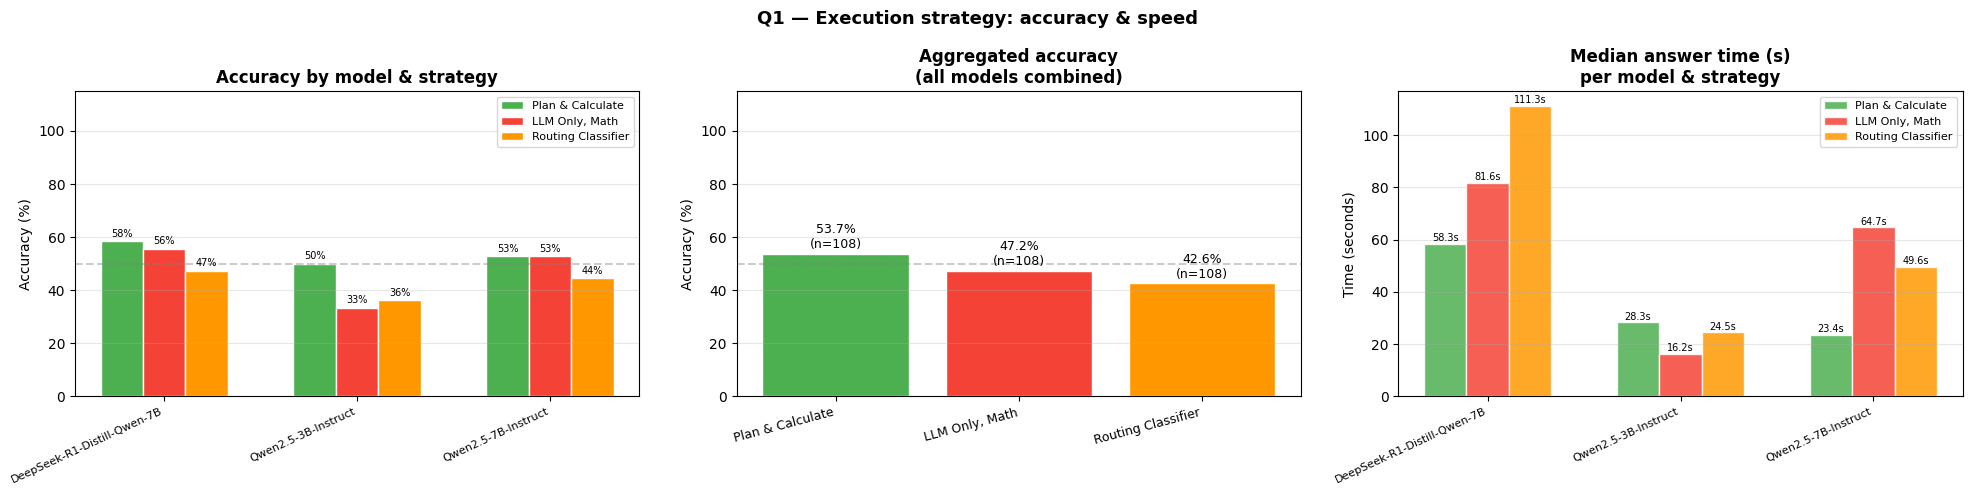


Summary — Q1:
  Variant                Model                                       Acc  Median(s)   Mean(s)  n
  --------------------------------------------------------------------------------------------
  LLM Only, Math         DeepSeek-R1-Distill-Qwen-7B               55.6%      81.6s     73.1s  36
  LLM Only, Math         Qwen2.5-3B-Instruct                       33.3%      16.2s     13.9s  36
  LLM Only, Math         Qwen2.5-7B-Instruct                       52.8%      64.7s     67.2s  36
  Plan & Calculate       DeepSeek-R1-Distill-Qwen-7B               58.3%      58.3s     55.6s  36
  Plan & Calculate       Qwen2.5-3B-Instruct                       50.0%      28.3s     32.1s  36
  Plan & Calculate       Qwen2.5-7B-Instruct                       52.8%      23.4s     28.7s  36
  Routing Classifier     DeepSeek-R1-Distill-Qwen-7B               47.2%     111.3s    152.3s  36
  Routing Classifier     Qwen2.5-3B-Instruct                       36.1%      24.5s     23.5s  36
  Routing

In [ ]:
plot_q1()

### Are "thinking" models better than standard ones?
> Using **Plan & Calculate** runs only, so strategy is kept fixed. Compares DeepSeek-R1 (thinking) against Qwen 2.5 (standard) in overall accuracy, performance by difficulty level, and median answer time.

---
## Q2 — Are "thinking" models better than standard ones?
> Using **Plan & Calculate** runs for a fair apples-to-apples comparison.

/tmp/ipykernel_1423/2084001697.py:173: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=8)
/tmp/ipykernel_1423/2084001697.py:207: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2c.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=8)


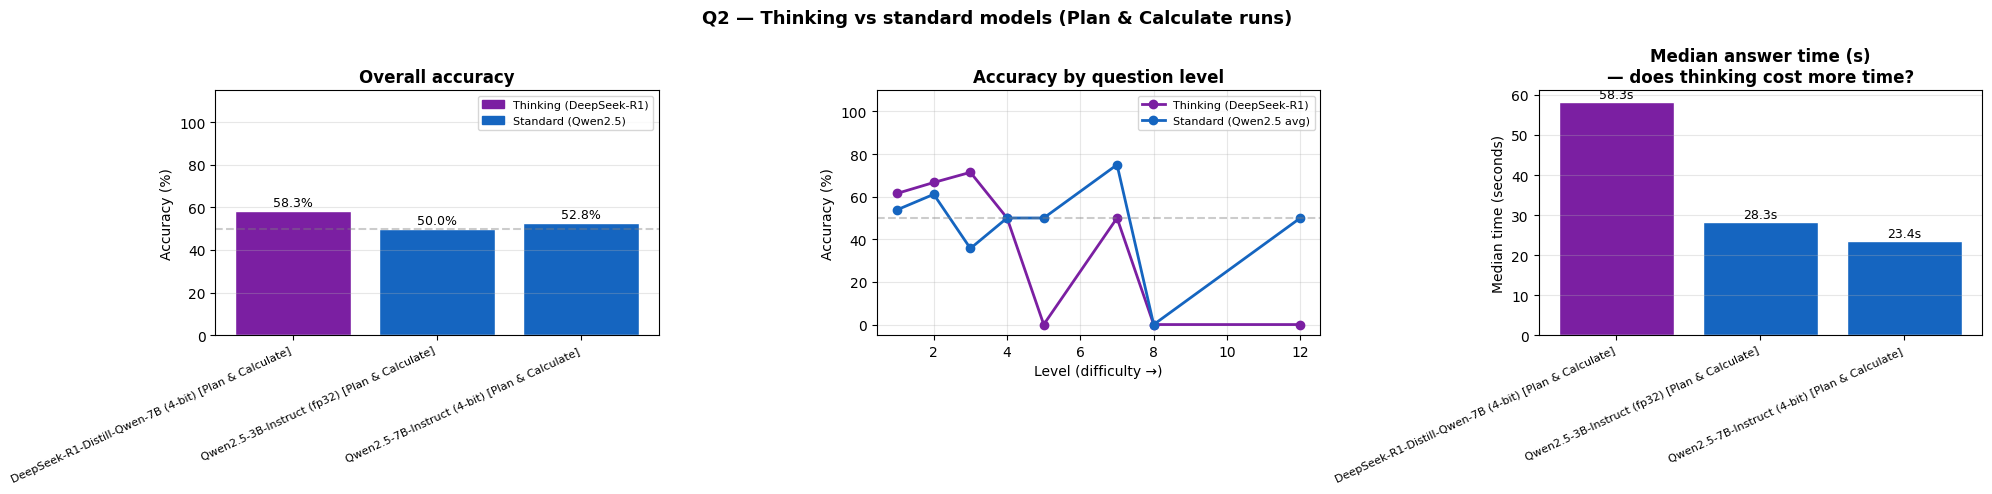


Summary — Q2 (Plan & Calculate):
  Model run                                               Type          Acc   Med(s)   Mean(s)  n
  ----------------------------------------------------------------------------------------------------
  DeepSeek-R1-Distill-Qwen-7B (4-bit) [Plan & Calculate]  thinking    58.3%    58.3s     55.6s  36
  Qwen2.5-3B-Instruct (fp32) [Plan & Calculate]           standard    50.0%    28.3s     32.1s  36
  Qwen2.5-7B-Instruct (4-bit) [Plan & Calculate]          standard    52.8%    23.4s     28.7s  36


In [ ]:
plot_q2()

### Which question types are hardest — and slowest?
> Accuracy and median answer time broken down by math topic (all runs combined). The heatmap shows **Plan & Calculate** accuracy per model × difficulty level.

---
## Q3 — Which question types are hardest — and slowest?
> Accuracy and median answer time broken down by math topic.

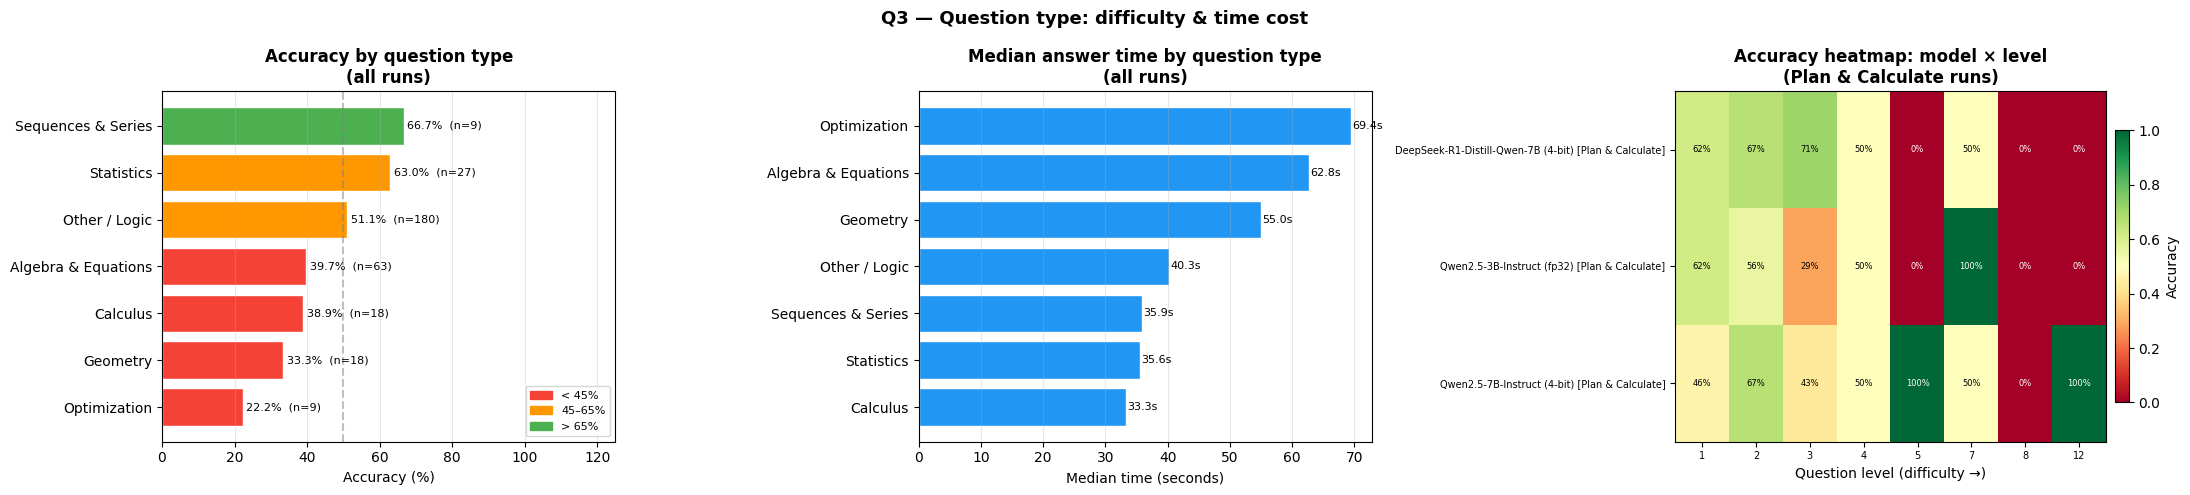


Hardest question types (accuracy < 55%, all runs):
  Optimization                    acc=22.2%  median_time=69.4s  (n=9)
  Geometry                        acc=33.3%  median_time=55.0s  (n=18)
  Calculus                        acc=38.9%  median_time=33.3s  (n=18)
  Algebra & Equations             acc=39.7%  median_time=62.8s  (n=63)
  Other / Logic                   acc=51.1%  median_time=40.3s  (n=180)

Slowest question types (median time):
  Optimization                    median=69.4s  mean=96.3s  acc=22.2%
  Algebra & Equations             median=62.8s  mean=65.4s  acc=39.7%
  Geometry                        median=55.0s  mean=61.8s  acc=33.3%


In [ ]:
plot_q3()

#AUDIO

## Speech to Text (STT)

Hugging face offers a large variety of Speech to Text LLM, we have choose a subset of those.
- "whisper_turbo",
- "whisper_medium",
- "whisper_base",
- "whisper_small",
- "wav2vec2"
We focused to evaluate the accuracy of trasnscription starting from the same audio.
Game speech has very noise audios, so it is normal that the transcription may change, so we decided to start from game text use a reliable text to speech LLM to get a reliable audio and use it with the different speech to text LLM.
At the end we ask to an LLM as a judge to evaluate the accuracy of transcription.

### Prompt judge LLM

In [ ]:
def build_asr_judge_prompt(candidates):

    system_message = (
        "You are an expert ASR evaluation system.\n"
        "Each system transcribed the SAME question and options.\n\n"

        "Your task:\n"
        "Evaluate how accurately each backend preserved meaning.\n"
        "Score EACH backend from 0 to 100.\n\n"

        "Rules:\n"
        "- 100 = perfect transcription\n"
        "- 0 = completely wrong\n"
        "- consider question + all options\n"
        "- penalize missing words, hallucinations, wrong entities\n\n"

        "Return ONLY valid JSON like:\n"
        "{\n"
        "  \"whisper_turbo\": 92,\n"
        "  \"whisper_base\": 70\n"
        "}\n"
    )

    candidate_text = ""

    for name, data in candidates.items():

        candidate_text += (
            f"\n=== {name} ===\n"
            f"ORIGINAL QUESTION:\n{data['original_question']}\n\n"
            f"ASR QUESTION:\n{data['question_asr']}\n\n"
            f"ORIGINAL OPTIONS:\n" +
            "\n".join(data["original_options"]) +
            "\n\nASR OPTIONS:\n" +
            "\n".join(data["options_asr"]) +
            "\n\n"
        )

    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": candidate_text},
    ]

## Text to Speech (TTS)

We have considered the following Text to Speech LLM:
- "gtts"
- "edge_tts"
- "kokoro"
- "espeak"
In order to evaluate them, we used them to traslate questions generated by game text into audios.
Then using the best STT LLM we get back the questions in text format. Using an LLM as a judge, we have evaluated the accuracy of transcription.
And also we calculated the word error rate:

  WER=(S+D+I)/N
  
Where:
- S = substitutions
- D = deletions
- I = insertions
- N = number of words in the reference

	​


### Prompt judge LLM

In [ ]:
def build_tts_judge_prompt(candidates):
    """
    Same structure as your ASR judge, but framing is TTS-centric:
    we're evaluating how well each TTS engine preserved the text
    when passed through a fixed ASR (Whisper Turbo).
    """
    system_message = (
        "You are evaluating Text-to-Speech (TTS) engines.\n"
        "Each engine synthesized the SAME original text into audio.\n"
        "The audio was then transcribed by a fixed ASR system (Whisper Turbo).\n\n"
        "Your task: score each TTS engine from 0 to 100 based on how accurately\n"
        "its output was transcribed back — this reflects TTS clarity and naturalness.\n\n"
        "Rules:\n"
        "- 100 = transcript perfectly matches the original\n"
        "- 0 = transcript is completely wrong or empty\n"
        "- Penalise: missing words, garbled entities, wrong names, punctuation errors\n"
        "- Consider BOTH the question AND all options\n\n"
        "Return ONLY valid JSON, example:\n"
        '{"gtts": 88, "edge_tts": 95}\n'
    )

    candidate_text = ""
    for name, data in candidates.items():
        candidate_text += (
            f"\n=== {name} ===\n"
            f"ORIGINAL QUESTION:\n{data['original_question']}\n\n"
            f"TRANSCRIBED QUESTION:\n{data['question_asr']}\n\n"
            f"ORIGINAL OPTIONS:\n" + "\n".join(data["original_options"]) +
            f"\n\nTRANSCRIBED OPTIONS:\n" + "\n".join(data["options_asr"]) + "\n\n"
        )

    return [
        {"role": "system", "content": system_message},
        {"role": "user",   "content": candidate_text},
    ]

### WER

In [ ]:
def word_error_rate(reference: str, hypothesis: str) -> float:
    ref = normalize_text(reference).split()
    hyp = normalize_text(hypothesis).split()
    if not ref:
        return 0.0
    if not hyp:
        return 1.0
    matcher = SequenceMatcher(None, ref, hyp)
    matches = sum(t.size for t in matcher.get_matching_blocks())
    substitutions = max(len(ref), len(hyp)) - matches
    return min(substitutions / len(ref), 1.0)

## Game Speech

### STT model

Now using the best STT LLM, we get the question as text.


In [ ]:
whisper_model = whisper.load_model("turbo")

In [ ]:
def transcribe_audio_bytes(audio_bytes: bytes) -> str:
    buffer = io.BytesIO(audio_bytes)
    audio_array, sample_rate = sf.read(buffer, dtype="float32")

    if len(audio_array.shape) > 1:
        audio_array = audio_array.mean(axis=1)  # stereo → mono
    if sample_rate != 16000:
        audio_array = resampy.resample(audio_array, sample_rate, 16000)

    result = whisper_model.transcribe(
        audio_array,
        language="en",
        fp16=True,
        no_speech_threshold=0.6,
        logprob_threshold=-1.0,
        compression_ratio_threshold=2.4,
        condition_on_previous_text=False,
    )
    return result["text"].strip()

In [ ]:

def transcribe_game_audio(question_audio: bytes, option_audios: list[bytes]) -> TranscribedQuestion:
    print("Transcribing question...")
    question_text = transcribe_audio_bytes(question_audio)
    print(f"  Q: {question_text}")

    options = []
    for i, audio in enumerate(option_audios):
        letter = chr(65 + i)  # A, B, C, D
        print(f"Transcribing option {letter}...")
        option_text = transcribe_audio_bytes(audio)
        print(f"  {letter}: {option_text}")
        options.append(TranscribedOption(id=i, text=option_text))

    return TranscribedQuestion(text=question_text, options=options)



But due to noise and filling word, the dialogue adds unuseful information, so we need to clean it.

### Question rewrite

#### Rewrite question's option

In [ ]:
def build_few_shot_prompt_rewrite_option(option_text):
    system_message = (
        "You are a text denoiser. Remove only ASR noise: filler words (uh, um, haha), "
        "stutters, and gibberish sounds. Return ONLY the cleaned text as a single short phrase. "
        "Do NOT answer. Do NOT explain. Do NOT add ANY content. Do NOT reference previous questions. "
        "If already clean, return it exactly as-is.\n\n"
        "Examples:\n"
        "INPUT: 'fermentation ah oh ahahsahssh eh ?' → OUTPUT: 'fermentation'\n"
        "INPUT: 'option C. option c Topshin D. ro uh mantic comedy' → OUTPUT: 'romantic comedy'\n"
        "INPUT: '! Film Noir!' → OUTPUT: 'Film Noir'\n"
        "INPUT: 'the Menoir' → OUTPUT: 'the Menoir'\n"
        "Now clean this text and return ONLY the result, nothing else:"
    )

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": option_text},
    ]
    return messages

#### Rewrite question's text

In [ ]:
def build_few_shot_prompt_rewrite_question_text(question_text):

    system_message = (
        "You are a text denoiser. Remove only ASR noise: filler words "
        "(uh, um, haha), stutters, repeated words, and gibberish sounds. "
        "Preserve the original meaning and question structure exactly. "
        "Return ONLY the cleaned question text. "
        "Do NOT answer. Do NOT explain. Do NOT add ANY content. "
        "Remove answer options such as A), B), C), D) and remove explanatory notes. "
        "If already clean, return it exactly as-is except for option/note removal.\n\n"

        "Examples:\n"

        "INPUT: 'Uh, how does, haha, Pink Floyd use, um, absence as a theme in Wish You Were Here?'\n"
        "OUTPUT: 'How does Pink Floyd use absence as a theme in Wish You Were Here?'\n\n"

        "INPUT: 'What, uh, term describes a song specially created for an anime series?'\n"
        "OUTPUT: 'What term describes a song specially created for an anime series?'\n\n"

        "Now clean this text and return ONLY the result, nothing else:"
    )

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": question_text},
    ]

    return messages

## 🔎 AUDIO Analysis

### How do audio transcription and generation affect system performance?



System performance is heavily affected by noise in the audio input.
In particular, filler words, exclamations, and onomatopoeic sounds introduce unnecessary information that reduces transcription quality.

Noise also negatively impacts the speech-to-text conversion process. For example, during a biology-related question, the correct option *“mushroom”* was transcribed as *“much room”* because of background noise and volume variations.

Using audio additionally introduces two extra processing steps before the Large Language Model (LLM) can answer the question:

1. **Speech-to-Text Transcription**
   The audio must first be converted into text using a Speech-to-Text (STT) model. This model must fit within the available GPU and RAM limits.

2. **Noise Cleaning and Rewriting**
   The raw transcription often contains noise, filler words, or corrupted sentences. Therefore, another LLM step is required to rewrite and clean the question and answer options into a readable format.

Only after these steps can the final LLM infer the correct answer.

It is also important to note that Google Colab Free provides limited GPU memory. Both the STT model and the answering LLM must fit within these hardware constraints, which limits the reasoning power and model size that can be used.


### Can the system still answer within the 30-Second timeout when using audio?

Yes, (proved by graph below) the system is able to answer within the 30-second limit.

Performance breakdown:

* **Whisper Turbo transcription:** less than 5 seconds
* **Final LLM answer generation:** less than 3 seconds
* **Question rewriting and noise cleaning:** main bottleneck

The rewriting phase strongly depends on the prompt examples provided to the LLM.
Examples are necessary to teach the model which kinds of noise should be filtered out.

However, longer prompts may increase hallucinations. In some cases, even a single example can significantly alter the model’s behavior.

For instance, the rewriting model may incorrectly add information even when explicitly instructed not to do so.

Example of a successful rewrite:

Original transcription:

> AH ahahha! What is the fundamental principle that allowed ancient Egypt to achieve its dominance and success for over 3,000 years?
>
> 0: successful irrigation and agricultural systems.
>
> 1: the establishment of a powerful pharaoh.
>
> 2: the strategic military conquests of neighboring lands!
>
> 3: Huh. Oh. Oh. Welp. Sack. Ted. It is up in on himself. Duh. Endo people he dope cried. Who that uh. Huh.

Rewritten version:

> What is the fundamental principle that allowed ancient Egypt to achieve its dominance and success for over 3,000 years?
>
> 0: successful irrigation and agricultural systems.
>
> 1: the establishment of a powerful pharaoh.
>
> 2: strategic military conquests of neighboring lands.
>
> 3: Ted. Endo people cried.

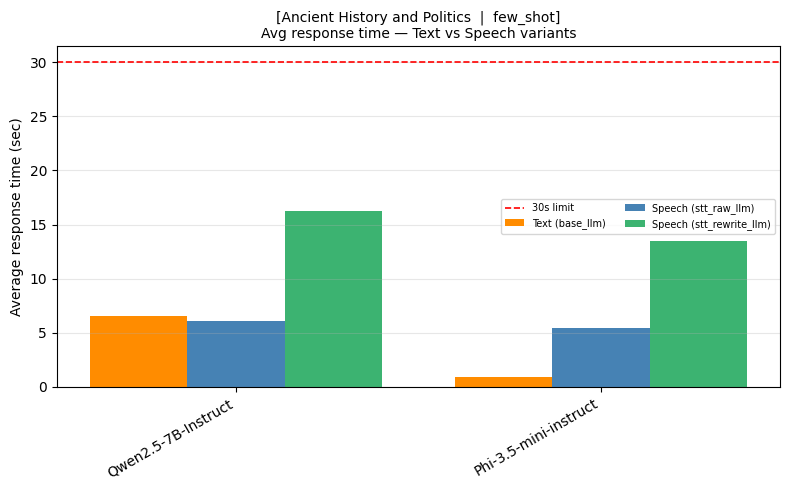

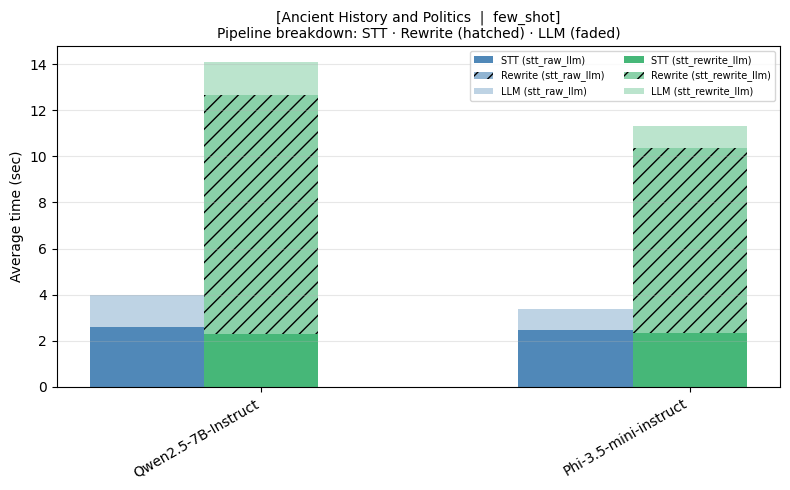

### What is the most reliable transcription algorithm?

#### 1. Text-to-Speech (TTS)

We evaluated several Text-to-Speech systems:

* gTTS
* edge_tts
* Kokoro
* eSpeak

The evaluation process started from the original game questions in text format.
Each question was converted into audio using the different TTS systems. Then, the generated audio was transcribed back into text using the best-performing Speech-to-Text model.

Finally, the reconstructed text was compared with the original question using an LLM-as-a-Judge approach to estimate transcription accuracy.

Average accuracy across multiple questions:

* gTTS: 80.2%
* edge_tts: 89.0%
* Kokoro: 82.6%
* eSpeak: 70.0%

Therefore, **edge_tts** was the most reliable Text-to-Speech system.



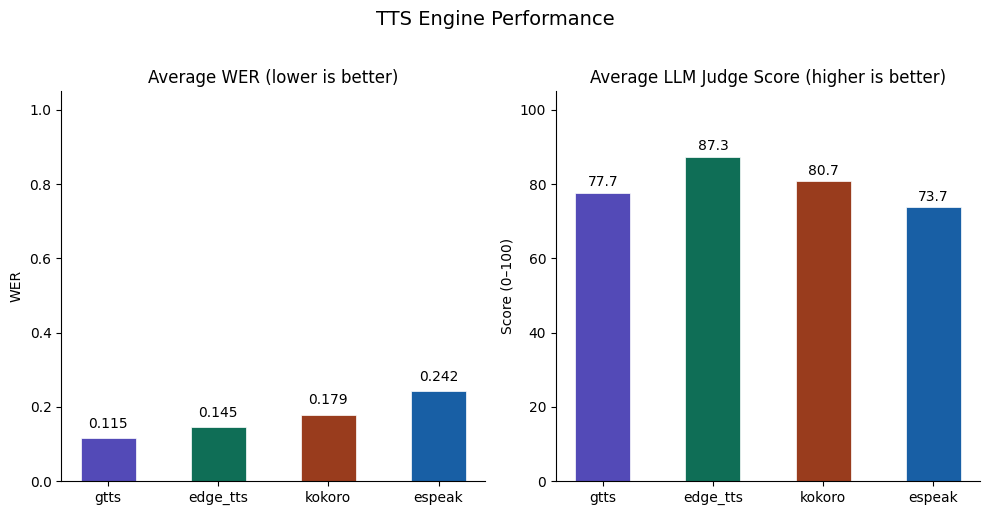

#### 2. Speech-to-Text (STT)



We evaluated the following Speech-to-Text models:

* whisper_turbo
* whisper_medium
* whisper_base
* whisper_small
* wav2vec2

The evaluation followed the same pipeline described above.

Average transcription accuracy:

* whisper_turbo: 90.6%
* whisper_medium: 88.2%
* whisper_base: 77.8%
* whisper_small: 86.2%
* wav2vec2: 84.0%

Therefore, **whisper_turbo** was the most reliable Speech-to-Text model.

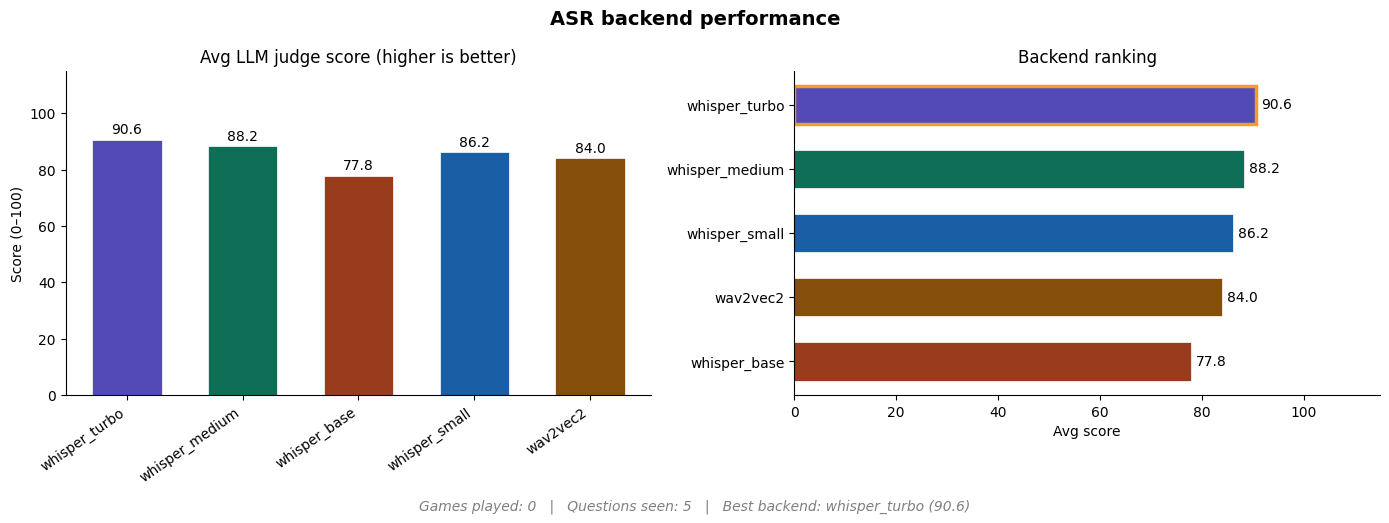


### Can the correct answer be rejected because of transcription problems?



Yes, this can happen.

The main issue occurs when the server sends noisy audio options. In some cases, the transcription process completely changes the meaning of a word.

For example:

* *“mushroom”* → *“much room”*

If the correct answer is corrupted in this way, neither an LLM nor a human listener may be able to identify the original intended word.

### Does rewriting the questions after audio transcription improve performance?

Due to time constraints, we were only able to run 15 games for each configuration.
To obtain statistically reliable results, a significantly larger number of samples would be required.

Even with only 15 samples, we observed a small performance improvement when using the rewriting step after audio transcription.

The rewriting phase helps by removing:

* filler words,
* transcription noise,
* corrupted sentences,
* and irrelevant audio artifacts.

This produces cleaner and more understandable questions for the final LLM.

However, the current evaluation is not sufficient to draw strong conclusions because the dataset is not homogeneous.
Some questions contain much more audio noise than others, which means that certain games are naturally more difficult to transcribe correctly.

As a result, the measured performance can vary depending on the distribution of noisy questions within the sample.


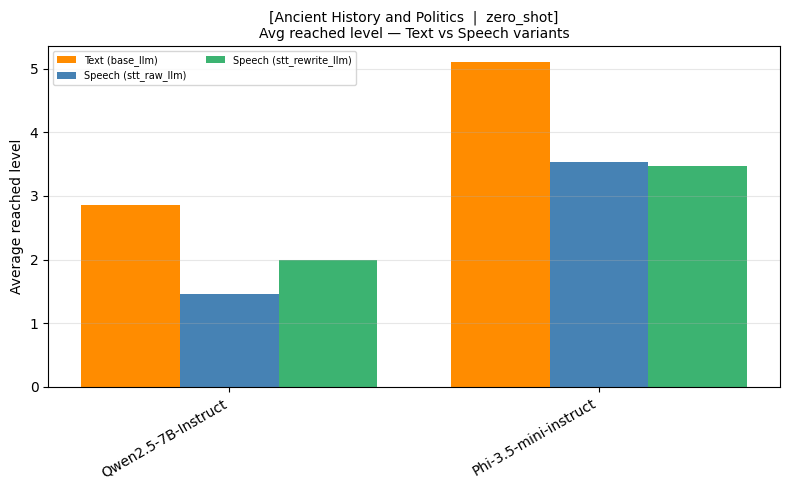

To properly evaluate the real impact of the rewriting step, the experiment should be repeated with at least:

* 50 samples for a preliminary evaluation,
* or ideally 100 samples for more reliable statistical results.

A larger dataset would reduce variance and provide a more accurate estimate of the actual performance improvement introduced by the rewriting process.

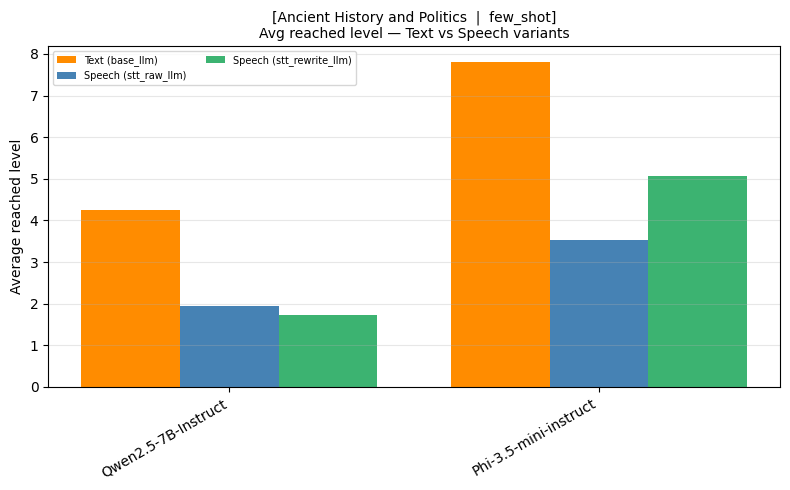

Even with a limited number of few-shot samples, the rewriting technique already shows measurable improvements in performance.

The rewriting step helps clean transcription noise, remove filler words, and reconstruct corrupted sentences, producing clearer input for the final LLM.

However, the current evaluation is still based on a relatively small number of experiments. More samples are required to accurately measure the real impact of the rewriting technique and obtain statistically reliable results.


### Can multiple Speech-to-Text models be used together before answering?

No, this is not currently feasible due to GPU memory limitations.

The answering LLM already occupies a large portion of VRAM.
A reliable Speech-to-Text model typically requires around:

* 10 GB of VRAM
* 2 GB of system RAM

Because of these hardware constraints, running multiple transcription models simultaneously is not practical. The main bottleneck is GPU memory availability.



### What performance level is expected when playing the Game with speech?

The transcription pipeline is generally reliable and is able to recover most of the important words from speech input.

Additionally, the rewriting phase removes:

* filler words,
* exclamations,
* onomatopoeic sounds,
* and other irrelevant noise.

As a result, the system usually reconstructs an accurate version of the original question and answer options.

Although the overall pipeline may occasionally lose precision due to cascading transcription and rewriting errors, we estimate the transcription reliability to be approximately **80%**.

The main limitation then becomes the answering capability of the final LLM.

In this project, we used **Phi-3.5-mini-instruct** by Microsoft and Qwen 3B
Those models perform well in:

* Entertainment
* Ancient History and Politics
* Science and Nature
* Philosophy and Psychology

However, they perform worse in:

* Mathematics
* News-related questions

Therefore, we expect speech-based gameplay performance to be similar to text-based gameplay, although with slightly lower overall accuracy.

In [ ]:
def get_llm_answer_math_no_tool(question, tokenizer, model):
    print("Using answering 'get_llm_answer_math_no_tool'\n") # debug
    valid_ids = [opt.id for opt in question.options]
    qtype = classify_question(question)
    print(f"  [math] type={qtype}")

    system_msg, user_msg = build_math_prompt_few_shot(question.text, question.options, question_type=qtype)
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user",   "content": user_msg},
    ]

    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # Suppress R1 <think> for all types. (i used it mostly on deepseek-ai/DeepSeek-R1-Distill-Qwen-7B)
    # The pre-fill "<think>\n</think>\n" tells R1 the reasoning block is already
    # complete, so it skips to the answer. This only works reliably when the
    # closing tag is a single token in the vocabulary — verify with:
    #   tokenizer.encode("</think>", add_special_tokens=False)
    # If it encodes to more than one token, the suppression won't hold and R1
    # will re-open the block. In that case the model generates ~300-500 extra
    # tokens and will conitnue for a long time. The few-shot examples already supply the
    # reasoning pattern, so suppressing <think> is safe for all types here.
    think_suffix = get_think_suffix(tokenizer)
    prompt += think_suffix

    max_new_tokens = 512

    output = generate_answer(prompt, tokenizer, model, max_new_tokens=max_new_tokens)
    print(f"  [math] raw output: {repr(output)}")

    # Extraction cascade
    # explicit "Answer: N" pattern
    ans = find_answer_in_output(output, valid_ids)
    if ans is not None:
        return ans

    # last valid number in output, sometimes llm models forget the formatting (ex. the answer is 2)
    for n in reversed(re.findall(r'\b([0-9]+)\b', output)):
        ans = int(n)
        if ans in valid_ids:
            print(f"  Parsed answer (last valid number): {ans}")
            return ans

    # random option fallback
    mid = random.choice(valid_ids)
    print(f"  [fallback] random option: {mid}")
    return mid


#Play audio game

In [ ]:
# ============================================================
# PLAY SPEECH GAME
# ============================================================

# AUDIO_ENGINE:
#   "llm" -> audio + Whisper + standard LLM
#   "rag" -> audio + Whisper + selected RAG configuration
AUDIO_ENGINE = "rag"

# RAG_CONFIGURATION is used only if AUDIO_ENGINE = "rag".
# Options include: "crag", "fusion_rag", "fusion_cross_encoder_rag",
# "self_rag", "rse_rag", "hyde_rag", "query_transformation_rag",
# "reliable_rag", "rag_baseline_question_only", "rag_question_options".
RAG_CONFIGURATION = "crag"

# Optional transcription cleaning with LLM:
# Faster: False / False
# Better but slower: True / False
# Slowest: True / True
SPEECH_CONFIG["rewrite_question"] = True
SPEECH_CONFIG["rewrite_options"] = True

game = client.game.start(
    competition_id=comp_id,
    mode="speech",
)

play_audio_game(
    game=game,
    tokenizer=llm_tokenizer,
    model=llm_model,
    engine=AUDIO_ENGINE,
    rag_configuration=RAG_CONFIGURATION,
)


SPEECH LEVEL 1
Answer engine: rag
Prompt strategy: zero_shot
Fetching question audio...
Fetching option A audio...
Fetching option B audio...
Fetching option C audio...
Fetching option D audio...
Time remaining after audio fetch: 29.7s
Audio fetch time: 1.71s

Transcribing question...
Q: According to the article published on 2026.05.13, what percentage of people in the UK prefer consulting AI chatbots for health advice instead of seeing their GP?
Transcribing option A...
A / id=0: Large Danny TAI
Transcribing option B...
B / id=1: Option B. 20%.
Transcribing option C...
C / id=2: Option C, 15%.
Transcribing option D...
D / id=3: Top 10 D 25%
Total STT time: 20.39s

--- Raw transcribed question ---

QUESTION:
According to the article published on 2026.05.13, what percentage of people in the UK prefer consulting AI chatbots for health advice instead of seeing their GP?

OPTIONS:
[0] Large Danny TAI
[1] 20%.
[2] 15%.
[3] Top 10 D 25%


Rewriting question text...
Rewriting options...

---

1